# Pipeline MeNU+ - Détection d'anomalies dans les UAVs autonomes

## Jean Frideland Delphin - Maîtrise en informatique, UQAR
### Sous la direction de Mehdi Adda

---

## Résumé

Ce pipeline implémente et valide expérimentalement **MeNU+**, une approche de détection d'anomalies pour UAVs autonomes combinant :

- Un **Autoencodeur (AE)** entraîné exclusivement sur les vols normaux, produisant un signal d'anomalie compact (représentation latente + scores MSE/MAE)
- **XGBoost** avec régularisation et SMOTE pour la classification robuste sur features enrichies (brutes + signal AE)
- Une **agrégation temporelle** par fenêtres glissantes réduisant les faux positifs isolés et produisant un TTD (Time-To-Detection) mesurable

### Résultats expérimentaux (validation GroupKFold 5-folds, 9 857 frames)

| Approche | G-Mean | AUC-ROC | TTD (fenêtres) | Rang |
|---|---|---|---|---|
| **MeNU+ (AE+XGB+Agg)** | **0.8529** | **0.9057** | **-0.4242** | **1** |
| XGBoost+Agg (sans AE) | 0.8502 | 0.9206 | -2.2500 | 2 |
| RF (features brutes) | 0.8441 | 0.9271 | - | 3 |
| LightGBM (features brutes) | 0.8367 | 0.9355 | - | 4 |

Un TTD négatif indique une détection anticipée : le modèle capte des signaux précurseurs avant l'instant labellisé comme début de panne (cf. Section 8.3).

### Hiérarchie d'ablation validée
```
RANG 1 : MeNU+ (AE + XGBoost + Agrégation)     G-Mean = 0.8529  - contribution principale
RANG 2 : XGBoost + Agrégation (sans AE)         G-Mean = 0.8502  - prouve l'apport de l'AE
RANG 5 : XGBoost (features brutes)              G-Mean = 0.8325  - prouve l'apport de l'agrégation
RANG 4-N : Baselines (LightGBM, XGBoost, Ensemble)   G-Mean <= 0.8367
```

### Protocole expérimental
- **Dataset** : ALFA (A Dataset for UAV Fault and Anomaly Detection) - 9 857 frames (7 720 normales, 2 137 pannes)
- **Validation** : GroupKFold 5-folds (groupé par vol - pas de contamination inter-vol)
- **Déséquilibre** : ratio 3.6:1 - compensé par SMOTE dans chaque fold
- **Métriques** : G-Mean (principale), AUC-ROC, AUC-PR, TTD
- **Reproductibilité** : SEED=42, paramètres centralisés, `results_menu_plus.csv`
- **Optuna** : 100 trials, espace de recherche `max_depth` [5,10]


## Contexte

Les drones (UAV) autonomes opérant en environnement critique peuvent subir des défaillances mécaniques susceptibles de compromettre leur mission. La détection précoce de ces anomalies est essentielle pour améliorer la sécurité opérationnelle, notamment lors de missions de sauvetage post-catastrophe (séismes, inondations).

Le dataset ALFA (A Dataset for UAV Fault and Anomaly Detection) est utilisé comme base expérimentale.
**Source :** [https://kilthub.cmu.edu/articles/dataset/ALFA_A_Dataset_for_UAV_Fault_and_Anomaly_Detection/12707963](https://kilthub.cmu.edu/articles/dataset/ALFA_A_Dataset_for_UAV_Fault_and_Anomaly_Detection/12707963)

---

## Problématique

Les approches classiques de détection d'anomalies présentent deux limites majeures dans ce contexte :

1. **Forte sensibilité au déséquilibre des classes** - le dataset ALFA présente un ratio anomalie/normal élevé, ce qui biaise les classifieurs standards vers la classe majoritaire.
2. **Taux élevé de faux positifs** - une détection frame-par-frame sans lissage temporel génère des alertes erratiques inutilisables en conditions opérationnelles.

---

## Approche proposée : MeNU+

MeNU+ est un pipeline hybride combinant :
- Un **Autoencodeur** pour la réduction de dimension et l'extraction de features latentes
- Un **classifieur XGBoost** optimisé par Optuna
- Une **agrégation temporelle par fenêtres** pour réduire les faux positifs

---

## Approches comparées

| # | Approche | Rôle |
|---|---|---|
| 1 | Majority Baseline | Référence naïve |
| 2 | Random Forest (features brutes) | Baseline ensembliste |
| 3 | Logistic Regression | Baseline linéaire |
| 4 | XGBoost (features brutes) | Baseline non-linéaire |
| 5 | AE + XGBoost sans agrégation | Ablation - apport de l'espace latent |
| 6 | XGBoost + AE sans agrégation | Ablation - features mixtes |
| 7 | LightGBM (features brutes) | Comparaison gradient boosting |
| 8 | Ensemble XGB+LGBM+LR | Comparaison voting |
| 9 | XGB + Agrégation temporelle | Ablation - apport de l'agrégation |
| 10 | XGB + AE + Agrégation temporelle | Ablation - apport de l'agrégation et de l'AE |

---

## Protocole expérimental

- **Validation croisée groupée** : `StratifiedGroupKFold(n_splits=5)` - aucun vol en commun entre train et test
- **Hold-out indépendant stratifié** : 20% des vols normaux ET 20% des vols avec panne réservés
- **SMOTE** appliqué uniquement sur TRAIN dans chaque fold
- **Sélection de variables** anti data leakage (`SelectFromModel` avec RF)
- **Optimisation hyperparamétrique** : Optuna (TPE Sampler, 100 trials)
- **Agrégation temporelle** : fenêtres de taille optimisée par Optuna
- **Seuil adaptatif** : maximisation du G-Mean ou du Recall selon le contexte

Toutes les transformations (scaling, sélection, SMOTE, AE) sont réalisées exclusivement sur les données d'entraînement afin d'éviter toute fuite d'information.

## 1. Configuration de l'environnement

Cette section configure l'environnement d'exécution et importe toutes les bibliothèques nécessaires au pipeline MeNU+.

Les variables d'environnement limitent les messages TensorFlow et contrôlent le parallélisme CPU.
Les seeds sont fixés (`RANDOM_STATE=42`) pour garantir la reproductibilité complète des résultats.

## 2. Paramètres globaux

Paramètres centralisés du pipeline. Modifier ces valeurs pour ajuster le comportement global.

| Paramètre | Valeur | Description |
|---|---|---|
| `N_SPLITS` | 5 | Nombre de folds pour la validation croisée groupée |
| `RANDOM_STATE` | 42 | Graine aléatoire pour la reproductibilité |
| `N_TRIALS_MENU` | 100 | Nombre de trials Optuna - run finale |
| `TEMPORAL_LABELING` | True | Frames pré-panne labellées 0, post-panne labellées 1 |

In [1]:
import sys
print(sys.executable)
print(sys.version)

C:\Users\jfdel\gpu_env\Scripts\python.exe
3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


In [2]:
%pip install --upgrade pip

%pip install numpy pandas matplotlib seaborn scikit-learn imbalanced-learn optuna tensorflow
%pip install matplotlib seaborn
%pip install imbalanced-learn
%pip install xgboost
%pip install lightgbm
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
# ============================================================
# SECTION 1 - CONFIGURATION ENVIRONNEMENT
# ============================================================
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"]  = "2"
os.environ["TF_DETERMINISTIC_OPS"]   = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"
os.environ["OMP_NUM_THREADS"]      = "12"
os.environ["OPENBLAS_NUM_THREADS"] = "12"
os.environ["MKL_NUM_THREADS"]      = "12"
os.environ["NUMEXPR_NUM_THREADS"]  = "12"

# ============================================================
# SECTION 2 - TOUS LES IMPORTS (centralisés)
# ============================================================

# Bibliothèques standard
import gc
import json
import joblib
import random
import platform
import zipfile
import sys
import warnings

warnings.filterwarnings("ignore", message="X does not have valid feature names")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# Calcul numérique & données
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn : validation croisée
from sklearn.model_selection import (
    GroupKFold,
    StratifiedGroupKFold,
    GroupShuffleSplit,
    train_test_split,
)

# Scikit-learn : prétraitement & sélection
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.calibration import CalibratedClassifierCV

# Scikit-learn : métriques
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc,
    balanced_accuracy_score,
)
from collections import Counter

# Scikit-learn : modèles
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

# XGBoost
from xgboost import XGBClassifier

# LightGBM (optionnel)
try:
    import lightgbm as lgb
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print("[INFO] LightGBM non disponible - pip install lightgbm")

# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.metrics import geometric_mean_score

# TensorFlow / Keras
import tensorflow as tf
tf.get_logger().setLevel("ERROR")
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ============================================================
# SECTION 3 - CACHE AUTOENCODEUR
# ============================================================
AE_LATENT_CACHE = {}

print(f"Environnement prêt | Python {sys.version.split()[0]} | TF {tf.__version__}")
print(f"LightGBM disponible : {LGBM_AVAILABLE}")

# =========================
# CLEANING & PREPARATION
# =========================
# Implémentation du pipeline de preprocessing de Yoo et al. (2025),
# Section 3.2, étapes 4, 5 et 6 :
#   Étape 4 : forward-fill puis backward-fill pour les valeurs manquantes
#   Étape 5 : suppression des colonnes non informatives (timestamps, constantes)
#   Étape 6 : calcul des variations (contexte temporel utile pour la détection)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)


# ============================================================
# MeNU+ MULTI-CLASSE - One-vs-Rest (OvR) par type de panne
# ============================================================
# Un classifieur AE+XGBoost binaire par type de panne.
# Chaque classifieur répond à "Est-ce une panne de type X ?"
# en comparant ce type aux vols normaux uniquement.
#
# Avantages :
# - Rudder/Elevator (peu de vols) ne competent pas contre Engine/Aileron
# - Chaque classifieur est calibré indépendamment
# - Agrégation = moyenne des scores → plus robuste que vote majoritaire
#
# Mapping : normal=0 | engine=1 | aileron=2 | rudder=3 | elevator=4
# ============================================================

# (imports déjà présents ci-dessus)


from imblearn.over_sampling import SMOTE as SM
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.model_selection import GroupKFold as GKF
# ============================================================
# SECTION 3 - DOSSIER DE SAUVEGARDE DES FIGURES
# ============================================================
FIGURES_DIR = os.path.join(os.path.dirname(os.path.abspath(__file__))
                           if '__file__' in dir() else os.getcwd(),
                           "figures_article")
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"Figures saved to: {FIGURES_DIR}")


Environnement prêt | Python 3.10.11 | TF 2.20.0
LightGBM disponible : True
Figures saved to: C:\Users\jfdel\JupyterNotebook\MeNU+pivot\Apres_retour_de_Monsieur_Adda\Article 2 - version finale 2\figures_article


C:\Users\jfdel\gpu_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import gc, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    recall_score, precision_score, f1_score,
)
from imblearn.over_sampling import SMOTE, ADASYN
from xgboost import XGBClassifier

try:
    from lightgbm import LGBMClassifier
    LGBM_OK = True
except ImportError:
    LGBM_OK = False

In [5]:
# =========================
# REPRODUCTIBILITÉ
# =========================
SEED         = 42
RANDOM_STATE = 42

# Seeds globales
os.environ['PYTHONHASHSEED']          = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"]    = "1"
os.environ["TF_CUDNN_DETERMINISTIC"]  = "1"
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Ops deterministes (GPU inclus)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print(f"Seed fixee a {SEED} | Reproductibilite maximale activee")

Seed fixee a 42 | Reproductibilite maximale activee


## 3. Chargement du dataset ALFA

Chargement et labellisation automatique des données :
- **Label 0** : vol normal (dossiers `no_failure`)
- **Label 1** : vol avec panne (engine, rudder, aileron, elevator)

Avec `TEMPORAL_LABELING=True`, les frames **avant** l'apparition de la panne sont labellées 0 (comportement normal), et seulement les frames **après** la panne sont labellées 1. Cette approche est plus fidèle à la réalité physique du phénomène.

## Description du dataset ALFA

Le dataset ALFA contient des enregistrements télémétriques issus de vols UAV simulant des scénarios normaux et des défaillances mécaniques.

**Caractéristiques principales :**
- **47 vols au total** : ~8 vols normaux + ~39 vols avec panne (engine, rudder, aileron, elevator)
- Chaque vol est identifié par un `flight_id` unique permettant la séparation expérimentale par groupe
- **97 944 frames** après sous-échantillonnage (1 frame sur 5)
- **88 variables** issues de 7 types de CSV (diagnostics, IMU, navigation)

**Variable cible `label` (binaire) :**
- `0` : comportement normal (avec `TEMPORAL_LABELING=True`, inclut les frames pré-panne)
- `1` : défaillance mécanique active

**Remarque sur le déséquilibre :**
Avec `TEMPORAL_LABELING=True`, la distribution est approximativement 78% normaux / 22% anomalies, ce qui est nettement plus équilibré que sans labellisation temporelle (15% / 85% inversé).

In [6]:
#from google.colab import drive
#drive.mount('/content/drive')

In [7]:
# =========================
# PARAMÈTRES GLOBAUX
# =========================

# CHEMIN VERS LE DATASET ALFA
# Adapter ce chemin à votre environnement local, ou définir la variable
# d'environnement ALFA_DATA_PATH avant de lancer le notebook.
#DATA_PATH_ALFA = os.environ.get(
#    "ALFA_DATA_PATH",
#    "./data/ALFADataset/12707963/processed/processed"
#)

# CHEMIN VERS LE DATASET ALFA
DATA_PATH_ALFA = r"C:\Users\jfdel\OneDrive\Desktop\Datasets\ALFADataset\12707963\processed\processed"

if not os.path.exists(DATA_PATH_ALFA):
    raise FileNotFoundError(
        f"Dataset ALFA non trouvé : {DATA_PATH_ALFA}\n"
        "Téléchargez le dataset ALFA (voir lien dans la cellule 'Contexte' "
        "ci-dessus) et placez-le à ce chemin, ou définissez la variable "
        "d'environnement ALFA_DATA_PATH."
    )

_n_folders = len([f for f in os.listdir(DATA_PATH_ALFA)
                  if os.path.isdir(os.path.join(DATA_PATH_ALFA, f))])
print(f"OS            : {platform.system()}")
print(f"Dataset ALFA  : {DATA_PATH_ALFA}")
print(f"Dossiers de vol trouvés : {_n_folders}")

# PARAMÈTRES DE VALIDATION CROISÉE
N_SPLITS      = 5
RANDOM_STATE  = 42
N_TRIALS_MENU = 100   # Nombre de trials Optuna (100 = configuration finale)
                    # 10 trials ≈ 20 min | 50 trials ≈ 2h | 100 trials ≈ 4h (indicatif)

# LABELLING TEMPOREL
# Les frames AVANT la panne = label 0, APRÈS = label 1
# Pour une améliortion de la qualité des données d'entraînement de l'AE
TEMPORAL_LABELING = True


# ---------------------------------------------------------------
# TIMESTAMP POOLING - Yoo et al. (2025), MeNU, Section 3.2
# ---------------------------------------------------------------
# Problème : les capteurs ALFA enregistrent à des fréquences
# variables (4 Hz à 50 Hz selon le topic, cf. Keipour et al. 2020
# Table 2). Cela produit ~97,944 frames bruyantes et désynchronisées.
#
# Solution : regrouper dans des fenêtres de 0.5s (= 2 Hz final)
#   - Features numériques → MOYENNE de la fenêtre
#   - Label binaire       → MAJORITÉ (≥ 50% de 1 → label = 1)
#   - label_mc            → MODE (valeur la plus fréquente)
#
# Résultat : ~97,944 frames → ~5,000-6,000 points représentatifs
# AUC obtenu par Yoo et al. avec cette approche : 0.9856
#
# Pour désactiver (mode frame-par-frame) : USE_TIMESTAMP_POOLING = False
# ---------------------------------------------------------------
USE_TIMESTAMP_POOLING = True
POOL_WINDOW_SEC       = 0.5


OS            : Windows
Dataset ALFA  : C:\Users\jfdel\OneDrive\Desktop\Datasets\ALFADataset\12707963\processed\processed
Dossiers de vol trouvés : 47


## 3.1 Chargement du dataset ALFA (`read_alfa_dataset`)

### Stratégie de chargement

Le dataset ALFA contient des enregistrements multi-fréquences issus de plusieurs types de capteurs (diagnostics à 5 Hz, IMU à 10 Hz, navigation à 20-25 Hz). Le chargement suit trois étapes :

1. **Sélection des CSV ciblés** : 31 types de fichiers CSV sont chargés, couvrant l'ensemble des topics identifiés dans Keipour et al. (2020) https://doi.org/10.1177/0278364920966642 (Table 2) :
   - Diagnostics système (5 Hz) : `diagnostics.csv`
   - IMU (10 Hz) : `imu-data`, `imu-atm_pressure`, `imu-temperature`, `imu-mag`, `imu-data_raw`
   - Nav info (20-25 Hz) : `nav_info-errors`, `nav_info-pitch`, `nav_info-roll`, `nav_info-yaw`, `nav_info-velocity`, `nav_info-airspeed`
   - Position locale (4 Hz) : `local_position-odom`, `local_position-pose`, `local_position-velocity`
   - Position globale (4-5 Hz) : `global_position-global`, `global_position-rel_alt`, `global_position-local`, `global_position-compass_hdg`, `global_position-raw`
   - RC, vent, état, batterie et autres : `rc-in`, `rc-out`, `wind_estimation`, `vfr_hud`, `setpoint_raw`, `mavctrl-path_dev`, `mavctrl-rpy`, `battery`, `state`

2. **Fusion temporelle** : les 31 CSV d'un même vol sont fusionnés par `merge_asof` sur la colonne `%time` (tolérance 100 ms), produisant une table unifiée par vol.

3. **Timestamp Pooling** : fenêtres de 0.5 s avec agrégation médiane pour uniformiser la fréquence. Résultat : **9 857 points représentatifs** issus de ~97 944 frames brutes, avec **270 features brutes** avant sélection (161 après `VarianceThreshold` + `SelectFromModel RF`).

### Labellisation temporelle (`TEMPORAL_LABELING`)

Avec `TEMPORAL_LABELING=True`, les frames **avant** la panne (phase de vol normale) sont labellisées `0` même dans les vols en panne. Cela evite que le modele apprenne la position temporelle dans le vol plutot que le comportement anormal.

### Identification des vols (`flight_id`)

Chaque vol recoit un identifiant unique (`flight_id`) base sur le nom du dossier. Cet identifiant est utilise par `GroupKFold` pour s'assurer qu'un meme vol ne se retrouve jamais a la fois dans le train et le test (pas de contamination inter-vol).

### Composition du dataset charge

| Categorie | Vols | Frames (apres pooling) |
|---|---|---|
| Vols normaux (no_failure) | 10 | 7 720 (78.3%) |
| Vols avec panne (engine, aileron, rudder, elevator) | 37 | 2 137 (21.7%) |
| **Total** | **47** | **9 857** |

Le desequilibre classe (ratio ~3.6:1) est gere par SMOTE dans chaque fold d'entrainement.


In [8]:
# =========================
# DATA LOADING ALFA - MEMORY SAFE, CSV du dataset CIBLÉS
# =========================
# Topics sélectionnés inspiré de Keipour et al. (2020), Table 2 :
# diagnostics (5 Hz), imu (10 Hz), nav_info (20-25 Hz)
CSV_SUFFIXES_ALFA = [

    # ==================================================================
    # PRIORITÉ 1 - Features physiques directes (Table 5 du dataset ALFA)
    # Ces 19 sources couvrent toutes les features mentionnées dans la
    # littérature ALFA et correspondent exactement aux features importantes
    # identifiées par le RandomForest (field.status, temperature, altitude,
    # fluid_pressure, pose, channels, alt_error, twist, magnetic_field).
    # ==================================================================

    # Diagnostics système (5 Hz)
    # RC input/output, température moteur, pression fluide - features Table 5
    # → field.status*, field.channels*, field.temperature, field.fluid_pressure
    "-diagnostics.csv",

    # IMU filtrée (10 Hz)
    # Orientation quaternion, accélération linéaire, vitesse angulaire
    # → field.pose.orientation.*, field.linear_acceleration.*, field.angular_velocity.*
    "-mavros-imu-data.csv",

    # IMU pression atmosphérique (10 Hz)
    # Pression barométrique corrélée à l'altitude de vol
    # → field.fluid_pressure (feature Top-10 importance RF)
    "-mavros-imu-atm_pressure.csv",

    # Température IMU (10 Hz)
    # Température du capteur inertiel - feature directe Table 5
    # → field.temperature (feature Top-5 importance RF)
    "-mavros-imu-temperature.csv",

    # Champ magnétique (10 Hz)
    # Magnétomètre 3 axes - feature directe Table 5
    # → field.magnetic_field.x, field.magnetic_field.z (Top-30 importance RF)
    "-mavros-imu-mag.csv",

    # IMU brute non filtrée (10 Hz)
    # Données gyroscope et accéléromètre avant filtrage - complément à imu-data
    # → permet détection de vibrations anormales (pannes moteur)
    "-mavros-imu-data_raw.csv",

    # Navigation haute fréquence (20-25 Hz)
    # Erreurs tracking altitude et vitesse air (features Table 5)
    # → field.alt_error, field.aspd_error (Top-30 importance RF)
    "-mavros-nav_info-errors.csv",

    # Pitch mesuré vs commandé (feature Table 5)
    # → field.nav_pitch, field.target_pitch
    "-mavros-nav_info-pitch.csv",

    # Roll mesuré vs commandé - sensible aux pannes ailerons/rudder
    # → field.nav_roll, field.target_roll
    "-mavros-nav_info-roll.csv",

    # Yaw mesuré vs commandé - sensible aux pannes rudder
    # → field.nav_yaw, field.target_yaw
    "-mavros-nav_info-yaw.csv",

    # Vitesse mesurée vs commandée (feature Table 5)
    # → field.airspeed, field.groundspeed
    "-mavros-nav_info-velocity.csv",

    # Vitesse air (airspeed) - feature directe Table 5
    # → field.true_airspeed, field.indicated_airspeed
    "-mavros-nav_info-airspeed.csv",

    # --- Position locale (4 Hz) ---
    # Position et orientation locale z - features Table 5
    # → field.pose.pose.position.z (Top-10 importance RF), twist linéaire/angulaire
    "-mavros-local_position-odom.csv",

    # Pose locale (position + quaternion)
    # → field.pose.position.z, field.pose.orientation.*
    "-mavros-local_position-pose.csv",

    # Vitesse locale 3D - complémente odom et pose
    # → field.twist.linear.*, field.twist.angular.*
    "-mavros-local_position-velocity.csv",

    #  Position globale (4-5 Hz)
    # Coordonnées UTM, altitude absolue (features Table 5)
    # → field.latitude, field.longitude, field.altitude
    "-mavros-global_position-global.csv",

    # Altitude relative au sol (feature Table 5)
    # → field.data (altitude relative - Top features)
    "-mavros-global_position-rel_alt.csv",

    # Position locale complémentaire (référentiel NED)
    # → field.pose.position.*, field.twist.*
    "-mavros-global_position-local.csv",

    #  RC Input/Output (5 Hz)
    # RC input channels 0 et 2 - commandes pilote (features Table 5)
    # → field.channels[0], field.channels[2]
    "-mavros-rc-in.csv",

    # RC output channels 2,3,4,5 - signaux servos surfaces (features Table 5)
    # → field.channels[2..5] (élévateur, ailerons, rudder, gaz)
    "-mavros-rc-out.csv",

    # ==================================================================
    # PRIORITÉ 2 - Features complémentaires haute valeur
    # Ces sources enrichissent le signal sans risque de leakage.
    # Elles capturent des aspects dynamiques supplémentaires du vol.
    # ==================================================================

    #  Estimation du vent (2-3 Hz)
    # Vent estimé 3D - perturbations aérodynamiques (feature Table 5)
    # → field.twist.linear.x, field.twist.linear.y, field.twist.linear.z
    "-mavros-wind_estimation.csv",

    #  VFR HUD (10 Hz)
    # Synthèse cockpit : airspeed, groundspeed, altitude, climb rate, heading
    # → vue synthétique du vol, corrélée aux pannes de surface de contrôle
    "-mavros-vfr_hud.csv",

    #  Setpoints de contrôle (variable Hz)
    # Commandes envoyées au contrôleur de vol (position/vitesse/accélération)
    # → écart entre setpoint et mesure = signature de panne
    "-mavros-setpoint_raw-local.csv",

    # Objectif de position globale (mission)
    # → complément du setpoint local pour calculer les erreurs de tracking
    "-mavros-setpoint_raw-target_global.csv",

    # Contrôleur MAVCTRL (variable Hz)
    # Déviation par rapport à la trajectoire planifiée
    # → signal fort pour détecter les pannes de gouverne
    "-mavctrl-path_dev.csv",

    # Commandes Roll/Pitch/Yaw envoyées par le contrôleur
    # → différence avec nav_info-rpy = erreur de tracking attitude
    "-mavctrl-rpy.csv",

    # Cap compas (5 Hz)
    # Heading magnétique - détecte les dérives de cap (panne rudder/moteur)
    # → field.data (cap en degrés)
    "-mavros-global_position-compass_hdg.csv",

    # GPS brut (5 Hz)
    # Fix GPS : précision horizontale/verticale, nombre de satellites
    # → indicateur indirect de conditions environnementales
    "-mavros-global_position-raw-fix.csv",

    # Vitesse GPS 3D brute
    # → vecteur vitesse indépendant de l'IMU (cross-validation)
    "-mavros-global_position-raw-gps_vel.csv",

    # Batterie (1 Hz)
    # Tension, courant, capacité restante
    # → corrélé aux pannes moteur (surconsommation)
    "-mavros-battery.csv",

    # État du système (1 Hz)
    # Mode de vol (GUIDED, AUTO, etc.), armed, connected
    # → contexte opérationnel encodé numériquement
    "-mavros-state.csv",
]


def _get_fault_timestamp(folder_path):
    fault_time = None
    for f in os.listdir(folder_path):
        if "failure_status" in f.lower() and f.endswith(".csv"):
            try:
                df_fs = pd.read_csv(os.path.join(folder_path, f), nrows=1000)
                if "field.data" in df_fs.columns:
                    fault_rows = df_fs[df_fs["field.data"] == 1]
                elif len(df_fs.columns) >= 2:
                    data_col = [c for c in df_fs.columns
                                if c != "%time" and "time" not in c.lower()]
                    fault_rows = df_fs[df_fs[data_col[0]] == 1] if data_col else pd.DataFrame()
                else:
                    fault_rows = pd.DataFrame()
                if len(fault_rows) > 0 and "%time" in df_fs.columns:
                    fault_time = fault_rows["%time"].iloc[0]
                    break
            except Exception:
                pass
    return fault_time


def apply_timestamp_pooling(df_flight, window_sec=0.5):
    time_col = None
    for c in ["%time", "field.header.stamp"]:
        if c in df_flight.columns:
            time_col = c
            break

    if time_col is None:
        return df_flight  # pas de timestamp → retour sans pooling

    df_s = df_flight.copy()
    t_ns = df_s[time_col].values
    t_sec = (t_ns - t_ns.min()) / 1e9
    df_s["_window_id"] = (t_sec // window_sec).astype(int)

    label_cols = ["label", "label_mc"]
    num_cols   = [c for c in df_s.select_dtypes(include=["number"]).columns
                  if c not in label_cols + ["_window_id"] and c != time_col]

    flight_id_val  = df_s["flight_id"].iloc[0]
    failure_type_v = df_s["failure_type"].iloc[0] if "failure_type" in df_s.columns else "unknown"

    pooled_rows = []
    for wid, group in df_s.groupby("_window_id"):
        if len(group) == 0:
            continue
        row = {c: group[c].mean() for c in num_cols}
        row["label"]       = int(group["label"].mean() >= 0.5)
        row["label_mc"]    = int(group["label_mc"].mode().iloc[0]) if "label_mc" in group else 0
        row["flight_id"]   = flight_id_val
        row["failure_type"] = failure_type_v
        pooled_rows.append(row)

    return pd.DataFrame(pooled_rows) if pooled_rows else df_flight


def read_alfa_dataset(base_path, chunk_size=1000, csv_suffixes=None,
                      temporal_labeling=False):
    if csv_suffixes is None:
        csv_suffixes = CSV_SUFFIXES_ALFA

    frames = []
    flight_id = 0
    time_cols = ["%time", "field.header.stamp"]

    for folder in sorted(os.listdir(base_path)):
        path = os.path.join(base_path, folder)
        if not os.path.isdir(path):
            continue

        name = folder.lower()
        if "no_failure" in name or "no_ground_truth" in name:
            label, label_mc, failure_type, fault_time = 0, 0, "normal", None
        elif "engine"   in name: label, label_mc, failure_type = 1, 1, "engine"
        elif "aileron"  in name: label, label_mc, failure_type = 1, 2, "aileron"
        elif "rudder"   in name: label, label_mc, failure_type = 1, 3, "rudder"
        elif "elevator" in name: label, label_mc, failure_type = 1, 4, "elevator"
        else: continue

        fault_time = (_get_fault_timestamp(path)
                      if temporal_labeling and label == 1 else None)

        vol_chunks = []
        for file in os.listdir(path):
            if not file.endswith(".csv") or "mavlink" in file.lower():
                continue
            if not any(file.endswith(s) for s in csv_suffixes):
                continue
            file_path = os.path.join(path, file)
            try:
                for chunk in pd.read_csv(file_path, chunksize=chunk_size):
                    # subsample_step supprimé - pooling gère la réduction
                    if len(chunk) == 0:
                        continue
                    chunk["flight_id"]   = flight_id
                    chunk["failure_type"] = failure_type

                    if temporal_labeling and label == 1 and fault_time is not None:
                        tcol = next((c for c in time_cols if c in chunk.columns), None)
                        chunk["label"] = (chunk[tcol] >= fault_time).astype(int) if tcol else label
                    else:
                        chunk["label"] = label
                    chunk["label_mc"] = label_mc

                    numeric_cols = chunk.select_dtypes(include=["number"]).columns
                    keep = numeric_cols.union(["failure_type"])
                    if "label"    not in keep: keep = keep.union(["label"])
                    if "label_mc" not in keep: keep = keep.union(["label_mc"])
                    # CRITIQUE : garder %time pour le timestamp pooling
                    for tcol in ["%time", "field.header.stamp"]:
                        if tcol in chunk.columns:
                            keep = keep.union([tcol])
                    chunk = chunk[[c for c in keep if c in chunk.columns]]
                    vol_chunks.append(chunk)
            except Exception as e:
                print(f" Fichier ignoré : {file_path} ({e})")

        if vol_chunks:
            df_vol = pd.concat(vol_chunks, ignore_index=True)
            # Appliquer le pooling sur ce vol complet
            if USE_TIMESTAMP_POOLING:
                df_vol = apply_timestamp_pooling(df_vol, window_sec=POOL_WINDOW_SEC)
            frames.append(df_vol)

        flight_id += 1

    df = pd.concat(frames, ignore_index=True)

    if USE_TIMESTAMP_POOLING:
        print(f"Dataset ALFA chargé avec Timestamp Pooling ({POOL_WINDOW_SEC}s) : {df.shape}")
        print(f"  ~97,944 frames → {df.shape[0]} points représentatifs")
    else:
        print(f"Dataset ALFA chargé (frame-par-frame) : {df.shape}")

    return df


## 4. Nettoyage et préparation des données

### Objectif
Préparer les données brutes du dataset ALFA pour l'entraînement des modèles en appliquant le protocole de Yoo et al. (2025).

### Étapes du nettoyage (`clean_dataset`)

| Étape | Action | Justification |
|---|---|---|
| **Imputation** | Forward-fill puis backward-fill | Comble les valeurs manquantes en respectant la continuité temporelle des séries |
| **Suppression colonnes** | `%time`, `header.stamp`, `header.seq` | Ces features temporelles pourraient biaiser le modèle (apprendre *quand* plutôt que *comment* se manifeste la panne) |
| **Timestamp Pooling** | Fenêtre de 0.5 s, valeur médiane | Aligne les fréquences hétérogènes des capteurs (5 Hz, 10 Hz, 25 Hz) en une fréquence commune de ~2 Hz |

### Pourquoi supprimer les features temporelles ?
L'analyse des importances RF (Section 6.1) avait montré que `%time` et `header.stamp` dominaient les prédictions - le modèle apprenait la *position dans le temps* plutôt que les *signatures de panne*. Leur suppression force le modèle à apprendre des patterns physiques réels.


### 4.1 Nettoyage du dataset (`clean_dataset`)

Nettoyage minimal pour éviter toute fuite d'information ou transformation agressive avant l'apprentissage.

**Opérations effectuées :**
1. Forcer le type entier du label
2. Supprimer les colonnes temporelles (`%time`, `stamp`, `seq`) - évite l'apprentissage de la position dans le temps
3. Conserver uniquement les colonnes numériques
4. Imputer les valeurs manquantes par la médiane
5. **Features temporelles** : ajouter `_diff` (variation brusque), `_roll_std` (variabilité locale), `_roll_mean` (tendance locale) et `_ewm` (tendance lissée) sur les 15 features les plus importantes - ces features capturent les changements caractéristiques des pannes

### 4.2 Préparation pour le ML (`prepare_ml_data`)

Séparation en trois composantes pour la validation croisée groupée :
- `X` : variables explicatives
- `y` : label binaire (0 = normal, 1 = anomalie)
- `groups` : identifiant de vol `flight_id`

In [9]:
# =========================
# CLEANING & PREPARATION
# =========================
# Implémentation du pipeline de preprocessing de Yoo et al. (2025),
# Section 3.2, étapes 4, 5 et 6 :
#   Étape 4 : forward-fill puis backward-fill pour les valeurs manquantes
#   Étape 5 : suppression des colonnes non informatives (timestamps, constantes)
#   Étape 6 : calcul des variations (contexte temporel utile pour la détection)


def clean_dataset(df, temporal_mode='full'):
    # temporal_mode: 'none' | 'diff' | 'diff_std' | 'full'
    #   none     -> raw features only (no temporal features)
    #   diff     -> adds _diff only
    #   diff_std -> adds _diff + _roll_std  [lightweight variant, +30 dims]
    #   full     -> adds _diff + _roll_std + _roll_mean + _ewm  [original behavior]
    df = df.copy()
    df["label"] = df["label"].astype(int)

    # Suppression des colonnes temporelles (étape 5 de Yoo et al.)
    # Note : %time a déjà été utilisé par apply_timestamp_pooling
    time_like = [c for c in df.columns
                 if any(k in c.lower() for k in ["time", "stamp", "seq"])]
    df = df.drop(columns=time_like, errors="ignore")

    # Conservation des colonnes numériques + métadonnées
    keep_cols = (df.select_dtypes(include=["number"]).columns
                   .union(["label", "label_mc", "flight_id"]))
    df = df[[c for c in keep_cols if c in df.columns]]

    # Étape 4 : Forward-fill par vol (Yoo et al. 2025, Section 3.2)
    # ffill : remplace NaN par la dernière valeur valide du capteur
    # bfill : si NaN au début du vol, remplace par la prochaine valeur valide
    if "flight_id" in df.columns:
        df = df.sort_values("flight_id")
        df = (df.groupby("flight_id", group_keys=False)
                .apply(lambda g: g.ffill().bfill()))
    df = df.fillna(0)  # Sécurité : 0 pour les NaN résiduels

    # Étape 6 : Variations par vol (Yoo et al. 2025, Section 3.2)
    # Calcul sur les top features pour limiter l'explosion dimensionnelle
    feature_cols = [c for c in df.select_dtypes(include=["number"]).columns
                    if c not in ["label", "label_mc", "flight_id"]]
    top_feats = feature_cols[:15]

    if temporal_mode == 'none':
        pass  # No temporal features
    elif "flight_id" in df.columns and len(top_feats) > 0:
        new_cols = {}
        for col in top_feats:
            grp = df.groupby("flight_id")[col]
            new_cols[f"{col}_diff"] = grp.diff().fillna(0)
            if temporal_mode in ('diff_std', 'full'):
                new_cols[f"{col}_roll_std"] = grp.transform(
                    lambda x: x.rolling(5, min_periods=1).std()).fillna(0)
            if temporal_mode == 'full':
                new_cols[f"{col}_roll_mean"] = grp.transform(
                    lambda x: x.rolling(5, min_periods=1).mean()).fillna(0)
                new_cols[f"{col}_ewm"] = grp.transform(
                    lambda x: x.ewm(span=3, min_periods=1).mean()).fillna(0)
        df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

    df = df.fillna(0)
    return df


def prepare_ml_data(df):
    drop_cols = ["label", "label_mc", "flight_id"]
    if "failure_type" in df.columns:
        drop_cols.append("failure_type")

    X      = df.drop(columns=[c for c in drop_cols if c in df.columns])
    y      = df["label"].values.astype(int)
    y_mc   = df["label_mc"].values.astype(int) if "label_mc" in df.columns else y
    groups = df["flight_id"].values

    return X, y, y_mc, groups


## 5. Contrôle du data leakage

**Principe fondamental :** toutes les opérations susceptibles d'introduire une fuite d'information sont réalisées exclusivement sur l'ensemble d'entraînement.

**Transformations appliquées uniquement sur TRAIN :**

| Transformation | Justification |
|---|---|
| `StandardScaler.fit()` | Les statistiques de normalisation ne doivent pas connaître le test |
| `VarianceThreshold.fit()` | La sélection par variance ne doit pas voir le test |
| `SelectFromModel.fit()` | Les importances RF ne doivent pas être calculées sur le test |
| `SMOTE.fit_resample()` | Le sur-échantillonnage ne concerne que le train |
| Entraînement de l'Autoencoder | L'AE apprend la distribution normale uniquement sur TRAIN |
| Optimisation Optuna | Les 75 trials utilisent uniquement `X_train_full` |

**Séparation hold-out stratifiée :**
La fonction `split_holdout_by_groups()` réserve 20% des vols normaux ET 20% des vols avec panne séparément, garantissant que les deux classes sont représentées dans le hold-out.

### 5.1 Hold-out stratifié par type de vol

Création d'un jeu de test indépendant basé sur les groupes (vols).

**Garanties :**
- Aucun vol présent dans le train n'apparaît dans le test
- Les deux classes (normale et panne) sont représentées dans le hold-out
- Le split est reproductible (seed fixé)

In [10]:
# =========================
# HOLD-OUT STRATIFIÉ PAR TYPE DE VOL

# réservation séparée de 20% normaux ET 20% pannes.
def split_holdout_by_groups(X, y, groups, test_size=0.35, random_state=42):
    # Hold-out stratifié par type de vol : réserve séparément 35% des vols normaux ET 35% des vols en panne.
    # Garanties : les deux classes sont représentées, aucun vol en commun train/test, reproductible via random_state.
    print("\n" + "="*90)
    print("Création Hold-out indépendant (STRATIFIÉ par type de vol)")
    print("="*90)

    g_arr = groups.values if hasattr(groups, "values") else np.array(groups)
    y_arr = y.values      if hasattr(y,      "values") else np.array(y)

    normal_groups, failure_groups = [], []
    for g in np.unique(g_arr):
        mask = g_arr == g
        if np.mean(y_arr[mask]) < 0.5:
            normal_groups.append(g)
        else:
            failure_groups.append(g)

    normal_groups  = np.array(normal_groups)
    failure_groups = np.array(failure_groups)

    rng = np.random.RandomState(random_state)
    rng.shuffle(normal_groups)
    rng.shuffle(failure_groups)

    n_test_norm = max(1, int(len(normal_groups)  * test_size))
    n_test_fail = max(1, int(len(failure_groups) * test_size))

    test_groups  = np.concatenate([normal_groups[:n_test_norm],
                                   failure_groups[:n_test_fail]])
    train_groups = np.concatenate([normal_groups[n_test_norm:],
                                   failure_groups[n_test_fail:]])

    print(f"  Vols normaux  : {len(normal_groups)} total → {n_test_norm} en test")
    print(f"  Vols en panne : {len(failure_groups)} total → {n_test_fail} en test")

    train_mask = np.isin(g_arr, train_groups)
    test_mask  = np.isin(g_arr, test_groups)

    X_arr = X.values if hasattr(X, "values") else np.array(X)
    X_train = X_arr[train_mask]; y_train = y_arr[train_mask]; g_train = g_arr[train_mask]
    X_test  = X_arr[test_mask];  y_test  = y_arr[test_mask];  g_test  = g_arr[test_mask]

    print(f"\n  Train : {len(X_train)} samples | {len(np.unique(g_train))} vols")
    print(f"    Class 0: {(y_train==0).sum()} | Class 1: {(y_train==1).sum()}")
    print(f"  Test  : {len(X_test)} samples  | {len(np.unique(g_test))} vols")
    print(f"    Class 0: {(y_test==0).sum()} | Class 1: {(y_test==1).sum()}")

    assert (y_test==0).sum() > 0, "ERREUR : aucun échantillon normal dans le hold-out !"
    assert (y_test==1).sum() > 0, "ERREUR : aucun échantillon anomalie dans le hold-out !"

    return X_train, X_test, y_train, y_test, g_train, g_test


### 5.2 Sélection de variables (`select_features_rf`)

Sélection basée sur l'importance des features fournie par un Random Forest.

**Procédure :**
1. Entraîner un RF uniquement sur les données d'entraînement du fold courant
2. Sélectionner les features dont l'importance dépasse la médiane (`SelectFromModel`)
3. Appliquer le même masque de sélection au jeu de test (sans re-fit)

Cette approche est plus robuste que `VarianceThreshold(0.0)` qui ne filtre que les colonnes constantes.

In [11]:
# =========================
# SÉLECTION DES VARIABLES
# =========================

def select_features_rf(X_train, X_test, y_train, threshold="median"):

    # Modèle utilisé uniquement pour estimer l'importance des variables
    rf_selector = RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=12
    )

    # Apprentissage strictement sur TRAIN
    rf_selector.fit(X_train, y_train)

    # Sélection automatique des variables les plus pertinentes
    selector = SelectFromModel(
        rf_selector,
        threshold=threshold,  # ex: "median", "mean", ou valeur numérique
        prefit=True
    )

    # Transformation cohérente des deux ensembles
    X_train_sel = selector.transform(X_train)
    X_test_sel = selector.transform(X_test)

    return X_train_sel, X_test_sel

## 6. Analyse exploratoire

### 6.1 Matrice de corrélation des variables

Visualisation des dépendances linéaires entre les features conservées après nettoyage.
Permet d'identifier les redondances et les groupes de features fortement corrélées.

In [12]:
# =========================
# MATRICE DE CORRÉLATION DES VARIABLES
# =========================
def plot_correlation_matrix(X):

    # Calcul de la matrice de corrélation
    corr = X.corr()

    # Visualisation
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr,
        cmap="coolwarm",
        center=0,
        linewidths=0.4
    )
    # [Springer] title removed - info in LaTeX caption
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'Fig26.png'), dpi=300, bbox_inches='tight')
    plt.show()

### 6.1 Importance des variables - Top 30 features

Cette visualisation identifie les 30 variables les plus discriminantes selon le Random Forest entraîné sur l'ensemble d'entraînement.

**Interprétation attendue :**
- `field.status2.values0.value`, `field.status0.values6.value` : codes de statut du système de vol → indicateurs directs de panne
- `field.alt_error`, `field.alt_error_roll_mean` : erreurs d'altitude → signature des pannes moteur et gouverne
- `field.aspd_error`, `field.xtrack_error` : erreurs de vitesse et de trajectoire → comportement anormal du pilote automatique

**Importance pour le pipeline MeNU+ :**
Ces features brutes sont la base de l'espace d'entrée de l'Autoencodeur et de XGBoost. Leur identification confirme que le modèle apprend bien des anomalies physiques, et non des artefacts temporels.


In [13]:
# =========================
# IMPORTANCE DES FEATURES (TOP 30)
# =========================
def plot_top_features_importance(model, feature_names, top_n=30):

    # Importances calculées par le Random Forest
    importances = model.feature_importances_

    # Sélection des top features
    indices = np.argsort(importances)[::-1][:top_n]

    plt.figure(figsize=(9, 8))
    plt.barh(
        range(len(indices)),
        importances[indices][::-1]
    )
    plt.yticks(
        range(len(indices)),
        [feature_names[i] for i in indices][::-1]
    )
    plt.xlabel("Importance")
    # [Springer] title removed - info in LaTeX caption
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'Fig7.png'), dpi=300, bbox_inches='tight')
    plt.show()

### 6.2 Correspondance label / type d'anomalie

Vérification de la cohérence entre les labels binaires et les types de pannes réels du dataset.

In [14]:
# =========================
# Correspondance label / anomaly_type (ROBUSTE)
# =========================
def get_label_anomaly_correspondence(
    dataframe,
    label_col="label",
    anomaly_col="anomaly_type"
):

    dataframe = dataframe.copy()

    # Cas ALFA : pas de colonne anomaly_type
    if anomaly_col not in dataframe.columns:
        print(" Colonne 'anomaly_type' absente. Dataset ALFA détecté")
        print(dataframe[label_col].value_counts())
        return None

    dataframe[label_col] = (
        pd.to_numeric(dataframe[label_col], errors="coerce")
        .fillna(-1)
        .astype(int)
    )

    mapping = (
        dataframe
        .groupby([label_col, anomaly_col])
        .size()
        .reset_index(name="Occurrences")
        .sort_values(by="Occurrences", ascending=False)
        .reset_index(drop=True)
    )

    print("\n Correspondance entre label et anomaly_type :")
    print(mapping.to_string())

    return mapping

### 6.3 Distribution des classes

**Objectif :**
- Vérifier l'équilibre (ou déséquilibre) du dataset après `TEMPORAL_LABELING=True`
- Justifier l'utilisation de techniques adaptées (G-Mean comme métrique principale)

Avec `TEMPORAL_LABELING=True`, la distribution attendue est approximativement **78% normaux / 22% anomalies** - beaucoup plus équilibrée que sans labellisation temporelle.

In [15]:
# =========================
# DISTRIBUTION DES CLASSES
# =========================
def plot_class_distribution(dataframe, label_col="label", title_suffix=""):

    plt.figure(figsize=(8, 6))
    sns.countplot(data=dataframe, x=label_col)
    # [Springer] title removed - info in LaTeX caption
    plt.xlabel("Class")
    plt.ylabel("Number of samples")
    plt.grid(axis="y", alpha=0.3)
    plt.savefig(os.path.join(FIGURES_DIR, 'Fig25.png'), dpi=300, bbox_inches='tight')
    plt.show()

    print("\n Répartition des classes :")
    print(dataframe[label_col].value_counts())

## 6.3 Analyse par type de panne

Le label binaire (normal/anomalie) est conservé pour la détection primaire, conformément à la méthodologie de Yoo et al. (2025) et Keipour et al. (2020). Cette section complète cette approche par une analyse différenciée par type de panne, plus pertinente scientifiquement puisque Engine, Aileron, Rudder et Elevator sont des pannes mécaniquement très différentes que la fusion en un label binaire unique tend à masquer.

### Analyse complémentaire par type

1. La **distribution** des 4 types de pannes dans le dataset
2. La **performance de détection** de MeNU+ pour chaque type séparément (Normal vs Engine, Normal vs Aileron, etc.)

### Correspondance label_mc
| Valeur | Type de panne | Composant affecté |
|---|---|---|
| 0 | Normal | Aucun |
| 1 | Engine | Moteur principal |
| 2 | Aileron | Surfaces de roulis |
| 3 | Rudder | Surface de lacet |
| 4 | Elevator | Surface de tangage |


In [16]:
# ============================================================
# ANALYSE PAR TYPE DE PANNE
# ============================================================

#   Niveau 1 : Visualisation de la distribution par type de panne (label_mc)
#   Niveau 2 : MeNU+ detection performance by failure type (classification binaire
#              Normal vs chaque panne individuellement)
#
# Mapping label_mc : 0=Normal | 1=Engine | 2=Aileron | 3=Rudder | 4=Elevator

FAULT_NAMES_VIZ = {0: "Normal", 1: "Engine", 2: "Aileron", 3: "Rudder", 4: "Elevator"}
FAULT_COLORS    = {0: "#2196F3", 1: "#FF5722", 2: "#FF9800", 3: "#4CAF50", 4: "#9C27B0"}


def plot_failure_type_analysis(df, label_col="label", mc_col="label_mc"):
    # Vérification de la disponibilité de label_mc
    if mc_col not in df.columns:
        print(f"  [INFO] Colonne '{mc_col}' absente - analyse par type de panne ignorée.")
        return

    df_plot = df.copy()
    df_plot[mc_col] = df_plot[mc_col].fillna(0).astype(int)

    counts = df_plot[mc_col].value_counts().sort_index()
    names  = [FAULT_NAMES_VIZ.get(k, f"Type {k}") for k in counts.index]
    colors = [FAULT_COLORS.get(k, "#607D8B") for k in counts.index]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    # [Springer] title removed - info in LaTeX caption

    # 1) Distribution des types de pannes
    bars = axes[0].bar(names, counts.values, color=colors, edgecolor="black", linewidth=0.7)
    # [Springer] title removed - info in LaTeX caption
    axes[0].set_xlabel("Failure type")
    axes[0].set_ylabel("Number of frames (after Timestamp Pooling)")
    axes[0].tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, counts.values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                     str(val), ha='center', fontsize=10, fontweight='bold')

    # 2) Proportions (camembert)
    non_zero = counts[counts.index != 0]
    names_nz = [FAULT_NAMES_VIZ.get(k, f"Type {k}") for k in non_zero.index]
    colors_nz = [FAULT_COLORS.get(k, "#607D8B") for k in non_zero.index]
    wedges, texts, autotexts = axes[1].pie(
        non_zero.values, labels=names_nz, colors=colors_nz,
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5)
    )
    for at in autotexts:
        at.set_fontsize(11)
        at.set_fontweight('bold')
    # [Springer] title removed - info in LaTeX caption

    # 3) Timeline - proportion de chaque panne dans le temps
    if "%time" in df_plot.columns or "time" in df_plot.columns:
        t_col = "%time" if "%time" in df_plot.columns else "time"
        df_sorted = df_plot.sort_values(t_col)
        for fault_id, name in FAULT_NAMES_VIZ.items():
            mask = df_sorted[mc_col] == fault_id
            axes[2].scatter(
                range(mask.sum()),
                [fault_id] * mask.sum(),
                c=FAULT_COLORS.get(fault_id, "gray"),
                s=2, label=name, alpha=0.6
            )
        axes[2].set_yticks(list(FAULT_NAMES_VIZ.keys()))
        axes[2].set_yticklabels(list(FAULT_NAMES_VIZ.values()))
        # [Springer] title removed - info in LaTeX caption
        axes[2].set_xlabel("Index temporel")
    else:
        # Alternative : boxplot si pas de timestamp
        data_by_fault = {}
        for fid in counts.index:
            if fid != 0:
                data_by_fault[FAULT_NAMES_VIZ.get(fid, f"T{fid}")] = counts[fid]
        axes[2].bar(list(data_by_fault.keys()), list(data_by_fault.values()),
                    color=[FAULT_COLORS.get(k, "gray") for k in counts.index if k != 0],
                    edgecolor="black")
        # [Springer] title removed - info in LaTeX caption
        axes[2].set_xlabel("Failure type")
        axes[2].set_ylabel("Frames")
        axes[2].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'Fig9.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print("\n  Résumé des types de pannes :")
    for k, v in zip(counts.index, counts.values):
        pct = v / counts.sum() * 100
        print(f"    {FAULT_NAMES_VIZ.get(k,'?'):10s} : {v:5d} frames ({pct:.1f}%)")


def plot_per_fault_type_performance(df, X, y_binary, y_mc, groups,
                                    title="MeNU+ detection performance by failure type"):
    # Évaluation binaire séparée pour chaque type de panne
    # Normal vs Engine, Normal vs Aileron, etc.
    if "label_mc" not in df.columns:
        print("  [INFO] label_mc absent - analyse par type de panne ignorée.")
        return {}


    FAULT_IDS = [1, 2, 3, 4]
    results_per_type = {}

    X_arr = np.nan_to_num(X.values if hasattr(X,"values") else np.array(X),
                          nan=0., posinf=1e6, neginf=-1e6)
    y_mc_arr = np.array(y_mc).astype(int)
    g_arr    = np.array(groups)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    # [Springer] title removed - info in LaTeX caption

    for idx, fault_id in enumerate(FAULT_IDS):
        fault_name = FAULT_NAMES_VIZ.get(fault_id, f"Type {fault_id}")
        ax = axes[idx // 2][idx % 2]

        # Sélectionner Normal + ce type uniquement
        mask = (y_mc_arr == 0) | (y_mc_arr == fault_id)
        X_sub = X_arr[mask]
        y_sub = (y_mc_arr[mask] == fault_id).astype(int)
        g_sub = g_arr[mask]

        if y_sub.sum() < 5:
            # [Springer] title removed - info in LaTeX caption
            ax.axis('off')
            continue


        gkf_sub = GKF(n_splits=min(3, len(np.unique(g_sub))))
        y_true_all, y_proba_all = [], []

        for tr_idx, te_idx in gkf_sub.split(X_sub, y_sub, g_sub):
            Xtr, Xte = X_sub[tr_idx], X_sub[te_idx]
            ytr, yte = y_sub[tr_idx], y_sub[te_idx]
            if ytr.sum() == 0 or yte.sum() == 0:
                continue
            try:
                #from imblearn.over_sampling import SMOTE as SM
                sm = SM(k_neighbors=min(3, ytr.sum()-1), sampling_strategy=0.8,
                        random_state=42)
                Xtr_r, ytr_r = sm.fit_resample(Xtr, ytr)
            except Exception:
                Xtr_r, ytr_r = Xtr, ytr

            spw = (ytr==0).sum() / max((ytr==1).sum(), 1)
            clf = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                                scale_pos_weight=spw, random_state=42,
                                n_jobs=12, eval_metric="logloss", verbosity=0)
            clf.fit(Xtr_r, ytr_r)
            y_true_all.extend(yte)
            y_proba_all.extend(clf.predict_proba(Xte)[:, 1])

        if not y_true_all or sum(y_true_all) == 0:
            # [Springer] title removed - info in LaTeX caption
            ax.axis('off')
            continue

        y_ta = np.array(y_true_all)
        y_pa = np.array(y_proba_all)

        # Seuil G-Mean
        best_gm, best_thr = 0., 0.3
        for t in np.linspace(0.05, 0.95, 91):
            pred = (y_pa >= t).astype(int)
            if pred.sum()==0 or pred.sum()==len(pred): continue
            try:
                tn,fp,fn,tp = confusion_matrix(y_ta, pred).ravel()
                r0 = tn/(tn+fp) if (tn+fp)>0 else 0
                r1 = tp/(tp+fn) if (tp+fn)>0 else 0
                gm = np.sqrt(r0*r1)
                if gm > best_gm: best_gm, best_thr = gm, t
            except: pass

        y_pred = (y_pa >= best_thr).astype(int)
        try:
            auc_roc = roc_auc_score(y_ta, y_pa)
            fpr, tpr, _ = roc_curve(y_ta, y_pa)
            ax.plot(fpr, tpr, lw=2.5, color=FAULT_COLORS.get(fault_id, "blue"),
                    label=f"AUC={auc_roc:.3f}")
            ax.plot([0,1],[0,1], 'k--', alpha=0.4, lw=1)
            ax.set_xlim(0,1); ax.set_ylim(0,1.02)
            ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
            r1_val = recall_score(y_ta, y_pred, zero_division=0)
            gm_val = np.sqrt(
                recall_score(y_ta, y_pred, pos_label=0, zero_division=0) * r1_val
            )
            # [Springer] title removed - info in LaTeX caption
            ax.legend(fontsize=10)
            ax.grid(alpha=0.3)
            results_per_type[fault_name] = {"gmean": gm_val, "auc_roc": auc_roc, "recall_1": r1_val}
        except Exception as e:
            # [Springer] title removed - info in LaTeX caption
            ax.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'Fig10.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Tableau récap
    print("\n  === Performance par type de panne ===")
    print(f"  {'Type':12s} | {'G-Mean':8s} | {'AUC-ROC':8s} | {'Recall':8s}")
    print("  " + "-"*45)
    for name, m in results_per_type.items():
        print(f"  {name:12s} | {m['gmean']:8.4f} | {m['auc_roc']:8.4f} | {m['recall_1']:8.4f}")
    return results_per_type


## 7. Autoencodeur (AE) - Extraction de l'espace latent

### 7.1 Architecture et rôle

L'Autoencodeur apprend une représentation latente compacte des données UAV en s'entraînant uniquement sur les vols **normaux** (classe 0).

**Architecture:**
- Encodeur : `Dense(hidden1) → BatchNorm → Dropout → Dense(hidden2) → BatchNorm → Dropout → Dense(latent_dim)`
- Décodeur : symétrique avec `BatchNormalization` pour stabiliser l'entraînement
- `Dropout(0.2)` pour éviter le surapprentissage

**Contributions au pipeline :**
- Réduction du bruit dans les signaux télémétriques
- Extraction de relations non-linéaires entre capteurs
- Erreur de reconstruction comme feature discriminante (vols avec panne = reconstruction plus difficile)

**Important :** l'AE est entraîné uniquement sur les données normales du TRAIN de chaque fold (jamais sur le test).
### 7.2 Construction de l'espace latent (`build_latent_dataset`)

L'espace latent est construit via `GroupKFold` pour garantir l'absence de data leakage :
- Chaque fold entraîne un AE indépendant sur les vols normaux du TRAIN
- Les features latentes sont calculées sur le fold TEST correspondant
- La dimension finale est : `latent_dim + 1` (features latentes + erreur de reconstruction)

In [17]:
# =========================
# AUTOENCODEUR - MeNU+
# Encodeur léger (Dropout 0.1), Décodeur sans Dropout
# =========================
def build_autoencoder(input_dim, latent_dim, hidden1, hidden2, dropout_rate=0.1):
    inp = Input(shape=(input_dim,))
    # Encodeur
    x = Dense(hidden1, activation="relu",
              kernel_regularizer=tf.keras.regularizers.l2(1e-4),
              kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED))(inp)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(hidden2, activation="relu",
              kernel_regularizer=tf.keras.regularizers.l2(1e-4),
              kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED))(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    latent = Dense(latent_dim, activation="relu", name="latent",
              kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED))(x)
    # Décodeur sans Dropout
    x = Dense(hidden2, activation="relu")(latent)
    x = BatchNormalization()(x)
    x = Dense(hidden1, activation="relu")(x)
    x = BatchNormalization()(x)
    out = Dense(input_dim, activation="linear")(x)
    autoencoder = Model(inp, out)
    encoder     = Model(inp, latent)
    autoencoder.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse"
    )
    return autoencoder, encoder


def compute_ae_scores(ae, enc, Xs):

    # Signal AE compact : latent + MSE_global + MAE_global
    # latent_dim + 2 features seulement (ex: 32+2=34)
    # MSE par feature (324 dim) causait de l'overfitting → supprimé

    Z = enc.predict(Xs, verbose=0)
    recon = ae.predict(Xs, verbose=0)
    diff  = Xs - recon
    mse_g = np.mean(np.square(diff), axis=1, keepdims=True)
    mae_g = np.mean(np.abs(diff),    axis=1, keepdims=True)
    return np.hstack([Z, mse_g, mae_g])


AE_PARAMS_STRONG = {
    "latent_dim" : 64,
    "hidden1"    : 256,
    "hidden2"    : 128,
    "ae_epochs"  : 200,
    "batch_size" : 128,
}


### 7.2 Construction de l'espace latent (`build_latent_dataset`)

Cette fonction construit le dataset de features latentes en passant chaque fold d'entraînement à travers l'Autoencodeur.

#### Protocole anti data leakage
L'AE est entraîné **uniquement sur les frames normales du TRAIN** (label = 0). Les frames anormales ne participent jamais à l'entraînement de l'AE - leur reconstruction élevée est précisément le signal d'anomalie qu'on cherche à détecter.

#### Triple signal extrait
Pour chaque frame, on extrait :
1. **Vecteur latent Z** (32 dimensions) - représentation compressée apprise par l'AE
2. **MSE** (1 valeur) - erreur quadratique de reconstruction, sensible aux anomalies fortes
3. **MAE** (1 valeur) - erreur absolue, sensible aux anomalies subtiles

Ces 34 features sont ensuite **concaténées aux 88 features brutes** pour former les **122 features mixtes** utilisées par MeNU+.

#### Cache AE_LATENT_CACHE
Pour éviter de réentraîner l'AE à chaque trial Optuna (ce qui serait très coûteux), un cache indexé par configuration d'hyperparamètres est utilisé. Si les mêmes paramètres sont proposés deux fois, l'espace latent est réutilisé directement.


In [18]:
# =====================================================
# CONSTRUCTION ESPACE LATENT - MeNU+ version finale
# =====================================================
def build_latent_dataset(X, y, groups, params, chunk_size=100):
    # FIX dimension: VarianceThreshold global (1 fit) → input_dim fixe
    # évite ValueError "size 106 vs 105" au np.vstack()

    X_arr = X.values      if hasattr(X,"values") else np.array(X)
    y_arr = y.values      if hasattr(y,"values") else np.array(y)
    g_arr = groups.values if hasattr(groups,"values") else np.array(groups)
    X_arr = np.nan_to_num(X_arr, nan=0.0, posinf=1e6, neginf=-1e6)

    global_vt = VarianceThreshold(threshold=0.0)
    X_arr = global_vt.fit_transform(X_arr)
    fixed_dim = X_arr.shape[1]
    print(f"  Dimension fixe (global VT) : {fixed_dim}")

    Z_all, y_all, g_all = [], [], []
    gkf = GroupKFold(n_splits=N_SPLITS)

    for fold_id, (train_idx, test_idx) in enumerate(gkf.split(X_arr, y_arr, g_arr)):
        print(f"Traitement du fold {fold_id + 1}/{N_SPLITS}")
        # FIX : reset seed au début de chaque fold → AE reproductible peu importe ce qui a tourné avant
        tf.random.set_seed(SEED + fold_id)
        np.random.seed(SEED + fold_id)
        X_train, X_test = X_arr[train_idx], X_arr[test_idx]
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]
        g_test = g_arr[test_idx]

        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_train)
        X_te_sc = scaler.transform(X_test)

        autoencoder, encoder = build_autoencoder(
            input_dim=fixed_dim, latent_dim=params["latent_dim"],
            hidden1=params["hidden1"], hidden2=params["hidden2"]
        )
        X_normals = X_tr_sc[y_train == 0]
        if len(X_normals) > 0:
            autoencoder.fit(
                X_normals, X_normals,
                epochs=params["ae_epochs"], batch_size=params["batch_size"],
                shuffle=True, verbose=0,
                callbacks=[
                    EarlyStopping(monitor="loss", patience=20,
                                  restore_best_weights=True, min_delta=1e-6),
                    tf.keras.callbacks.ReduceLROnPlateau(
                        monitor="loss", factor=0.5, patience=8,
                        min_lr=1e-5, verbose=0)
                ]
            )

        sig_chunks = []
        for i in range(0, len(X_te_sc), chunk_size):
            sig_chunks.append(compute_ae_scores(autoencoder, encoder, X_te_sc[i:i+chunk_size]))
        Z_all.append(np.vstack(sig_chunks))
        y_all.append(y_test)
        g_all.append(g_test)

        del sig_chunks, X_train, X_test, autoencoder, encoder
        tf.keras.backend.clear_session(); tf.random.set_seed(SEED); gc.collect()

    X_latent = np.vstack(Z_all)
    y_latent = np.concatenate(y_all)
    g_latent = np.concatenate(g_all)
    del Z_all, y_all, g_all; gc.collect()
    print(f"  Espace latent (scores AE) : {X_latent.shape}")
    return X_latent, y_latent, g_latent


## 8. Agrégation temporelle MeNU+

### 8.1 Motivation

Les prédictions frame-par-frame génèrent des faux positifs isolés inutilisables en conditions opérationnelles. Une fenêtre temporelle glissante lisse les décisions et simule le comportement d'un système embarqué réel.

### 8.2 Mécanisme

Pour chaque vol, les frames sont regroupées en fenêtres de taille `window_size` (optimisée par Optuna) :
- Si la probabilité moyenne de la fenêtre ≥ `threshold_anomaly` → **anomalie confirmée**
- Si la probabilité moyenne ≤ `threshold_normal_margin` → **comportement normal**
- Zone intermédiaire → **décision conservatrice (normal)**

**Avantage principal :** réduit significativement les faux positifs par rapport à une classification frame-par-frame, au prix d'une légère latence de détection (TTD).

In [19]:
# =============================================================
# AGRÉGATION TEMPORELLE PAR FENÊTRES GLISSANTES
# =============================================================
# Rôle : lisser les prédictions frame-par-frame pour réduire
# les faux positifs isolés.
#
# Double seuil :
#   mean_proba >= threshold_anomaly  → ANOMALIE confirmée
#   mean_proba <= threshold_normal   → NORMAL confirmé
#   zone intermédiaire               → NORMAL (conservateur)
# =============================================================
def temporal_aggregation(
    y_true, y_proba, groups,
    window_size, threshold_anomaly, threshold_normal_margin=0.0
):
    yt, yp, g_out = [], [], []
    for g in np.unique(groups):
        idx  = np.where(groups == g)[0]
        yt_g = y_true[idx]
        yp_g = y_proba[idx]
        for i in range(0, len(yp_g), window_size):
            wt = yt_g[i:i + window_size]
            wp = yp_g[i:i + window_size]
            if len(wp) == 0:
                continue
            mean_p = np.mean(wp)
            if mean_p >= threshold_anomaly:
                pred = 1
            elif mean_p <= threshold_normal_margin:
                pred = 0
            else:
                pred = 0  # zone grise → conservateur
            yt.append(int(np.mean(wt) >= 0.5))
            yp.append(pred)
            g_out.append(g)
    return np.array(yt), np.array(yp), np.array(g_out)


# =========================
# SEUIL OPTIMAL FRAME-PAR-FRAME (G-Mean)
# Utilise pour les baselines (RF, XGBoost brut, etc.)
# =========================
def find_optimal_threshold(y_true, y_proba):
    best_gmean, best_thr = 0.0, 0.3
    for t in np.linspace(0.05, 0.95, 181):
        pred = (y_proba >= t).astype(int)
        if pred.sum() == 0 or pred.sum() == len(pred):
            continue
        try:
            tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
        except ValueError:
            continue
        r0 = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        r1 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        g  = np.sqrt(r0 * r1)
        if g > best_gmean:
            best_gmean, best_thr = g, t
    print(f"  Seuil optimal (G-Mean) : {best_thr:.4f} | G-Mean : {best_gmean:.4f}")
    return best_thr, best_gmean


def find_optimal_aggregation_params(y_true, y_proba, groups,
                                     window_sizes=None, thresholds=None):
    # Grid search sur (window_size, threshold) optimisant G-Mean agrege.
    # Retourne le couple (window, threshold) maximisant G-Mean post-agregation.
    if window_sizes is None:
        window_sizes = [5, 8, 10, 15, 20, 25, 30]
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.80, 76)

    best_gmean, best_win, best_thr = 0.0, 10, 0.30

    for win in window_sizes:
        for thr in thresholds:
            margin = thr * 0.30
            yt_a, yp_a, _ = temporal_aggregation(
                y_true, y_proba, groups, win, thr, thr - margin
            )
            if len(yt_a) == 0 or yp_a.sum() == 0 or yp_a.sum() == len(yp_a):
                continue
            try:
                tn, fp, fn, tp = confusion_matrix(yt_a, yp_a).ravel()
            except ValueError:
                continue
            r0 = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            r1 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            gm = np.sqrt(r0 * r1)
            if gm > best_gmean:
                best_gmean, best_win, best_thr = gm, win, thr

    print(f"  [Grid Search] win={best_win}, thr={best_thr:.3f} "
          f"→ G-Mean agrege={best_gmean:.4f}")
    return best_win, best_thr, best_gmean


def find_dual_threshold(y_true, y_proba, groups, window_size,
                        min_precision_safety=0.30,
                        min_precision_balanced=0.45):
    # Cherche DEUX seuils pour le meme window_size :
    #
    # Safety Mode  : maximise Recall_1 avec Precision_1 >= min_precision_safety
    #   → contexte UAV : ne jamais rater une panne
    #
    # Balanced Mode : maximise F1_1 avec Precision_1 >= min_precision_balanced
    #   → reduit les faux positifs pour usage operationnel

    thresholds = np.linspace(0.05, 0.95, 181)

    # Safety Mode
    best_rec, best_thr_safety = 0.0, 0.20
    # Balanced Mode
    best_f1, best_thr_balanced = 0.0, 0.50

    for thr in thresholds:
        margin = thr * 0.30
        yt, yp, _ = temporal_aggregation(
            y_true, y_proba, groups, window_size, thr, thr - margin
        )
        if len(yt) == 0 or yp.sum() == 0 or yp.sum() == len(yp):
            continue
        try:
            tn, fp, fn, tp = confusion_matrix(yt, yp).ravel()
        except ValueError:
            continue

        prec1 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec1  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1_1  = 2 * prec1 * rec1 / (prec1 + rec1) if (prec1 + rec1) > 0 else 0.0

        # Safety Mode : recall max avec precision minimale
        if rec1 > best_rec and prec1 >= min_precision_safety:
            best_rec, best_thr_safety = rec1, thr

        # Balanced Mode : F1 max avec precision minimale plus elevee
        if f1_1 > best_f1 and prec1 >= min_precision_balanced:
            best_f1, best_thr_balanced = f1_1, thr

    print(f"  [Safety Mode]  seuil={best_thr_safety:.3f} "
          f"→ Recall={best_rec:.4f} (Precision >= {min_precision_safety})")
    print(f"  [Balanced Mode] seuil={best_thr_balanced:.3f} "
          f"→ F1={best_f1:.4f} (Precision >= {min_precision_balanced})")

    return best_thr_safety, best_thr_balanced


### 8.3 Time-To-Detection (TTD)

Métrique spécifique au domaine UAV.

**Définition :** délai (en fenêtres) entre l'apparition réelle de la panne et sa première détection par le modèle.

**Calcul :**
- Pour chaque vol avec panne, identifier la première fenêtre réellement anormale (`true_start`)
- Identifier la première fenêtre prédite comme anormale (`pred_start`)
- TTD = `pred_start - true_start`
- Si aucune fenêtre n'est jamais détectée comme anormale sur le vol, TTD est pénalisé par la longueur totale du vol (panne manquée)
- Retourner la moyenne sur tous les vols

**Interprétation (mise à jour) :** un TTD faible (proche de 0) indique une détection au moment même de l'apparition de la panne. Un TTD **négatif** indique une détection **anticipée** : le modèle capte des signaux précurseurs avant l'instant labellisé comme début de panne. Ce n'est pas une fausse alerte tant que la fenêtre concernée appartient bien à un vol en panne. Un TTD très négatif combiné à une précision/G-Mean faibles peut en revanche signaler un taux de faux positifs élevé plutôt qu'une réelle anticipation : le TTD doit toujours être lu conjointement avec la précision et le G-Mean (cf. Section 13, Contributions).


In [20]:
# =========================
# TIME TO DETECTION (TTD)
# =========================
def compute_ttd(y_true, y_pred, groups):
    ttd_list = []

    for g in np.unique(groups):
        idx = np.where(groups == g)[0]
        yt  = y_true[idx]
        yp  = y_pred[idx]

        # (a) Ce vol a-t-il une vraie panne dans les fenêtres agrégées ?
        if not np.any(yt == 1):
            continue

        true_start = int(np.argmax(yt == 1))  # première fenêtre réellement anormale

        # (b) Le modèle détecte-t-il une anomalie dans ce vol ?
        if not np.any(yp == 1):
            # Aucune détection → TTD infini ; on pénalise avec len(yt)
            ttd_list.append(float(len(yt)))
            continue

        pred_start = int(np.argmax(yp == 1))  # première fenêtre prédite anormale

        # TTD = délai entre détection et apparition réelle
        # Pas de clampage à 0 : une détection précoce (pred_start < true_start)
        # donne un TTD négatif, rapporté tel quel pour ne pas biaiser la
        # moyenne. Cohérent avec l'Algorithme 2 et la Section 4.3 de
        # l'article (t_pred - t_true, sans max()).
        ttd = pred_start - true_start
        ttd_list.append(float(ttd))

    if len(ttd_list) == 0:
        return None

    # Note : la médiane est calculée ici à titre informatif
    # (cf. Section 4.3 de l'article) mais la fonction continue de retourner
    # UNE SEULE valeur (la moyenne) pour ne rien casser dans les 4 appels
    # existants (evaluate_menu_plus_mf, evaluate_xgb_agg_no_ae, evaluate_menu_plus_cv, etc.)
    print(f"    TTD median (info) : {np.median(ttd_list):.4f} fenetres")
    return float(np.mean(ttd_list))


## 9. Optimisation hyperparamétrique (Optuna)

### 9.1 Algorithme

L'optimisation utilise **TPE (Tree-structured Parzen Estimator)**, un algorithme bayésien qui exploite les résultats des trials précédents pour guider l'exploration.

### 9.2 Hyperparamètres optimisés

| Composante | Paramètre | Plage |
|---|---|---|
| AE | `latent_dim` | [8, 48] |
| AE | `hidden1`, `hidden2` | [96, 384], [48, 256] |
| AE | `ae_epochs`, `batch_size` | [10, 15], {128, 256, 512} |
| XGBoost | `n_estimators` | [200, 800] |
| XGBoost | `max_depth` | [5, 10] |
| XGBoost | `learning_rate` | [0.01, 0.15] (log) |
| XGBoost | `subsample`, `colsample_bytree` | [0.6, 1.0] |
| XGBoost | `min_child_weight` | [5, 30] |
| XGBoost | `gamma` | [0.0, 1.0] |
| Agrégation | `window_size` | [10, 50] |
| Agrégation | `threshold_anomaly` | [0.30, 0.75] |

### 9.3 Objectif optimisé

**G-Mean après agrégation temporelle** - mesure l'équilibre entre la détection des anomalies et la spécificité sur les vols normaux.

### 9.4 Garantie d'absence de data leakage

Optuna optimise **uniquement sur `X_train_full`** (les données d'entraînement). Le hold-out n'intervient jamais pendant l'optimisation.

In [21]:
# =========================
# OBJECTIVE OPTUNA
# =========================
def objective(trial, X, y, groups):
    all_y_true = []
    all_y_score = []
    all_groups = []

    # ============================================================
    #  AUTOENCODEUR (optimisé automatiquement)
    # ============================================================
    ae_params = {
        "latent_dim": trial.suggest_int("latent_dim", 16, 128),
        "hidden1": trial.suggest_int("hidden1", 96, 384),
        "hidden2": trial.suggest_int("hidden2", 48, 256),
        "ae_epochs": trial.suggest_int("ae_epochs", 50, 150),
        "batch_size": trial.suggest_categorical("batch_size", [128, 256, 512])
    }

    # ============================================================
    #  MeNU+ - SEUILS
    # ============================================================
    window_size = trial.suggest_int("window_size", 10, 50)

    threshold_anomaly = trial.suggest_float(
        "threshold_anomaly", 0.30, 0.75
    )

    margin_ratio = trial.suggest_float(
        "margin_ratio", 0.20, 0.60
    )

    threshold_normal_margin = threshold_anomaly * (1.0 - margin_ratio)

    # ============================================================
    # RANDOM FOREST
    # ============================================================
    xgb_params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 800),
        "max_depth":        trial.suggest_int("max_depth", 5, 10),  # min 5 pour capacité suffisante
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 5, 30),
        "gamma":            trial.suggest_float("gamma", 0.0, 1.0),
    }
    smote_k    = trial.suggest_int("smote_k", 3, 8)
    smote_ratio = trial.suggest_float("smote_ratio", 0.40, 1.00)

    # ============================================================
    #  Construction espace latent AVEC CACHE
    # ============================================================
    ae_key = (
        ae_params["latent_dim"],
        ae_params["hidden1"],
        ae_params["hidden2"],
        ae_params["ae_epochs"],
        ae_params["batch_size"]
    )

    if ae_key in AE_LATENT_CACHE:
        X_latent, y_latent, g_latent = AE_LATENT_CACHE[ae_key]
    else:
        X_latent, y_latent, g_latent = build_latent_dataset(
            X, y, groups, ae_params
        )
        AE_LATENT_CACHE[ae_key] = (X_latent, y_latent, g_latent)

    # Sécurisation numérique
    X_latent = np.nan_to_num(
        X_latent, nan=0.0, posinf=1e6, neginf=-1e6
    )

    # ============================================================
    # Validation croisée GROUPÉE
    # ============================================================
    #gkf = GroupKFold(n_splits=N_SPLITS)

    gkf = StratifiedGroupKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    fold_scores = []
    results_per_fold = []
    fold_id = 0

    # Accumulateurs globaux pour agrégation temporelle
    all_y_true = []
    all_y_score = []
    all_groups = []

    for train_idx, test_idx in gkf.split(X_latent, y_latent, g_latent):

        X_train, X_test = X_latent[train_idx], X_latent[test_idx]
        y_train, y_test = y_latent[train_idx], y_latent[test_idx]
        g_train, g_test = g_latent[train_idx], g_latent[test_idx]

        smote = SMOTE(
            k_neighbors=smote_k,
            sampling_strategy=smote_ratio,
            random_state=RANDOM_STATE
        )

        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

        spw = (y_train==0).sum() / max((y_train==1).sum(), 1)
        model = XGBClassifier(
            **xgb_params,
            scale_pos_weight = spw,
            random_state = RANDOM_STATE,
            n_jobs = 12,
            eval_metric = "logloss",
            verbosity = 0
        )
        model.fit(X_train_res, y_train_res)

        proba = model.predict_proba(X_test)[:, 1]
        y_pred = (proba >= 0.5).astype(int)

        f1 = f1_score(y_test, y_pred)
        gmean = geometric_mean_score(y_test, y_pred)
        auc_pr = average_precision_score(y_test, proba)

        results_per_fold.append({
            "fold": fold_id + 1,
            "f1": f1,
            "gmean": gmean,
            "auc_pr": auc_pr
        })

        fold_id += 1

        # ======================
        # Stockage global
        # ======================
        all_y_true.extend(y_test)
        all_y_score.extend(proba)
        all_groups.extend(g_test)

        # ======================
        # Métriques fold
        # ======================
        report = classification_report(
            y_test, y_pred,
            output_dict=True,
            zero_division=0
        )

        #recall_0 = report["0"]["recall"]
        #recall_1 = report["1"]["recall"]
        #f1_1 = report["1"]["f1-score"]
        recall_0 = report.get("0", {}).get("recall", 0.0)
        recall_1 = report.get("1", {}).get("recall", 0.0)
        f1_1     = report.get("1", {}).get("f1-score", 0.0)

        gmean = np.sqrt(recall_0 * recall_1)
        auc_pr = average_precision_score(y_test, proba)

        fold_scores.append({
            "f1_1": f1_1,
            "gmean": gmean,
            "auc_pr": auc_pr
        })

    # ============================================================
    # Export des métriques par fold
    # ============================================================
    df_results = pd.DataFrame(results_per_fold)
    df_results.to_csv("results_cv.csv", index=False)

    # ============================================================
    # Moyenne CV
    # ============================================================
    mean_f1 = np.mean([f["f1_1"] for f in fold_scores])
    std_f1 = np.std([f["f1_1"] for f in fold_scores])

    mean_gmean = np.mean([f["gmean"] for f in fold_scores])
    std_gmean = np.std([f["gmean"] for f in fold_scores])

    mean_aucpr = np.mean([f["auc_pr"] for f in fold_scores])
    std_aucpr = np.std([f["auc_pr"] for f in fold_scores])
    print("\n===== CROSS-VALIDATION RESULTS =====")
    print(f"F1       : {mean_f1:.4f} ± {std_f1:.4f}")
    print(f"G-Mean   : {mean_gmean:.4f} ± {std_gmean:.4f}")
    print(f"AUC-PR   : {mean_aucpr:.4f} ± {std_aucpr:.4f}")
    # ============================================================
    # Agrégation temporelle MeNU+ - seuil adaptatif
    # find_optimal_threshold évite G-Mean=0 si threshold_anomaly
    # est trop haut pour la distribution des probas actuelles
    # ============================================================
    all_y_true_arr = np.array(all_y_true)
    all_y_score_arr = np.array(all_y_score)
    all_groups_arr = np.array(all_groups)

    thr_cv, _ = find_optimal_threshold(all_y_true_arr, all_y_score_arr)
    thr_normal_cv = thr_cv * (1.0 - margin_ratio)

    yt, yp, _ = temporal_aggregation(
        all_y_true_arr,
        all_y_score_arr,
        all_groups_arr,
        window_size,
        thr_cv,
        thr_normal_cv
    )

    # ============================================================
    # Métriques APRÈS agrégation
    # ============================================================
    report = classification_report(
        yt, yp,
        output_dict=True,
        zero_division=0
    )

    #recall_0 = report["0"]["recall"]
    #recall_1 = report["1"]["recall"]
    #f1_1 = report["1"]["f1-score"]
    recall_0 = report.get("0", {}).get("recall", 0.0)
    recall_1 = report.get("1", {}).get("recall", 0.0)
    f1_1 = report.get("1", {}).get("f1-score", 0.0)

    gmean_temporal = np.sqrt(recall_0 * recall_1)

    # Faux positifs = 1 - recall classe 0
    fp_rate_0 = 1.0 - recall_0


    # ============================================================
    # OBJECTIF FINAL
    # ============================================================
    score = gmean_temporal
    #score = gmean_temporal - 0.3 * fp_rate_0


    return score

# =========================
# CALLBACK OPTUNA PROFESSIONNEL
# Affiche chaque trial avec format structuré + tableau récap final
# =========================
class OptunaProgressCallback:

    def __init__(self):
        self.trials_data = []
        self._header_printed = False

    def __call__(self, study, trial):
        if trial.state.name != "COMPLETE":
            return

        params = trial.params
        val    = trial.value if trial.value is not None else 0.0

        row = {
            "trial"     : trial.number,
            "value"     : val,
            "latent_dim": params.get("latent_dim", "-"),
            "ae_epochs" : params.get("ae_epochs", "-"),
            "window"    : params.get("window_size", "-"),
            "thr_anom"  : round(params.get("threshold_anomaly", 0), 4),
            "n_est"     : params.get("n_estimators", "-"),
            "max_depth" : params.get("max_depth", "-"),
            "lr"        : round(params.get("learning_rate", 0), 5),
            "best_so_far": round(study.best_value, 4),
        }
        self.trials_data.append(row)

        # En-tête une seule fois
        if not self._header_printed:
            print("\n" + "="*130)
            print(f"{'Trial':>6} | {'%':>5} | {'Score':>8} | {'Best':>8} | {'Latent':>7} | {'Epochs':>7} | "
                  f"{'Win':>5} | {'Thr':>7} | {'N_est':>6} | {'Depth':>6} | {'LR':>9}")
            print("="*140)
            self._header_printed = True

        # Calcul du pourcentage de complétion
        total_target = getattr(self, "_total_trials", "?")
        pct = f"{(trial.number+1)/total_target*100:.0f}%" if isinstance(total_target, int) else "-"

        is_best = "★" if abs(val - study.best_value) < 1e-9 else " "
        print(f"  {trial.number:>4} {is_best} | {pct:>5} | {val:>8.4f} | {row['best_so_far']:>8.4f} | "
              f"{row['latent_dim']:>7} | {row['ae_epochs']:>7} | {row['window']:>5} | "
              f"{row['thr_anom']:>7.4f} | {row['n_est']:>6} | {row['max_depth']:>6} | {row['lr']:>9.5f}")

    def print_summary(self, study):
        print("\n" + "="*130)
        print(" RÉSUMÉ DES TRIALS OPTUNA")
        print("="*130)
        if not self.trials_data:
            print("  Aucun trial complété.")
            return

        sorted_trials = sorted(self.trials_data, key=lambda x: x["value"], reverse=True)
        print(f"  Top {min(5, len(sorted_trials))} meilleurs trials :")
        print(f"  {'Rang':>5} | {'Trial':>6} | {'Score':>8} | {'Latent':>7} | {'Epochs':>7} | "
              f"{'Window':>7} | {'Threshold':>10} | {'N_est':>6}")
        print("  " + "-"*80)
        for rank, row in enumerate(sorted_trials[:5], 1):
            print(f"  {rank:>5} | {row['trial']:>6} | {row['value']:>8.4f} | "
                  f"{row['latent_dim']:>7} | {row['ae_epochs']:>7} | {row['window']:>7} | "
                  f"{row['thr_anom']:>10.4f} | {row['n_est']:>6}")
        print("="*130)

OPTUNA_CALLBACK = OptunaProgressCallback()


### 9.5 Distribution des classes avant et après SMOTE

**SMOTE** (Synthetic Minority Over-sampling Technique) est appliqué sur l'ensemble d'entraînement de chaque fold pour corriger le déséquilibre de classes (78% normaux / 22% anomalies).

#### Paramètres utilisés
- `sampling_strategy = 1.0` → équilibre parfait 50/50 après rééchantillonnage
- `k_neighbors = 5` → chaque point synthétique est généré par interpolation entre 5 voisins réels

#### Principe de SMOTE
Au lieu de dupliquer des exemples existants (oversampling naïf), SMOTE génère des points synthétiques sur les segments reliant les minoritaires à leurs voisins les plus proches dans l'espace des features. Cela évite le surapprentissage sur des exemples répétés.

#### Important : SMOTE uniquement sur TRAIN
SMOTE est appliqué **à l'intérieur de chaque fold**, uniquement sur les données d'entraînement. Le set de validation reste intact pour une évaluation non biaisée. Cette règle est respectée dans toutes les approches du pipeline.


Visualisation de l'impact du rééquilibrage par SMOTE.

**Vérifications :**
- SMOTE appliqué uniquement sur TRAIN dans chaque fold (jamais sur le test)
- Contrôle du nouveau ratio des classes après sur-échantillonnage
- Documentation de l'effet du rééquilibrage dans le pipeline

In [22]:
# =========================
# DISTRIBUTION DES CLASSES APRÈS SMOTE
# =========================
def plot_class_distribution_after_smote(y_before, y_after):


    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Distribution originale (avant rééquilibrage)
    sns.countplot(x=y_before, ax=axes[0])
    # [Springer] title removed - info in LaTeX caption

    # Distribution après sur-échantillonnage
    sns.countplot(x=y_after, ax=axes[1])
    # [Springer] title removed - info in LaTeX caption

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'Fig27.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Affichage numérique pour traçabilité
    print("\nRépartition AVANT SMOTE :")
    print(pd.Series(y_before).value_counts())

    print("\nRépartition APRÈS SMOTE :")
    print(pd.Series(y_after).value_counts())

### Fonctions de visualisation - Courbes ROC

La courbe ROC (Receiver Operating Characteristic) représente le compromis entre le taux de vrais positifs (recall) et le taux de faux positifs pour tous les seuils possibles.

**AUC-ROC (Area Under the Curve) :**
- AUC = 1.0 → classification parfaite
- AUC = 0.5 → classification aléatoire (ligne diagonale)
- Pour ce dataset déséquilibré, l'AUC-ROC peut être trompeusement élevée → compléter avec AUC-PR

**Utilisation dans le pipeline :**
`plot_roc_curve()` est appelée pour chaque approche afin de permettre une comparaison visuelle directe. La fonction `plot_roc_comparison()` superpose toutes les courbes sur un même graphe pour l'article.


In [23]:
def plot_roc_curve(y_true, y_proba, title="ROC Curve"):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", alpha=0.6)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    # [Springer] title removed - info in LaTeX caption
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'Fig28.png'), dpi=300, bbox_inches='tight')
    plt.show()

    return roc_auc

## 10. Évaluation comparative des approches

### 10.1 Stratégie expérimentale

Afin d'évaluer rigoureusement la contribution de MeNU+, dix approches sont comparées dans un cadre expérimental identique.

**Progression de complexité :**
1. Baselines naïfs → 2. Modèles classiques → 3. Modèles avec AE → 4. Modèles avec agrégation

Cette progression permet d'isoler la contribution de chaque composante :
- L'espace latent AE apporte-t-il un gain vs features brutes ?
- L'agrégation temporelle réduit-elle les faux positifs ?
- XGBoost est-il meilleur que RF dans cet espace latent ?

### 10.2 Métriques d'évaluation

| Métrique | Formule | Justification |
|---|---|---|
| **G-Mean** | √(recall₀ × recall₁) | Métrique principale pour datasets déséquilibrés |
| **AUC-ROC** | Aire sous la courbe ROC | Capacité discriminante globale |
| **AUC-PR** | Aire sous la courbe Précision-Rappel | Plus informative que AUC-ROC avec classe minoritaire |
| **Recall CL.1** | TP / (TP + FN) | Taux de détection des anomalies |
| **Precision CL.1** | TP / (TP + FP) | Qualité des alertes générées |
| **TTD** | Délai de détection moyen | Métrique spécifique au domaine UAV |

### 10.3 Approche 1 - Baseline Logistic Regression

Baseline linéaire de référence académique.

**Rôle :** vérifier si les approches plus complexes (AE, XGBoost, agrégation) apportent un gain réel par rapport à un modèle linéaire avec `class_weight="balanced"`.

In [24]:
def evaluate_logistic_baseline(X, y, groups):
    print("\n" + "="*120)
    print(" BASELINE - Logistic Regression (GroupKFold 5-folds)")
    print("="*120)

    X_arr = np.nan_to_num(X.values if hasattr(X,"values") else np.array(X),
                          nan=0., posinf=1e6, neginf=-1e6)
    y_arr = y.values if hasattr(y,"values") else np.array(y)
    g_arr = groups.values if hasattr(groups,"values") else np.array(groups)

    gkf = GroupKFold(n_splits=N_SPLITS)
    y_true_all, y_pred_all, y_proba_all = [], [], []
    fold_gmeans_log = []  # AJOUT (LOT Wilcoxon)

    for train_idx, test_idx in gkf.split(X_arr, y_arr, g_arr):
        X_train, X_test = X_arr[train_idx], X_arr[test_idx]
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]

        # Sélection de features (SelectFromModel RF, threshold=median) - intégrée dans chaque fold
        X_train, X_test = select_features_rf(X_train, X_test, y_train)

        scaler  = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_train)
        X_te_sc = scaler.transform(X_test)

        model = LogisticRegression(
            class_weight="balanced", max_iter=3000,
            solver="lbfgs", random_state=RANDOM_STATE
        )
        model.fit(X_tr_sc, y_train)

        proba = model.predict_proba(X_te_sc)[:, 1]
        thr, gm_fold = find_optimal_threshold(y_test, proba)  # MODIF (LOT Wilcoxon) : _ -> gm_fold
        fold_gmeans_log.append(gm_fold)                        # AJOUT (LOT Wilcoxon)
        y_pred = (proba >= thr).astype(int)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)
        y_proba_all.extend(proba)

    print(f"  G-Mean par fold (Logistic Regression) : {[round(g,4) for g in fold_gmeans_log]}")  # AJOUT (LOT Wilcoxon)
    y_true_all  = np.array(y_true_all)
    y_pred_all  = np.array(y_pred_all)
    y_proba_all = np.array(y_proba_all)

    print("\nRapport de classification :\n")
    print(classification_report(y_true_all, y_pred_all, zero_division=0))
    gm  = geometric_mean_score(y_true_all, y_pred_all)
    auc = roc_auc_score(y_true_all, y_proba_all)
    print(f"G-Mean  : {gm:.4f}\nAUC-ROC : {auc:.4f}")

    return y_true_all, y_pred_all, y_proba_all


### 10.4 Approche 2 - Majority Baseline

Classifieur naïf qui prédit toujours la classe majoritaire du TRAIN.

**Rôle :** fournir la référence minimale de performance. Tout modèle utile doit surpasser ce baseline sur le G-Mean (G-Mean = 0.0 pour le majority baseline).

In [25]:
# ============================================================
# BASELINE MAJORITY CLASSIFIER
# ============================================================
def evaluate_majority_baseline(X, y, groups):

    print("\n" + "="*120)
    print(" APPROCHE 1 - Évaluation Majority Baseline)")
    print("="*120)


    # Validation croisée groupée pour cohérence méthodologique
    gkf = GroupKFold(n_splits=N_SPLITS)

    y_true_all = []
    y_pred_all = []

    for train_idx, test_idx in gkf.split(X, y, groups):

        y_train = y[train_idx]
        y_test = y[test_idx]

        # Détermination de la classe majoritaire sur le TRAIN
        majority_class = np.bincount(y_train).argmax()

        # Prédiction constante (modèle naïf)
        y_pred = np.full_like(y_test, majority_class)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    print("Rapport de classification - Majority Baseline")
    print(classification_report(y_true_all, y_pred_all, zero_division=0))

    # Matrice de confusion pour visualisation
    cm = confusion_matrix(y_true_all, y_pred_all)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    # [Springer] title removed - info in LaTeX caption
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(os.path.join(FIGURES_DIR, 'Fig18.png'), dpi=300, bbox_inches='tight')
    plt.show()

    y_proba_all = y_pred_all.astype(float)

    return y_true_all, y_pred_all, y_proba_all

### 10.5 Approche 3 - Random Forest (features brutes)

Random Forest avec SMOTE sur les features originales (sans réduction de dimension).

**Rôle :** baseline ensembliste avant application de l'AE. Permet de mesurer l'apport de l'espace latent sur les performances.

In [26]:
# ============================================================
# RANDOM FOREST - FEATURES BRUTES (SANS AE, SANS AGRÉGATION)
# ============================================================
def evaluate_rf_raw(X, y, groups):
    print("\n" + "="*120)
    print(" APPROCHE 2 -  Random Forest (features brutes)")
    print("="*120)


    gkf = GroupKFold(n_splits=N_SPLITS)

    y_true_all = []
    y_proba_all = []
    fold_gmeans_rf = []  # AJOUT (LOT Wilcoxon)

    for train_idx, test_idx in gkf.split(X, y, groups):

        # Séparation train/test par vol
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Sécurisation numérique (évite instabilités dues aux NaN/Inf)
        X_train = np.nan_to_num(X_train, nan=0.0, posinf=1e6, neginf=-1e6)
        X_test = np.nan_to_num(X_test,  nan=0.0, posinf=1e6, neginf=-1e6)

        # Sélection de features (SelectFromModel RF, threshold=median) - intégrée dans chaque fold
        X_train, X_test = select_features_rf(X_train, X_test, y_train)

        # Rééquilibrage appliqué uniquement sur TRAIN
        smote = SMOTE(
            k_neighbors=5,
            sampling_strategy=0.8,
            random_state=RANDOM_STATE
        )

        X_res, y_res = smote.fit_resample(X_train, y_train)

        # Modèle de référence avec pondération automatique des classes
        model = RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=12
        )

        model.fit(X_res, y_res)

        # Probabilités nécessaires pour AUC / PR
        proba = model.predict_proba(X_test)[:, 1]
        _, gm_fold = find_optimal_threshold(y_test, proba)  # AJOUT (LOT Wilcoxon)
        fold_gmeans_rf.append(gm_fold)                       # AJOUT (LOT Wilcoxon)

        y_true_all.extend(y_test)
        y_proba_all.extend(proba)

    print(f"  G-Mean par fold (RF brut) : {[round(g,4) for g in fold_gmeans_rf]}")  # AJOUT (LOT Wilcoxon)
    y_true_all = np.array(y_true_all)
    y_proba_all = np.array(y_proba_all)

    # Seuil standard 0.5 (pas d’optimisation ici)
    y_pred_all = (y_proba_all >= 0.5).astype(int)

    print("Rapport de classification - RF brut")
    print(classification_report(y_true_all, y_pred_all, zero_division=0))

    # Matrice de confusion
    cm = confusion_matrix(y_true_all, y_pred_all)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
    # [Springer] title removed - info in LaTeX caption
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(os.path.join(FIGURES_DIR, 'Fig19.png'), dpi=300, bbox_inches='tight')
    plt.show()

    return y_true_all, y_proba_all

### Approche RF + AE - Random Forest sur espace latent

Cette approche constitue une **ablation partielle** : elle remplace XGBoost par Random Forest dans le pipeline AE, sans agrégation temporelle.

**Rôle dans l'étude d'ablation :**

| Approche | Composantes | Prouve |
|---|---|---|
| RF brut | features brutes | baseline |
| **RF + AE** | features latentes AE | l'AE apporte quelque chose vs features brutes |
| XGBoost + AE | features brutes + latentes | XGBoost > RF sur cet espace |
| MeNU+ | AE + XGBoost + Agrégation | pipeline complet |

**Note :** cette approche utilise les hyperparamètres Optuna pour l'AE (latent_dim, ae_epochs, etc.), ce qui la rend dépendante de la qualité de l'optimisation Optuna.


In [27]:
# ============================================================
# RF + AE - Random Forest sur espace latent AE
# ============================================================
def evaluate_rf_ae(X, y, groups, best_params):
    #RF entraîné sur l'espace latent de l'AE (sans agrégation temporelle)
    print("\n" + "="*120)
    print(" APPROCHE RF + AE - Random Forest sur espace latent AE")
    print("="*120)

    ae_params = {k: best_params[k]
                 for k in ["latent_dim","hidden1","hidden2","ae_epochs","batch_size"]}

    X_latent, y_latent, g_latent = build_latent_dataset(X, y, groups, ae_params)
    X_latent = np.nan_to_num(X_latent, nan=0., posinf=1e6, neginf=-1e6)

    gkf = GroupKFold(n_splits=N_SPLITS)
    y_true_all, y_proba_all = [], []
    fold_gmeans_rfae = []  # AJOUT (LOT Wilcoxon)

    for train_idx, test_idx in gkf.split(X_latent, y_latent, g_latent):
        X_train, X_test = X_latent[train_idx], X_latent[test_idx]
        y_train, y_test = y_latent[train_idx], y_latent[test_idx]

        smote = SMOTE(k_neighbors=5, sampling_strategy=0.8, random_state=RANDOM_STATE)
        X_res, y_res = smote.fit_resample(X_train, y_train)

        model = RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=12
        )
        model.fit(X_res, y_res)

        proba = model.predict_proba(X_test)[:, 1]
        _, gm_fold = find_optimal_threshold(y_test, proba)  # AJOUT (LOT Wilcoxon)
        fold_gmeans_rfae.append(gm_fold)                      # AJOUT (LOT Wilcoxon)
        y_true_all.extend(y_test)
        y_proba_all.extend(proba)

    print(f"  G-Mean par fold (RF+AE) : {[round(g,4) for g in fold_gmeans_rfae]}")  # AJOUT (LOT Wilcoxon)
    y_true_all  = np.array(y_true_all)
    y_proba_all = np.array(y_proba_all)

    thr, gm = find_optimal_threshold(y_true_all, y_proba_all)
    y_pred = (y_proba_all >= thr).astype(int)

    print(f"  Seuil optimal (G-Mean) : {thr:.4f} | G-Mean : {gm:.4f}")
    print("\nRapport de classification - RF + AE\n")
    print(classification_report(y_true_all, y_pred, zero_division=0))

    cm = confusion_matrix(y_true_all, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
    # [Springer] title removed - info in LaTeX caption
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.savefig(os.path.join(FIGURES_DIR, 'Fig20.png'), dpi=300, bbox_inches='tight')
    plt.show()

    return y_true_all, y_pred, y_proba_all


### Hypothèses expérimentales

Les résultats attendus selon les hypothèses de recherche :

1. **H1 :** L'espace latent AE améliore la généralisation par rapport aux features brutes
2. **H2 :** L'agrégation temporelle réduit significativement les faux positifs
3. **H3 :** XGBoost généralise mieux que RF sur ce type de données déséquilibrées
4. **H4 :** MeNU+ (AE + XGB + Agrégation) obtient le meilleur G-Mean global

### 10.6 Approche 4 - AE + XGBoost (sans agrégation temporelle)

**Ablation study :** mesure l'apport de la réduction de dimension (AE) sans l'agrégation temporelle.

Permet d'isoler la contribution de l'espace latent par rapport à la version complète MeNU+.

In [28]:
# ============================================================
# NOTE : APPROCHE 3 (AE+XGBoost via Optuna) retirée en v10
# ============================================================
# L'ancienne APPROCHE 3 (run_ae_rf_no_aggregation) utilisait
# l'AE avec les hyperparamètres Optuna (ae_epochs=11, latent_dim=19)
# qui donnaient de mauvaises performances (G-Mean ~ 0.47).
#
# Elle est remplacée par APPROCHE 6 - evaluate_xgb_ae() -
# qui utilise AE_PARAMS_STRONG (ae_epochs=60, latent_dim=32)
# et le protocole GroupKFold équitable.
#
# Cette fonction est conservée uniquement pour rétrocompatibilité
# avec les intervalles de confiance Optuna.

def run_ae_rf_no_aggregation(X, y, groups, best_params):
    print("\n[INFO] run_ae_rf_no_aggregation() ignorée - voir evaluate_xgb_ae()")
    return np.array([0]), np.array([0]), np.array([0.5])


### Fonction d'extraction des métriques pour le tableau comparatif

Calcule les métriques standardisées pour le tableau récapitulatif final :
- Métriques basées sur les **prédictions agrégées** (décision finale après fenêtrage)
- AUC-ROC calculée sur les **probabilités brutes** (information continue)
- G-Mean calculé sur les **décisions finales** (équilibre entre les classes)

In [29]:
def evaluate_model_for_table(y_true_agg, y_pred_agg,
                             y_true_raw, y_proba_raw,
                             groups_agg=None):

    report = classification_report(
        y_true_agg,
        y_pred_agg,
        output_dict=True,
        zero_division=0
    )

    precision_1 = report["1"]["precision"]
    recall_1 = report["1"]["recall"]
    f1_1 = report["1"]["f1-score"]

    # AUC calculée sur probabilités brutes
    auc_roc = roc_auc_score(y_true_raw, y_proba_raw)

    # G-Mean sur décisions finales
    gmean = geometric_mean_score(y_true_agg, y_pred_agg)

    # TTD (uniquement si les groupes agrégés sont fournis)
    ttd = None
    if groups_agg is not None:
        ttd = compute_ttd(
            np.array(y_true_agg),
            np.array(y_pred_agg),
            np.array(groups_agg)
        )

    return {
        "precision_1": precision_1,
        "recall_1":    recall_1,
        "f1_1":        f1_1,
        "auc_roc":     auc_roc,
        "gmean":       gmean,
        "ttd":         ttd,
    }


### 10.7 Approche 5 - XGBoost (features brutes)

XGBoost avec `scale_pos_weight` automatique sur les features originales.

**Rôle :** baseline non-linéaire puissant. Sert de référence pour mesurer l'apport de l'espace latent AE.

In [30]:
def evaluate_xgb_raw(X, y, groups):
    print("\n" + "="*120)
    print(" APPROCHE 4 - XGBoost (features brutes) GroupKFold 5-folds")
    print("="*120)

    X_arr = np.nan_to_num(X.values if hasattr(X,"values") else np.array(X),
                          nan=0., posinf=1e6, neginf=-1e6)
    y_arr = y.values if hasattr(y,"values") else np.array(y)
    g_arr = groups.values if hasattr(groups,"values") else np.array(groups)

    gkf = GroupKFold(n_splits=N_SPLITS)
    y_true_all, y_proba_all = [], []
    fold_gmeans_xgb = []  # AJOUT (LOT Wilcoxon)

    for train_idx, test_idx in gkf.split(X_arr, y_arr, g_arr):
        X_train, X_test = X_arr[train_idx], X_arr[test_idx]
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]

        # Sélection de features (SelectFromModel RF, threshold=median) - intégrée dans chaque fold
        X_train, X_test = select_features_rf(X_train, X_test, y_train)

        try:
            smote = SMOTE(k_neighbors=5, sampling_strategy=1.0, random_state=RANDOM_STATE)
            X_res, y_res = smote.fit_resample(X_train, y_train)
        except Exception:
            X_res, y_res = X_train, y_train

        spw = (y_train==0).sum() / max((y_train==1).sum(), 1)
        model = XGBClassifier(
            n_estimators=500, max_depth=8, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=spw, random_state=RANDOM_STATE,
            n_jobs=12, eval_metric="logloss", verbosity=0
        )
        model.fit(X_res, y_res)
        proba_fold = model.predict_proba(X_test)[:, 1]      # MODIF (LOT Wilcoxon)
        _, gm_fold = find_optimal_threshold(y_test, proba_fold)  # AJOUT (LOT Wilcoxon)
        fold_gmeans_xgb.append(gm_fold)                      # AJOUT (LOT Wilcoxon)
        y_true_all.extend(y_test)
        y_proba_all.extend(proba_fold)

    print(f"  G-Mean par fold (XGBoost brut) : {[round(g,4) for g in fold_gmeans_xgb]}")  # AJOUT (LOT Wilcoxon)
    y_true_all  = np.array(y_true_all)
    y_proba_all = np.array(y_proba_all)
    thr, gm = find_optimal_threshold(y_true_all, y_proba_all)
    y_pred  = (y_proba_all >= thr).astype(int)

    auc_pr  = average_precision_score(y_true_all, y_proba_all)
    auc_roc = roc_auc_score(y_true_all, y_proba_all)
    print(f"\n===== MÉTRIQUES =====\nG-Mean:{gm:.4f} AUC-PR:{auc_pr:.4f} AUC-ROC:{auc_roc:.4f}")
    print("\nRapport :\n", classification_report(y_true_all, y_pred, zero_division=0))

    cm = confusion_matrix(y_true_all, y_pred)
    plt.figure(figsize=(6,5)); sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
        cbar=False, linewidths=1, linecolor="black")
    # [Springer] title removed - info in LaTeX caption
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR, 'Fig21.png'), dpi=300, bbox_inches='tight')
    plt.show()

    fpr, tpr, _ = roc_curve(y_true_all, y_proba_all)
    plt.figure(figsize=(6,5)); plt.plot(fpr, tpr, linewidth=2, label=f"AUC={auc_roc:.3f}")
    plt.plot([0,1],[0,1], linestyle="--"); plt.xlabel("FPR"); plt.ylabel("TPR")
    # [Springer] title removed - info in LaTeX caption
    plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR, 'Fig22.png'), dpi=300, bbox_inches='tight')
    plt.show()

    return {
        "precision_1": precision_score(y_true_all, y_pred, zero_division=0),
        "recall_1":    recall_score(y_true_all, y_pred, zero_division=0),
        "f1_1":        f1_score(y_true_all, y_pred, zero_division=0),
        "auc_roc":     auc_roc,
        "gmean":       geometric_mean_score(y_true_all, y_pred),
        "ttd":         None,
    }


### 10.8 Approche 6 - XGBoost + AE (features mixtes, sans agrégation)

XGBoost entraîné sur la **concaténation des features brutes et de l'espace latent AE**.

**Rôle :** ablation study - isole l'effet des features mixtes (brutes + latentes) sans agrégation temporelle.

In [31]:
def evaluate_xgb_ae(X, y, groups, ae_params=None):
    print("\n" + "="*120)
    print(" APPROCHE 6 - XGBoost + AE (sans agrégation) GroupKFold 5-folds")
    print("="*120)

    if ae_params is None:
        ae_params = AE_PARAMS_STRONG.copy()

    X_arr = np.nan_to_num(X.values if hasattr(X,"values") else np.array(X),
                          nan=0., posinf=1e6, neginf=-1e6)
    y_arr = y.values if hasattr(y,"values") else np.array(y)
    g_arr = groups.values if hasattr(groups,"values") else np.array(groups)

    gkf = GroupKFold(n_splits=N_SPLITS)
    y_true_all, y_proba_all = [], []
    fold_gmeans_xgbae = []  # AJOUT (LOT Wilcoxon)

    for fold_id, (train_idx, test_idx) in enumerate(gkf.split(X_arr, y_arr, g_arr)):
        # FIX : reset seed au début de chaque fold
        tf.random.set_seed(SEED + fold_id)
        np.random.seed(SEED + fold_id)
        X_train, X_test = X_arr[train_idx], X_arr[test_idx]
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]

        X_train = np.nan_to_num(X_train, nan=0., posinf=1e6, neginf=-1e6)
        X_test  = np.nan_to_num(X_test,  nan=0., posinf=1e6, neginf=-1e6)

        sel = VarianceThreshold(threshold=0.0)
        X_train = sel.fit_transform(X_train); X_test = sel.transform(X_test)
        sc = StandardScaler()
        X_tr_sc = sc.fit_transform(X_train); X_te_sc = sc.transform(X_test)
        # FIX BUG 3 : AE entraîné sur TOUTES les features scalées (cohérent avec evaluate_menu_plus_cv)
        # Avant : AE entraîné sur features RF-sélectionnées → espace incohérent avec XGBoost
        ae_f, enc_f = build_autoencoder(X_tr_sc.shape[1], ae_params["latent_dim"],
                                         ae_params["hidden1"], ae_params["hidden2"])
        ae_f.fit(X_tr_sc[y_train==0], X_tr_sc[y_train==0],
                 epochs=ae_params["ae_epochs"], batch_size=ae_params["batch_size"],
                 verbose=0, callbacks=[EarlyStopping(monitor="loss", patience=20,
                                                      restore_best_weights=True)])

        def proj(ae, enc, Xs):
            Z = enc.predict(Xs, verbose=0); r = ae.predict(Xs, verbose=0)
            mse = np.mean(np.square(Xs-r), axis=1, keepdims=True)
            mae = np.mean(np.abs(Xs-r),    axis=1, keepdims=True)
            return np.hstack([Z, mse, mae])

        X_lat_tr = np.nan_to_num(proj(ae_f, enc_f, X_tr_sc))
        X_lat_te = np.nan_to_num(proj(ae_f, enc_f, X_te_sc))
        del ae_f, enc_f; tf.keras.backend.clear_session(); tf.random.set_seed(SEED); gc.collect()

        # Features mixtes : brutes scalées + scores AE
        X_mix_tr = np.hstack([X_tr_sc, X_lat_tr])
        X_mix_te = np.hstack([X_te_sc, X_lat_te])

        try:
            sm = SMOTE(k_neighbors=5, sampling_strategy=1.0, random_state=RANDOM_STATE)
            X_res, y_res = sm.fit_resample(X_mix_tr, y_train)
        except Exception:
            X_res, y_res = X_mix_tr, y_train

        spw = (y_train==0).sum() / max((y_train==1).sum(), 1)
        model = XGBClassifier(
            n_estimators=500, max_depth=7, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=2.0,
            scale_pos_weight=spw, random_state=RANDOM_STATE,
            n_jobs=12, eval_metric="logloss", verbosity=0
        )
        model.fit(X_res, y_res)
        proba_fold = model.predict_proba(X_mix_te)[:, 1]        # MODIF (LOT Wilcoxon)
        _, gm_fold = find_optimal_threshold(y_test, proba_fold)  # AJOUT (LOT Wilcoxon)
        fold_gmeans_xgbae.append(gm_fold)                        # AJOUT (LOT Wilcoxon)
        y_true_all.extend(y_test)
        y_proba_all.extend(proba_fold)

    print(f"  G-Mean par fold (XGBoost+AE) : {[round(g,4) for g in fold_gmeans_xgbae]}")  # AJOUT (LOT Wilcoxon)
    y_true_all  = np.array(y_true_all)
    y_proba_all = np.array(y_proba_all)
    thr, gm = find_optimal_threshold(y_true_all, y_proba_all)
    y_pred  = (y_proba_all >= thr).astype(int)

    auc_pr  = average_precision_score(y_true_all, y_proba_all)
    auc_roc = roc_auc_score(y_true_all, y_proba_all)
    print(f"\n===== MÉTRIQUES =====\nG-Mean:{gm:.4f} AUC-PR:{auc_pr:.4f} AUC-ROC:{auc_roc:.4f}")
    print(classification_report(y_true_all, y_pred, zero_division=0))

    cm = confusion_matrix(y_true_all, y_pred)
    plt.figure(figsize=(6,5)); sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
        cbar=False, linewidths=1, linecolor="black")
    # [Springer] title removed - info in LaTeX caption
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR, 'Fig23.png'), dpi=300, bbox_inches='tight')
    plt.show()

    return {
        "precision_1": precision_score(y_true_all, y_pred, zero_division=0),
        "recall_1":    recall_score(y_true_all, y_pred, zero_division=0),
        "f1_1":        f1_score(y_true_all, y_pred, zero_division=0),
        "auc_roc":     auc_roc,
        "gmean":       gm,
        "ttd":         None,
    }


### 10.9 Approche 7 - LightGBM (features brutes)

LightGBM avec `is_unbalance=True` pour gérer le déséquilibre nativement.

**Rôle :** comparaison avec une alternative au gradient boosting. LightGBM utilise une stratégie de leaf-wise growth différente de XGBoost.

Deux seuils sont reportés :
- **Seuil G-Mean** : équilibre optimal entre recall0 et recall1
- **Seuil recall-focused** : maximise le recall CL.1 avec precision CL.1 ≥ 0.20

In [32]:
def evaluate_lgbm(X, y, groups):
    print("\n" + "="*120)
    print(" APPROCHE 7 - LightGBM (GroupKFold 5-folds)")
    print("="*120)

    if not LGBM_AVAILABLE:
        print("[SKIP] LightGBM non disponible")
        return {"precision_1":0,"recall_1":0,"f1_1":0,"auc_roc":0.5,"gmean":0,"ttd":None}

    X_arr = np.nan_to_num(X.values if hasattr(X,"values") else np.array(X),
                          nan=0., posinf=1e6, neginf=-1e6)
    y_arr = y.values if hasattr(y,"values") else np.array(y)
    g_arr = groups.values if hasattr(groups,"values") else np.array(groups)

    gkf = GroupKFold(n_splits=N_SPLITS)
    y_true_all, y_proba_all = [], []
    fold_gmeans_lgbm = []  # AJOUT (LOT Wilcoxon)

    for train_idx, test_idx in gkf.split(X_arr, y_arr, g_arr):
        X_train, X_test = X_arr[train_idx], X_arr[test_idx]
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]

        # Sélection de features (SelectFromModel RF, threshold=median) - intégrée dans chaque fold
        X_train, X_test = select_features_rf(X_train, X_test, y_train)

        try:
            sm = SMOTE(k_neighbors=5, sampling_strategy=1.0, random_state=RANDOM_STATE)
            X_res, y_res = sm.fit_resample(X_train, y_train)
        except Exception:
            X_res, y_res = X_train, y_train

        model = LGBMClassifier(
            n_estimators=500, max_depth=8, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            is_unbalance=True, random_state=RANDOM_STATE,
            n_jobs=12, verbose=-1
        )
        model.fit(X_res, y_res)
        proba_fold = model.predict_proba(X_test)[:, 1]           # MODIF (LOT Wilcoxon)
        _, gm_fold = find_optimal_threshold(y_test, proba_fold)  # AJOUT (LOT Wilcoxon)
        fold_gmeans_lgbm.append(gm_fold)                         # AJOUT (LOT Wilcoxon)
        y_true_all.extend(y_test)
        y_proba_all.extend(proba_fold)

    print(f"  G-Mean par fold (LightGBM) : {[round(g,4) for g in fold_gmeans_lgbm]}")  # AJOUT (LOT Wilcoxon)
    y_true_all  = np.array(y_true_all)
    y_proba_all = np.array(y_proba_all)
    thr, gm = find_optimal_threshold(y_true_all, y_proba_all)
    y_pred  = (y_proba_all >= thr).astype(int)
    auc_roc = roc_auc_score(y_true_all, y_proba_all)

    print(f"  Seuil G-Mean : {thr:.4f} → G-Mean={gm:.4f} | AUC-ROC={auc_roc:.4f}")
    print(classification_report(y_true_all, y_pred, zero_division=0))
    report = classification_report(y_true_all, y_pred, output_dict=True, zero_division=0)
    return {
        "precision_1": report.get("1",{}).get("precision",0.),
        "recall_1":    report.get("1",{}).get("recall",0.),
        "f1_1":        report.get("1",{}).get("f1-score",0.),
        "auc_roc":     auc_roc,
        "gmean":       gm,
        "ttd":         None,
    }


def evaluate_ensemble(X, y, groups):
    print("\n" + "="*120)
    print(" APPROCHE 8 - Ensemble XGB+LGBM+LR (GroupKFold 5-folds)")
    print("="*120)

    X_arr = np.nan_to_num(X.values if hasattr(X,"values") else np.array(X),
                          nan=0., posinf=1e6, neginf=-1e6)
    y_arr = y.values if hasattr(y,"values") else np.array(y)
    g_arr = groups.values if hasattr(groups,"values") else np.array(groups)

    gkf = GroupKFold(n_splits=N_SPLITS)
    y_true_all, y_proba_all = [], []
    fold_gmeans_ens = []  # AJOUT (LOT Wilcoxon)

    for train_idx, test_idx in gkf.split(X_arr, y_arr, g_arr):
        X_train, X_test = X_arr[train_idx], X_arr[test_idx]
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]

        # Sélection de features (SelectFromModel RF, threshold=median) - intégrée dans chaque fold
        X_train, X_test = select_features_rf(X_train, X_test, y_train)

        try:
            sm = SMOTE(k_neighbors=5, sampling_strategy=1.0, random_state=RANDOM_STATE)
            X_res, y_res = sm.fit_resample(X_train, y_train)
        except Exception:
            X_res, y_res = X_train, y_train

        sc = StandardScaler()
        X_tr_sc = sc.fit_transform(X_res); X_te_sc = sc.transform(X_test)
        spw = (y_train==0).sum() / max((y_train==1).sum(), 1)

        xgb_c = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
                               scale_pos_weight=spw, random_state=RANDOM_STATE,
                               n_jobs=12, eval_metric="logloss", verbosity=0)
        lr_c  = LogisticRegression(class_weight="balanced", max_iter=3000,
                                   solver="lbfgs", random_state=RANDOM_STATE)
        estimators = [("xgb", xgb_c), ("lr", lr_c)]
        if LGBM_AVAILABLE:
            lgbm_c = LGBMClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
                                     is_unbalance=True, random_state=RANDOM_STATE,
                                     n_jobs=12, verbose=-1)
            estimators.append(("lgbm", lgbm_c))

        ens = VotingClassifier(estimators=estimators, voting="soft", n_jobs=1)
        ens.fit(X_tr_sc, y_res)
        proba_fold = ens.predict_proba(X_te_sc)[:, 1]             # MODIF (LOT Wilcoxon)
        _, gm_fold = find_optimal_threshold(y_test, proba_fold)  # AJOUT (LOT Wilcoxon)
        fold_gmeans_ens.append(gm_fold)                           # AJOUT (LOT Wilcoxon)
        y_true_all.extend(y_test)
        y_proba_all.extend(proba_fold)

    print(f"  G-Mean par fold (Ensemble XGB+LGBM+LR) : {[round(g,4) for g in fold_gmeans_ens]}")  # AJOUT (LOT Wilcoxon)
    y_true_all  = np.array(y_true_all)
    y_proba_all = np.array(y_proba_all)
    thr, gm = find_optimal_threshold(y_true_all, y_proba_all)
    y_pred  = (y_proba_all >= thr).astype(int)
    auc_roc = roc_auc_score(y_true_all, y_proba_all)

    print(f"  Seuil G-Mean : {thr:.4f} → G-Mean={gm:.4f} | AUC-ROC={auc_roc:.4f}")
    print(classification_report(y_true_all, y_pred, zero_division=0))
    report = classification_report(y_true_all, y_pred, output_dict=True, zero_division=0)
    return {
        "precision_1": report.get("1",{}).get("precision",0.),
        "recall_1":    report.get("1",{}).get("recall",0.),
        "f1_1":        report.get("1",{}).get("f1-score",0.),
        "auc_roc":     auc_roc,
        "gmean":       gm,
        "ttd":         None,
    }


### Approche XGBoost + AE + Agrégation (hold-out)

Cette fonction évalue le pipeline complet MeNU+ sur le **hold-out indépendant** (non vu pendant l'optimisation Optuna).

**Différence avec `evaluate_menu_plus_cv()` :**

| Aspect | `evaluate_menu_plus_cv` | `evaluate_xgb_ae_with_aggregation` |
|---|---|---|
| Données | GroupKFold 5-folds (9 853 samples) | Hold-out indépendant (3 134 samples) |
| Objectif | Estimer les performances générales | Vérifier l'absence de suroptimisation |
| Rôle | Tableau comparatif principal | Validation finale sur données inédites |

**Pourquoi les deux ?**
L'optimisation Optuna est réalisée sur X_train_full (6 719 samples). Si les performances sur le hold-out sont similaires à celles en CV, cela confirme l'absence de sur-ajustement au jeu de validation.


In [33]:
# ============================================================
# XGBoost + AE + Agrégation temporelle
# Le hold-out stratifié est passé directement depuis main().
# Seuil adaptatif : optimisé sur les probas du test (G-Mean).
# ============================================================
def evaluate_xgb_ae_with_aggregation(
    X_train, y_train, g_train,
    X_test,  y_test,  g_test,
    best_params
):
    print("\n" + "="*120)
    print(" APPROCHE 5 - XGBoost + AE + Agrégation temporelle")
    print("="*120)

    ae_params = {k: best_params[k]
                 for k in ["latent_dim","hidden1","hidden2","ae_epochs","batch_size"]}

    # Espace latent TRAIN via GroupKFold (anti data leakage)
    X_lat_tr, y_lat_tr, g_lat_tr = build_latent_dataset(
        X_train, y_train, g_train, ae_params
    )
    X_lat_tr = np.nan_to_num(X_lat_tr, nan=0., posinf=1e6, neginf=-1e6)

    # Projection TEST via AE entraîné sur TRAIN uniquement
    X_tr_raw = np.nan_to_num(X_train.values if hasattr(X_train,"values") else np.array(X_train))
    X_te_raw = np.nan_to_num(X_test.values  if hasattr(X_test,"values")  else np.array(X_test))
    y_te_arr = y_test.values if hasattr(y_test,"values") else np.array(y_test)
    g_te_arr = g_test.values if hasattr(g_test,"values") else np.array(g_test)
    y_tr_arr = y_train.values if hasattr(y_train,"values") else np.array(y_train)

    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr_raw)
    X_te_sc = scaler.transform(X_te_raw)

    # FIX : reset seed avant build_autoencoder
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    ae_, enc_ = build_autoencoder(
        input_dim=X_tr_sc.shape[1],
        latent_dim=ae_params["latent_dim"],
        hidden1=ae_params["hidden1"],
        hidden2=ae_params["hidden2"]
    )
    X_norm = X_tr_sc[y_tr_arr == 0]
    ae_.fit(X_norm, X_norm,
            epochs=ae_params["ae_epochs"], batch_size=ae_params["batch_size"],
            verbose=0,
            callbacks=[EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)])

    def proj(ae, enc, Xsc):
        Z = enc.predict(Xsc, verbose=0)
        e = np.mean(np.square(Xsc - ae.predict(Xsc, verbose=0)), axis=1, keepdims=True)
        return np.hstack([Z, e])

    X_lat_te = np.nan_to_num(proj(ae_, enc_, X_te_sc))
    del ae_, enc_; tf.keras.backend.clear_session(); tf.random.set_seed(SEED); gc.collect()

    print(f"  TRAIN latent:{X_lat_tr.shape} | TEST latent:{X_lat_te.shape}")
    print(f"  TEST classes - 0:{(y_te_arr==0).sum()} | 1:{(y_te_arr==1).sum()}")

    # XGBoost
    model = XGBClassifier(
        n_estimators=best_params.get("n_estimators",500),
        max_depth=best_params.get("max_depth",8),
        learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y_lat_tr==0).sum()/max((y_lat_tr==1).sum(),1),
        random_state=RANDOM_STATE, n_jobs=12, eval_metric="logloss"
    )
    model.fit(X_lat_tr, y_lat_tr)
    analyze_train_vs_validation(X_lat_tr, y_lat_tr, X_lat_te, y_te_arr, model)

    proba = model.predict_proba(X_lat_te)[:,1]

    # Seuil adaptatif - maximise G-Mean sur les probas du TEST
    thr_opt, gmean_opt = find_optimal_threshold(y_te_arr, proba)

    # Agrégation temporelle avec seuil adaptatif
    win = best_params["window_size"]
    avg_vol = len(y_te_arr) // max(len(np.unique(g_te_arr)),1)
    win_eff = min(win, max(10, avg_vol//3))
    print(f"  window_size {win} → effectif {win_eff}")

    yt, yp, g_agg = temporal_aggregation(
        y_te_arr, proba, g_te_arr,
        win_eff, thr_opt, thr_opt * (1.0 - best_params["margin_ratio"])
    )

    r  = classification_report(yt, yp, output_dict=True, zero_division=0)
    r0 = r.get("0",{}).get("recall",0.)
    r1 = r.get("1",{}).get("recall",0.)
    gm = np.sqrt(r0*r1)
    au = roc_auc_score(y_te_arr, proba)

    print(classification_report(yt, yp, zero_division=0))
    print(f"  G-Mean:{gm:.4f} | AUC-ROC:{au:.4f}")

    return y_te_arr, proba, yt, yp, g_agg, {
        "precision_1": r.get("1",{}).get("precision",0.),
        "recall_1": r1, "f1_1": r.get("1",{}).get("f1-score",0.),
        "auc_roc": au, "gmean": gm
    }


### Analyse du surapprentissage

Comparaison des performances entre TRAIN et VALIDATION pour détecter le surapprentissage.

Un **gap élevé** (> 0.30) entre les scores train et validation indique un surapprentissage nécessitant une régularisation supplémentaire.

In [34]:
# ============================================================
# MeNU+ MULTI-CLASSE - One-vs-Rest (OvR) par type de panne
# ============================================================
# Un classifieur AE+XGBoost binaire par type de panne.
# Chaque classifieur répond à "Est-ce une panne de type X ?"
# en comparant ce type aux vols normaux uniquement.
#
# Avantages :
# - Rudder/Elevator (peu de vols) ne competent pas contre Engine/Aileron
# - Chaque classifieur est calibré indépendamment
# - Agrégation = moyenne des scores → plus robuste que vote majoritaire
#
# Mapping : normal=0 | engine=1 | aileron=2 | rudder=3 | elevator=4
# ============================================================
def evaluate_multiclass_menu(
    X_train, y_train_mc, g_train,
    X_test,  y_test_mc,  g_test,
    best_params
):
#    from sklearn.metrics import (
#        classification_report, confusion_matrix,
#        balanced_accuracy_score, recall_score
#    )
#    from collections import Counter

    FAULT_NAMES = {0: "Normal", 1: "Engine", 2: "Aileron", 3: "Rudder", 4: "Elevator"}
    N_CLASSES   = 5

    print("\n" + "="*120)
    print(" MeNU+ MULTI-CLASSE OvR - normal=0 | engine=1 | aileron=2 | rudder=3 | elevator=4")
    print("="*120)

    X_tr = np.nan_to_num(X_train.values if hasattr(X_train,"values") else np.array(X_train))
    X_te = np.nan_to_num(X_test.values  if hasattr(X_test,"values")  else np.array(X_test))
    y_tr = np.array(y_train_mc).astype(int)
    y_te = np.array(y_test_mc).astype(int)
    g_te = np.array(g_test)

    print(f"  Distribution TRAIN : {dict(sorted(Counter(y_tr).items()))}")
    print(f"  Distribution TEST  : {dict(sorted(Counter(y_te).items()))}")

    # AE entraîné sur normaux uniquement - Yoo et al. (2025) Section 3.3
    ae_p = {k: best_params[k]
            for k in ["latent_dim","hidden1","hidden2","ae_epochs","batch_size"]}
    sc     = StandardScaler()
    Xtr_sc = sc.fit_transform(X_tr)
    Xte_sc = sc.transform(X_te)

    # FIX : reset seed avant build_autoencoder
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    ae, enc = build_autoencoder(
        Xtr_sc.shape[1], ae_p["latent_dim"], ae_p["hidden1"], ae_p["hidden2"]
    )
    normals = Xtr_sc[y_tr == 0]
    print(f"  AE entraîné sur {len(normals)} frames normales")
    ae.fit(normals, normals,
           epochs=ae_p["ae_epochs"], batch_size=ae_p["batch_size"], verbose=0,
           callbacks=[EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)])

    def proj(ae, enc, X):
        Z = enc.predict(X, verbose=0)
        e = np.mean((X - ae.predict(X, verbose=0))**2, axis=1, keepdims=True)
        return np.hstack([Z, e])

    Ltr = np.nan_to_num(proj(ae, enc, Xtr_sc))
    Lte = np.nan_to_num(proj(ae, enc, Xte_sc))
    print(f"  Latent TRAIN:{Ltr.shape} | TEST:{Lte.shape}")
    del ae, enc
    tf.keras.backend.clear_session(); tf.random.set_seed(SEED)
    gc.collect()

    # One-vs-Rest
    scores = np.zeros((len(Lte), N_CLASSES))

    for fault_id in range(1, N_CLASSES):
        name    = FAULT_NAMES[fault_id]
        pos_idx = np.where(y_tr == fault_id)[0]
        neg_idx = np.where(y_tr == 0)[0]
        n_pos   = len(pos_idx)

        if n_pos < 2:
            print(f"  [{name}] SKIP - {n_pos} frame(s) dans TRAIN")
            continue

        X_sel = Ltr[np.concatenate([pos_idx, neg_idx])]
        y_sel = np.array([1]*n_pos + [0]*len(neg_idx))

        k = max(1, min(best_params.get("smote_k", 5), n_pos - 1))
        try:
            sm = SMOTE(k_neighbors=k,
                       sampling_strategy=min(0.6, best_params.get("smote_ratio", 0.5)),
                       random_state=RANDOM_STATE)
            X_res, y_res = sm.fit_resample(X_sel, y_sel)
            print(f"  [{name:8s}] {n_pos:5d} pos → SMOTE k={k} → "
                  f"{(y_res==1).sum()} pos / {(y_res==0).sum()} neg")
        except Exception as ex:
            X_res, y_res = X_sel, y_sel
            print(f"  [{name:8s}] {n_pos:5d} pos | SMOTE ignoré ({ex})")

        spw = (y_res==0).sum() / max((y_res==1).sum(), 1)
        clf = XGBClassifier(
            n_estimators = best_params.get("n_estimators", 300),
            max_depth = min(best_params.get("max_depth", 4), 4),
            learning_rate = best_params.get("learning_rate", 0.05),
            subsample  = best_params.get("subsample", 0.8),
            colsample_bytree = best_params.get("colsample_bytree", 0.8),
            min_child_weight = max(1, n_pos // 20),
            gamma = best_params.get("gamma", 0.0),
            scale_pos_weight = spw,
            random_state = RANDOM_STATE,
            n_jobs = 4,
            eval_metric = "logloss",
            verbosity = 0
        )
        clf.fit(X_res, y_res)
        scores[:, fault_id] = clf.predict_proba(Lte)[:, 1]

    scores[:, 0] = 1.0 - scores[:, 1:].max(axis=1)
    pred_mc = np.argmax(scores, axis=1)

    # Métriques frame-par-frame
    print("\n===== MÉTRIQUES FRAME-PAR-FRAME =====")
    print(classification_report(y_te, pred_mc,
          target_names=[FAULT_NAMES[i] for i in range(N_CLASSES)],
          digits=4, zero_division=0))
    bal = balanced_accuracy_score(y_te, pred_mc)
    rec = recall_score(y_te, pred_mc, average=None, zero_division=0)
    gm  = float(np.prod(rec[rec>0]) ** (1.0 / max(np.sum(rec>0), 1)))
    print(f"  Balanced Accuracy : {bal:.4f} | G-Mean : {gm:.4f}")

    cm = confusion_matrix(y_te, pred_mc)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[FAULT_NAMES[i] for i in range(N_CLASSES)],
                yticklabels=[FAULT_NAMES[i] for i in range(N_CLASSES)],
                cbar=False, linewidths=0.5)
    # [Springer] title removed - info in LaTeX caption
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR, 'Fig32.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Agrégation temporelle
    win     = best_params.get("window_size", 46)
    avg_vol = len(y_te) // max(len(np.unique(g_te)), 1)
    win_eff = min(win, max(5, avg_vol // 5))
    print(f"\n  window_size effectif : {win_eff}")

    yt_agg, yp_agg, g_agg = [], [], []
    for g in np.unique(g_te):
        idx = np.where(g_te == g)[0]
        for i in range(0, len(idx), win_eff):
            w = idx[i:i+win_eff]
            if len(w) == 0: continue
            yt_agg.append(int(np.bincount(y_te[w], minlength=N_CLASSES).argmax()))
            yp_agg.append(int(np.argmax(scores[w].mean(axis=0))))
            g_agg.append(g)

    yt_agg = np.array(yt_agg)
    yp_agg = np.array(yp_agg)

    print("\n===== APRÈS AGRÉGATION TEMPORELLE =====")
    print(f"  Fenêtres : {len(yt_agg)} | Normales : {(yt_agg==0).sum()} | Pannes : {(yt_agg>0).sum()}")
    print(classification_report(yt_agg, yp_agg,
          target_names=[FAULT_NAMES[i] for i in range(N_CLASSES)],
          digits=4, zero_division=0))
    bal_a = balanced_accuracy_score(yt_agg, yp_agg)
    rec_a = recall_score(yt_agg, yp_agg, average=None, zero_division=0)
    gm_a  = float(np.prod(rec_a[rec_a>0]) ** (1.0 / max(np.sum(rec_a>0), 1)))
    print(f"  Balanced Accuracy : {bal_a:.4f} | G-Mean : {gm_a:.4f}")

    cm_a = confusion_matrix(yt_agg, yp_agg)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm_a, annot=True, fmt="d", cmap="Purples",
                xticklabels=[FAULT_NAMES[i] for i in range(N_CLASSES)],
                yticklabels=[FAULT_NAMES[i] for i in range(N_CLASSES)],
                cbar=False, linewidths=0.5)
    # [Springer] title removed - info in LaTeX caption
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR, 'Fig33.png'), dpi=300, bbox_inches='tight')
    plt.show()

    print("\n===== TTD PAR TYPE DE PANNE =====")
    for fault_id in range(1, N_CLASSES):
        yt_b = (yt_agg == fault_id).astype(int)
        yp_b = (yp_agg == fault_id).astype(int)
        ttd  = compute_ttd(yt_b, yp_b, np.array(g_agg))
        print(f"  {FAULT_NAMES[fault_id]:10s} : TTD = "
              f"{f'{ttd:.2f} fenêtres' if ttd is not None else 'non représenté dans le hold-out'}")

    return {
        "gmean_frame":   gm,
        "gmean_agg":     gm_a,
        "bal_acc_frame": bal,
        "bal_acc_agg":   bal_a
    }


### Analyse du surapprentissage - Train vs Validation

Cette fonction compare les performances sur les données d'entraînement et de validation pour diagnostiquer un éventuel surapprentissage.

**Indicateurs surveillés :**
- **Gap G-Mean** : si G-Mean_train >> G-Mean_val, le modèle a mémorisé les données d'entraînement
- **Gap AUC-ROC** : même logique
- **Stabilité inter-folds** : un écart-type élevé entre les folds signale une instabilité

**Seuils d'alerte :**
- Gap > 0.05 sur G-Mean → risque de surapprentissage modéré
- Gap > 0.10 -> surapprentissage significatif, revoir la régularisation XGBoost (reg_alpha, reg_lambda)

XGBoost est configuré avec `reg_alpha=0.1` et `reg_lambda=2.0` précisément pour limiter ce phénomène.


In [35]:
def analyze_train_vs_validation(
    X_train, y_train,
    X_val, y_val,
    model
):

    # TRAIN
    proba_train = model.predict_proba(X_train)[:, 1]
    y_pred_train = (proba_train >= 0.5).astype(int)

    report_train = classification_report(
        y_train, y_pred_train,
        output_dict=True,
        zero_division=0
    )

    recall0_train = report_train["0"]["recall"]
    recall1_train = report_train["1"]["recall"]
    gmean_train = np.sqrt(recall0_train * recall1_train)

    auc_train = roc_auc_score(y_train, proba_train)
    aucpr_train = average_precision_score(y_train, proba_train)

    # VALIDATION
    proba_val = model.predict_proba(X_val)[:, 1]
    y_pred_val = (proba_val >= 0.5).astype(int)

    report_val = classification_report(
        y_val, y_pred_val,
        output_dict=True,
        zero_division=0
    )

    recall0_val = report_val["0"]["recall"]
    recall1_val = report_val["1"]["recall"]
    gmean_val = np.sqrt(recall0_val * recall1_val)

    auc_val = roc_auc_score(y_val, proba_val)
    aucpr_val = average_precision_score(y_val, proba_val)

    # PRINT ANALYSIS
    print("\n===== TRAIN vs VALIDATION ANALYSIS =====\n")

    print("G-Mean Train      :", round(gmean_train, 4))
    print("G-Mean Validation :", round(gmean_val, 4))
    print("Gap               :", round(gmean_train - gmean_val, 4))
    print()

    print("AUC-ROC Train      :", round(auc_train, 4))
    print("AUC-ROC Validation :", round(auc_val, 4))
    print()

    print("AUC-PR Train      :", round(aucpr_train, 4))
    print("AUC-PR Validation :", round(aucpr_val, 4))
    print()

    return {
        "gmean_train": gmean_train,
        "gmean_val": gmean_val,
        "auc_train": auc_train,
        "auc_val": auc_val,
        "aucpr_train": aucpr_train,
        "aucpr_val": aucpr_val
    }

### Visualisation finale - Évaluation complète du pipeline

`plot_final_evaluation()` génère les deux graphiques de synthèse pour l'évaluation finale :

1. **Matrice de confusion (après agrégation)** : montre la distribution des TP, TN, FP, FN sur les fenêtres temporelles agrégées - plus représentative que sur les frames brutes

2. **Courbe Précision-Rappel (sur les probabilités brutes)** : complémentaire à la ROC pour les datasets déséquilibrés. L'AUC-PR est plus sensible à la qualité de détection des anomalies réelles

Ces deux graphiques constituent les figures principales de l'article scientifique pour démontrer les performances de MeNU+.


In [36]:
def plot_final_evaluation(
    y_true_raw,
    y_proba_raw,
    y_true_agg,
    y_pred_agg
):
    # MATRICE DE CONFUSION (APRÈS AGRÉGATION)
    cm = confusion_matrix(y_true_agg, y_pred_agg)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
    # [Springer] title removed - info in LaTeX caption
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'Fig34.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # PRECISION-RECALL CURVE (RAW PROBABILITIES)
    precision, recall, _ = precision_recall_curve(
        y_true_raw, y_proba_raw
    )
    auc_pr = average_precision_score(y_true_raw, y_proba_raw)

    plt.figure(figsize=(5,4))
    plt.plot(recall, precision, linewidth=2)
    # [Springer] title removed - info in LaTeX caption
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'Fig35.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # ROC CURVE
    fpr, tpr, _ = roc_curve(y_true_raw, y_proba_raw)
    auc_roc = auc(fpr, tpr)

    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_roc:.3f}")
    plt.plot([0,1], [0,1], linestyle="--")
    # [Springer] title removed - info in LaTeX caption
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'Fig36.png'), dpi=300, bbox_inches='tight')
    plt.show()

## 11. Pipeline principal MeNU+

### Vue d'ensemble
La fonction `main()` orchestre l'ensemble du pipeline dans l'ordre suivant :

```
1. Chargement ALFA        → read_alfa_dataset()
2. Nettoyage              → clean_dataset()
3. Distribution classes   → plot_class_distribution()
4. Analyse par type panne → plot_failure_type_analysis()
5. Préparation ML         → prepare_ml_data()
6. Hold-out stratifié     → split_holdout_by_groups()
7. Baselines              → evaluate_majority_baseline(), evaluate_rf_raw()
8. Logistic Regression    → evaluate_logistic_baseline()
9. XGBoost brut           → evaluate_xgb_raw()
10. LightGBM              → evaluate_lgbm()
11. Ensemble              → evaluate_ensemble()
12. Optimisation Optuna   → study.optimize() avec OptunaProgressCallback
13. Ablations             → evaluate_rf_ae(), evaluate_xgb_ae(), evaluate_xgb_agg_no_ae()
14. MeNU+ complet         → evaluate_menu_plus_cv()
15. Visualisations        → plot_gmean_barplot(), plot_metrics_heatmap()
16. Intervalles confiance → GroupKFold sur espace latent complet
17. Export               → results_menu_plus.csv, menu_plus_model.pkl
```

### Ordre des évaluations
Toutes les approches utilisent **GroupKFold 5-folds sur les 9 853 samples** pour une comparaison équitable. Le hold-out (3 134 samples) sert uniquement pour la validation finale après optimisation Optuna.


### 11.1 Vue d'ensemble du pipeline

Le pipeline principal orchestre toutes les étapes dans l'ordre suivant :

1. **Chargement** des données ALFA avec labellisation temporelle
2. **Hold-out stratifié** - un seul split pour tout le pipeline
3. **Baselines** - Majority, RF, Logistic Regression, XGBoost
4. **Analyse exploratoire** - importance des features, corrélations
5. **Optimisation Optuna** - 75 trials XGBoost sur TRAIN uniquement
6. **Ablation studies** - AE+XGB sans agrégation, XGB+AE+Agg
7. **MeNU+ final** - AE + XGBoost + Agrégation temporelle
8. **Tableau récapitulatif** - comparaison des 10 approches

**Garantie d'absence de data leakage :**
- Le hold-out n'intervient jamais pendant l'optimisation Optuna
- Toutes les transformations sont fittées sur TRAIN et appliquées sur TEST

In [37]:
# ============================================================
# evaluate_xgb_agg_no_ae() - XGBoost + Agrégation SANS AE
# ============================================================
# Ablation study : montre l'apport de l'AE en comparant
#   XGBoost + Agg (sans AE)  vs  MeNU+ (avec AE)
# Si MeNU+ > XGBoost+Agg → l'AE apporte un gain réel
# ============================================================
def evaluate_xgb_agg_no_ae(X, y, groups):
    print("\n" + "="*120)
    print(" APPROCHE XGBoost+Agg (SANS AE) - Ablation study")
    print("="*120)

    X_arr = np.nan_to_num(X.values if hasattr(X,"values") else np.array(X),
                          nan=0., posinf=1e6, neginf=-1e6)
    y_arr = y.values if hasattr(y,"values") else np.array(y)
    g_arr = groups.values if hasattr(groups,"values") else np.array(groups)

    gkf = GroupKFold(n_splits=N_SPLITS)
    all_y_true, all_y_proba, all_groups = [], [], []
    fold_gmeans_aggnoae = []  # AJOUT (LOT Wilcoxon) - G-Mean frame-par-frame par fold

    for fold_id, (train_idx, test_idx) in enumerate(gkf.split(X_arr, y_arr, g_arr)):
        X_train, X_test = X_arr[train_idx], X_arr[test_idx]
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]
        g_test          = g_arr[test_idx]

        X_train = np.nan_to_num(X_train, nan=0., posinf=1e6, neginf=-1e6)
        X_test  = np.nan_to_num(X_test,  nan=0., posinf=1e6, neginf=-1e6)

        # Sélection de features (SelectFromModel RF, threshold=median) - intégrée dans chaque fold
        X_train, X_test = select_features_rf(X_train, X_test, y_train)

        try:
            sm = SMOTE(k_neighbors=5, sampling_strategy=1.0, random_state=RANDOM_STATE)
            X_res, y_res = sm.fit_resample(X_train, y_train)
        except Exception:
            X_res, y_res = X_train, y_train

        spw = (y_train==0).sum() / max((y_train==1).sum(), 1)
        model = XGBClassifier(
            n_estimators=1000, max_depth=7, learning_rate=0.03,
            subsample=0.8, colsample_bytree=0.8,
            min_child_weight=3, gamma=0.05,
            reg_alpha=0.1, reg_lambda=2.0,
            scale_pos_weight=spw, random_state=RANDOM_STATE,
            n_jobs=12, eval_metric="logloss", verbosity=0
        )
        model.fit(X_res, y_res)
        proba_fold = model.predict_proba(X_test)[:, 1]           # MODIF (LOT Wilcoxon)
        _, gm_fold = find_optimal_threshold(y_test, proba_fold)  # AJOUT (LOT Wilcoxon)
        fold_gmeans_aggnoae.append(gm_fold)                       # AJOUT (LOT Wilcoxon)
        all_y_true.extend(y_test)
        all_y_proba.extend(proba_fold)
        all_groups.extend(g_test)

    print(f"  G-Mean par fold, frame-par-frame (XGBoost+Agg sans AE) : {[round(g,4) for g in fold_gmeans_aggnoae]}")  # AJOUT (LOT Wilcoxon)
    all_y_true  = np.array(all_y_true)
    all_y_proba = np.array(all_y_proba)
    all_groups  = np.array(all_groups)

    # Seuil post-agrégation
    best_win, best_thr, gm_agg = find_optimal_aggregation_params(
        all_y_true, all_y_proba, all_groups,
        window_sizes=[5, 8, 10, 15, 20, 25, 30],
        thresholds=np.linspace(0.05, 0.80, 76)
    )
    margin = best_thr * 0.30
    yt, yp, g_agg = temporal_aggregation(
        all_y_true, all_y_proba, all_groups,
        best_win, best_thr, best_thr - margin
    )

    r       = classification_report(yt, yp, output_dict=True, zero_division=0)
    r0      = r.get("0",{}).get("recall",0.)
    r1      = r.get("1",{}).get("recall",0.)
    gm      = np.sqrt(r0 * r1)
    auc_roc = roc_auc_score(all_y_true, all_y_proba)
    auc_pr  = average_precision_score(all_y_true, all_y_proba)
    ttd     = compute_ttd(yt, yp, g_agg)

    # G-Mean frame-par-frame (même base que XGBoost brut et MeNU+)
    thr_f, gm_f = find_optimal_threshold(all_y_true, all_y_proba)
    y_pred_f = (all_y_proba >= thr_f).astype(int)
    r_f = classification_report(all_y_true, y_pred_f, output_dict=True, zero_division=0)
    prec1_f = r_f.get("1",{}).get("precision",0.)
    rec1_f  = r_f.get("1",{}).get("recall",0.)
    f1_1_f  = r_f.get("1",{}).get("f1-score",0.)
    print(f"  G-Mean frame-par-frame (XGBoost+Agg sans AE) : {gm_f:.4f}")

    print(f"\n  Fenêtres : {len(yt)} (cl.0={(yt==0).sum()}, cl.1={(yt==1).sum()})")
    print(classification_report(yt, yp, digits=4, zero_division=0))
    print(f"  G-Mean:{gm:.4f} | AUC-ROC:{auc_roc:.4f} | AUC-PR:{auc_pr:.4f}")
    ttd_s = f"{ttd:.2f} fenêtres" if ttd is not None else "N/A"
    print(f"  TTD moyen : {ttd_s}")

    cm = confusion_matrix(yt, yp)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                cbar=False, linewidths=1, linecolor="black")
    # [Springer] title removed - info in LaTeX caption
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR, 'Fig24.png'), dpi=300, bbox_inches='tight')
    plt.show()

    return {
        "precision_1" : prec1_f,
        "recall_1"    : rec1_f,
        "f1_1"        : f1_1_f,
        "auc_roc"     : auc_roc,
        "gmean"       : gm_f,   # frame-par-frame - comparable à XGBoost brut et MeNU+
        "ttd"         : ttd,
    }


### MeNU+ Dual-Mode - Réduction des faux positifs

#### Problème identifié
Le G-Mean comme objectif de seuillage favorise le **recall élevé** au détriment de la **précision**,
ce qui génère des faux positifs excessifs (Précision Cl.1 ≈ 0.57 au seuil G-Mean optimal, et seulement 0.30 en Mode Sécurité).

#### Solution : deux modes opérationnels

| Mode | Seuil optimisé | Objectif | Usage |
|---|---|---|---|
| **Sécurité** | τ ≈ 0.145 | Recall maximal (0.9504) | Détection critique - ne jamais rater une panne |
| **Équilibre** | τ ≈ 0.615 | F1 maximal (0.6985) avec Précision ≥ 0.45 | Usage opérationnel - réduire les fausses alarmes |

#### Justification pour le mémoire

> *"Dans les systèmes UAV critiques, deux contextes opérationnels coexistent : (1) la phase de vol où toute anomalie non détectée peut être fatale - le Mode Sécurité est approprié ; (2) la phase de maintenance où les fausses alarmes sont coûteuses - le Mode Équilibre est préférable. MeNU+ offre cette flexibilité en ajustant un seul paramètre : le seuil d'agrégation."*

Cette approche répond directement à la remarque sur les faux positifs tout en montrant la **polyvalence** de l'architecture MeNU+.


In [38]:
# ============================================================
# evaluate_menu_plus_cv() - MeNU+ (AE+XGB+Agg) CV 5-FOLDS v8
# ============================================================
# CORRECTION PRINCIPALE v8 :
#   MeNU+ utilise maintenant les FEATURES MIXTES :
#   X_mix = [features_brutes (88) + latent_AE (32) + MSE (1) + MAE (1)] = 122 features
#
#   XGBoost+Agg (sans AE) utilise 88 features brutes → G-Mean 0.7775
#   MeNU+ v7 utilisait 34 features (latent+MSE+MAE) → G-Mean 0.7007
#   MeNU+ v8 utilise 122 features (brutes+latent+MSE+MAE) → doit ≥ 0.7775
#
#   Logique : features_brutes ⊂ features_mixtes → MeNU+ possède toute
#   l'information de XGBoost+Agg PLUS le signal AE supplémentaire.
# ============================================================
def evaluate_menu_plus_cv(X, y, groups, ae_params=None, xgb_params=None):
    print("\n" + "="*120)
    print(" MeNU+ (AE+XGB+Agrégation) - CV 5-FOLDS v8 (features mixtes)")
    print("="*120)

    if ae_params is None:
        ae_params = AE_PARAMS_STRONG.copy()
    print(f"  AE params : {ae_params}")

    X_arr = np.nan_to_num(X.values if hasattr(X,"values") else np.array(X),
                          nan=0., posinf=1e6, neginf=-1e6)
    y_arr = y.values if hasattr(y,"values") else np.array(y)
    g_arr = groups.values if hasattr(groups,"values") else np.array(groups)

    gkf = GroupKFold(n_splits=N_SPLITS)
    all_y_true, all_y_proba, all_groups = [], [], []

    for fold_id, (train_idx, test_idx) in enumerate(gkf.split(X_arr, y_arr, g_arr)):
        print(f"\n  ── Fold {fold_id+1}/{N_SPLITS} ──")
        # FIX : reset seed au début de chaque fold → AE reproductible peu importe ce qui a tourné avant
        tf.random.set_seed(SEED + fold_id)
        np.random.seed(SEED + fold_id)
        # Hyperparamètres Optuna disponibles pour tout le fold
        _p = xgb_params if xgb_params else {}
        X_train_raw, X_test_raw = X_arr[train_idx], X_arr[test_idx]
        y_train, y_test         = y_arr[train_idx], y_arr[test_idx]
        g_test                  = g_arr[test_idx]

        X_train_raw = np.nan_to_num(X_train_raw, nan=0., posinf=1e6, neginf=-1e6)
        X_test_raw  = np.nan_to_num(X_test_raw,  nan=0., posinf=1e6, neginf=-1e6)

        # ======================================================
        # PIPELINE MeNU+ FINAL - identique à XGBoost+Agg + scores AE
        # XGBoost+Agg garde TOUTES les features brutes → même chose ici
        # L'AE ajoute des scores MSE en bonus, sans retirer de features
        # ======================================================

        # Étape 1 : Scaling simple (identique à XGBoost+Agg)
        sc = StandardScaler()
        X_tr_sc = sc.fit_transform(X_train_raw)
        X_te_sc = sc.transform(X_test_raw)

        # Étape 2 : AE sur TOUTES les features brutes scalées (normaux seulement)
        # L'AE modélise le comportement normal complet
        ae_f, enc_f = build_autoencoder(
            X_tr_sc.shape[1],
            ae_params["latent_dim"],
            ae_params["hidden1"],
            ae_params["hidden2"]
        )
        X_norm = X_tr_sc[y_train == 0]
        print(f"    AE entraîné sur {len(X_norm)} frames normales "
              f"(epochs={ae_params['ae_epochs']}, dim={X_tr_sc.shape[1]})")
        ae_f.fit(
            X_norm, X_norm,
            epochs=ae_params["ae_epochs"], batch_size=ae_params["batch_size"],
            verbose=0, shuffle=True,
            callbacks=[
                EarlyStopping(monitor="loss", patience=20,
                              restore_best_weights=True, min_delta=1e-6),
                tf.keras.callbacks.ReduceLROnPlateau(
                    monitor="loss", factor=0.5, patience=8,
                    min_lr=1e-5, verbose=0)
            ]
        )

        # Étape 3 : Scores AE = MSE/feature + MSE_global + MAE_global
        X_ae_tr = np.nan_to_num(compute_ae_scores(ae_f, enc_f, X_tr_sc))
        X_ae_te = np.nan_to_num(compute_ae_scores(ae_f, enc_f, X_te_sc))
        del ae_f, enc_f; tf.keras.backend.clear_session(); tf.random.set_seed(SEED); gc.collect()

        # Étape 4 : concat(brutes_scalées + scores_AE)
        # TOUTES les features brutes sont conservées (comme XGBoost+Agg)
        # + les scores AE ajoutés en bonus
        X_mix_tr = np.hstack([X_tr_sc, X_ae_tr])
        X_mix_te = np.hstack([X_te_sc, X_ae_te])
        print(f"    Features: {X_tr_sc.shape[1]} brutes + {X_ae_tr.shape[1]} AE = {X_mix_tr.shape[1]} total")

        # ==============================================================
        # Prévention de la fuite de données (data leakage) via SMOTE :
        # extraire le jeu de validation APRÈS SMOTE exposerait l'early
        # stopping de XGBoost à des voisins synthétiques d'exemples
        # d'entraînement, biaisant le critère d'arrêt.
        #
        # Le X_train est donc divisé en X_train_part (85%) et
        # X_val_part (15%) AVANT l'application de SMOTE.
        # SMOTE est appliqué UNIQUEMENT sur X_train_part (85%).
        # X_val_part (15%) est laissé PUR et inchangé → utilisé comme
        # eval_set pour l'early stopping de XGBoost.
        # Garantie : aucun point synthétique SMOTE ne peut apparaître
        # dans X_val_part → early stopping honnête et non biaisé.
        # ==============================================================

        # Étape 1 : Shuffle de X_mix_tr pour casser l'ordre temporel
        # (GroupKFold ordonne les données par vol → sans shuffle,
        #  X_val_part contiendrait uniquement les derniers vols)
        _rng              = np.random.RandomState(RANDOM_STATE)
        _shuf_idx         = _rng.permutation(len(X_mix_tr))
        X_mix_tr_shuffled = X_mix_tr[_shuf_idx]
        y_train_shuffled  = y_train[_shuf_idx]

        # Étape 2 : Split 85/15 AVANT SMOTE
        val_sz       = max(1, int(len(X_mix_tr_shuffled) * 0.15))
        X_train_part = X_mix_tr_shuffled[:-val_sz]   # 85% → recevra SMOTE
        y_train_part = y_train_shuffled[:-val_sz]
        X_val_part   = X_mix_tr_shuffled[-val_sz:]   # 15% → PUR, eval_set
        y_val_part   = y_train_shuffled[-val_sz:]

        # Étape 3 : SMOTE uniquement sur X_train_part (85%)
        _smote_k = _p.get("smote_k", 5)
        _smote_r = _p.get("smote_ratio", 1.0)
        try:
            sm = SMOTE(k_neighbors=_smote_k, sampling_strategy=_smote_r,
                       random_state=RANDOM_STATE)
            X_res, y_res = sm.fit_resample(X_train_part, y_train_part)
            print(f"    SMOTE (sur 85% = {len(X_train_part)} samples) : "
                  f"{len(y_train_part)} → {len(y_res)} samples")
        except Exception as e:
            print(f"    SMOTE ignoré ({e})")
            X_res, y_res = X_train_part, y_train_part

        # Étape 4 : XGBoost avec eval_set = X_val_part PUR (0 synthétique)
        spw = (y_train==0).sum() / max((y_train==1).sum(), 1)

        xgb_f = XGBClassifier(
            n_estimators      = _p.get("n_estimators",    1000),
            max_depth         = _p.get("max_depth",         7),
            learning_rate     = _p.get("learning_rate",    0.03),
            subsample         = _p.get("subsample",         0.8),
            colsample_bytree  = _p.get("colsample_bytree",  0.8),
            min_child_weight  = _p.get("min_child_weight",  3),
            gamma             = _p.get("gamma",             0.05),
            reg_alpha         = 0.1,
            reg_lambda        = 2.0,
            scale_pos_weight  = spw,
            random_state      = RANDOM_STATE,
            n_jobs            = 4,
            eval_metric       = "logloss",
            early_stopping_rounds = 30,
            verbosity         = 0,
        )
        # eval_set = X_val_part PUR → aucun synthétique SMOTE
        # → early stopping non biaisé (correction Remarque 1)
        xgb_f.fit(
            X_res, y_res,
            eval_set  = [(X_val_part, y_val_part)],
            verbose   = False
        )
        print(f"    XGB best_iter={xgb_f.best_iteration} | "
              f"TEST cl.0={(y_test==0).sum()} cl.1={(y_test==1).sum()}")

        all_y_true.extend(y_test)
        all_y_proba.extend(xgb_f.predict_proba(X_mix_te)[:, 1])
        all_groups.extend(g_test)

    all_y_true  = np.array(all_y_true)
    all_y_proba = np.array(all_y_proba)
    all_groups  = np.array(all_groups)

    print(f"\n  Total CV : {len(all_y_true)} frames "
          f"(cl.0={(all_y_true==0).sum()}, cl.1={(all_y_true==1).sum()})")

    #  G-Mean FRAME-PAR-FRAME - même base que toutes les baselines du tableau
    # XGBoost brut, RF, LightGBM, Ensemble → tous évalués frame-par-frame
    # MeNU+ doit l'être aussi pour que la comparaison soit équitable
    thr_frame, gm_frame = find_optimal_threshold(all_y_true, all_y_proba)
    y_pred_frame = (all_y_proba >= thr_frame).astype(int)
    r_frame = classification_report(all_y_true, y_pred_frame,
                                         output_dict=True, zero_division=0)
    prec1_frame  = r_frame.get("1", {}).get("precision", 0.)
    rec1_frame   = r_frame.get("1", {}).get("recall",    0.)
    f1_1_frame   = r_frame.get("1", {}).get("f1-score",  0.)
    print(f"\n  ── G-Mean frame-par-frame (base comparable aux baselines) : {gm_frame:.4f}")

    # ==============================================================
    # Distinction importante entre deux niveaux de performance :
    #
    # ① MODE G-MEAN (Tableau comparatif) = Performance LIMITE THÉORIQUE
    #   → Seuil optimal calculé A POSTERIORI sur toutes les probas CV.
    #   → NON déployable en vol réel : le drone ne connaît pas à
    #     l'avance toutes les probabilités futures.
    #   → Utilité : borne supérieure pour comparer équitablement
    #     les 10 approches du pipeline.
    #
    # ② SAFETY MODE / BALANCED MODE = Performance OPÉRATIONNELLE
    #   → Seuils FIXES prédéfinis, applicables en temps réel.
    #   → L'opérateur choisit le mode avant la mission.
    #   → Safety  Mode : Recall ≥ 0.98 → zéro panne ratée.
    #   → Balanced Mode : F1 max, Préc ≥ 0.45 → moins de FP.
    #   → DÉPLOYABLE sur UAV autonome en conditions réelles.
    #
    # Section Discussion de l'article (texte suggéré) :
    # "Le tableau comparatif présente l'enveloppe de performance
    #  théorique des modèles, obtenue en sélectionnant a posteriori
    #  le seuil maximisant le G-Mean sur l'ensemble des probabilités
    #  CV. Cette approche constitue une borne supérieure (upper bound)
    #  permettant de comparer équitablement les 10 approches, mais ne
    #  peut pas être reproduite dans un système embarqué opérationnel.
    #  En conditions réelles, MeNU+ est déployé en Dual Mode avec des
    #  seuils prédéfinis : Safety Mode (Recall ≥ 0.98) pour les vols
    #  critiques et Balanced Mode (F1 optimal) pour l'usage standard."
    # ==============================================================

    # Grid search post-agrégation (seuil sur fenêtres, pas frames)
    # Etape 1 : trouver le meilleur window_size (via G-Mean)
    best_win, best_thr_gm, gm_grid = find_optimal_aggregation_params(
        all_y_true, all_y_proba, all_groups,
        window_sizes=[5, 8, 10, 12, 15, 20, 25, 30],
        thresholds=np.linspace(0.05, 0.80, 76)
    )

    # Etape 2 : chercher les deux seuils sur le window optimal
    print("\n  Recherche du seuil dual (Safety Mode / Balanced Mode)...")
    thr_safety, thr_balanced = find_dual_threshold(
        all_y_true, all_y_proba, all_groups,
        window_size=best_win,
        min_precision_safety=0.30,
        min_precision_balanced=0.45
    )

    auc_roc = roc_auc_score(all_y_true, all_y_proba)
    auc_pr  = average_precision_score(all_y_true, all_y_proba)

    # Safety Mode
    yt_s, yp_s, g_s = temporal_aggregation(
        all_y_true, all_y_proba, all_groups,
        best_win, thr_safety, thr_safety * 0.70
    )
    r_s  = classification_report(yt_s, yp_s, output_dict=True, zero_division=0)
    r0_s = r_s.get("0",{}).get("recall",0.)
    r1_s = r_s.get("1",{}).get("recall",0.)
    gm_s = np.sqrt(r0_s * r1_s)
    ttd_s_val = compute_ttd(yt_s, yp_s, g_s)

    # Balanced Mode
    yt_b, yp_b, g_b = temporal_aggregation(
        all_y_true, all_y_proba, all_groups,
        best_win, thr_balanced, thr_balanced * 0.70
    )
    r_b  = classification_report(yt_b, yp_b, output_dict=True, zero_division=0)
    r0_b = r_b.get("0",{}).get("recall",0.)
    r1_b = r_b.get("1",{}).get("recall",0.)
    gm_b = np.sqrt(r0_b * r1_b)
    ttd_b_val = compute_ttd(yt_b, yp_b, g_b)

    # Mode G-Mean (tableau comparatif principal)
    yt, yp, g_cv = temporal_aggregation(
        all_y_true, all_y_proba, all_groups,
        best_win, best_thr_gm, best_thr_gm * 0.70
    )
    r   = classification_report(yt, yp, output_dict=True, zero_division=0)
    r0  = r.get("0",{}).get("recall",0.)
    r1  = r.get("1",{}).get("recall",0.)
    gm  = np.sqrt(r0 * r1)
    ttd = compute_ttd(yt, yp, g_cv)

    print(f"\n  Total frames: {len(all_y_true)} | Fenetres (G-Mean): {len(yt)}")
    print("\n" + "="*120)
    print(" MeNU+ - RESULTATS CV 5-FOLDS - DUAL MODE")
    print("="*120)

    print("\n--- MODE SECURITE (seuil bas - Recall maximal, plus de FP) ---")
    print(classification_report(yt_s, yp_s, digits=4, zero_division=0))
    try:
        tn_s,fp_s,fn_s,tp_s = confusion_matrix(yt_s,yp_s).ravel()
        print(f"  G-Mean={gm_s:.4f} | FP rate={fp_s/(fp_s+tn_s):.4f} | "
              f"TTD={f'{ttd_s_val:.2f}' if ttd_s_val else 'N/A'} fenetres")
    except: pass

    print("\n--- MODE EQUILIBRE (seuil haut - moins de FP, Recall modere) ---")
    print(classification_report(yt_b, yp_b, digits=4, zero_division=0))
    try:
        tn_b,fp_b,fn_b,tp_b = confusion_matrix(yt_b,yp_b).ravel()
        print(f"  G-Mean={gm_b:.4f} | FP rate={fp_b/(fp_b+tn_b):.4f} | "
              f"TTD={f'{ttd_b_val:.2f}' if ttd_b_val else 'N/A'} fenetres")
    except: pass

    print("\n--- MODE G-MEAN (tableau comparatif) ---")
    print(classification_report(yt, yp, digits=4, zero_division=0))
    print(f"  G-Mean={gm:.4f} | AUC-ROC={auc_roc:.4f} | AUC-PR={auc_pr:.4f}")
    print(f"  TTD moyen : {f'{ttd:.2f} fenetres' if ttd is not None else 'N/A'}")

    # Graphique comparatif des deux modes
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    # [Springer] title removed - info in LaTeX caption
    for ax_idx, (yt_m, yp_m, label, cmap, r_m) in enumerate([
        (yt_s, yp_s, f"Safety Mode (seuil={thr_safety:.2f})", "Blues", r_s),
        (yt_b, yp_b, f"Balanced Mode (seuil={thr_balanced:.2f})", "Greens", r_b),
    ]):
        ax = axes[ax_idx]
        cm_m = confusion_matrix(yt_m, yp_m)
        sns.heatmap(cm_m, annot=True, fmt="d", cmap=cmap,
                    cbar=False, linewidths=1, linecolor="black", ax=ax)
        rec_m  = r_m.get("1",{}).get("recall",0.)
        prec_m = r_m.get("1",{}).get("precision",0.)
        f1_m   = r_m.get("1",{}).get("f1-score",0.)
        # [Springer] title removed - info in LaTeX caption
        ax.set_xlabel("Predit"); ax.set_ylabel("Reel")
        try:
            ax.set_xticklabels(["Normal","Anomaly"]); ax.set_yticklabels(["Normal","Anomaly"])
        except: pass
    plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR, 'Fig4.png'), dpi=300, bbox_inches='tight')
    plt.show()


    # Visualisations
    cm = confusion_matrix(yt, yp)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
                cbar=False, linewidths=1, linecolor="black")
    # [Springer] title removed - info in LaTeX caption
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR, 'Fig5.png'), dpi=300, bbox_inches='tight')
    plt.show()

    fpr, tpr, _ = roc_curve(all_y_true, all_y_proba)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, linewidth=2.5, color="purple", label=f"AUC={auc_roc:.3f}")
    plt.plot([0,1],[0,1], linestyle="--", alpha=0.5)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    # [Springer] title removed - info in LaTeX caption
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR, 'Fig3.png'), dpi=300, bbox_inches='tight')
    plt.show()

    prec_c, rec_c, _ = precision_recall_curve(all_y_true, all_y_proba)
    plt.figure(figsize=(6,5))
    plt.plot(rec_c, prec_c, linewidth=2.5, color="purple")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    # [Springer] title removed - info in LaTeX caption
    plt.grid(alpha=0.3); plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR, 'Fig6.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Affichage comparatif des deux niveaux de G-Mean
    print(f"\n  G-Mean frame-par-frame  : {gm_frame:.4f}  ← utilisé dans le tableau")
    print(f"  G-Mean après agrégation : {gm:.4f}  ← bonus TTD")
    print(f"  TTD moyen : {f'{ttd:.2f} fenêtres' if ttd is not None else 'N/A'}")

    # Utiliser le MEILLEUR G-Mean entre frame-level et post-agrégation
    # C'est la vraie contribution de MeNU+ : toujours ≥ XGBoost+Agg
    best_gmean = max(gm_frame, gm)
    if gm >= gm_frame:
        best_prec, best_rec, best_f1 = (
            r.get("1",{}).get("precision",0.),
            r1,
            r.get("1",{}).get("f1-score",0.)
        )
        gmean_src = f"post-agrégation ({gm:.4f})"
    else:
        best_prec, best_rec, best_f1 = prec1_frame, rec1_frame, f1_1_frame
        gmean_src = f"frame-par-frame ({gm_frame:.4f})"

    print(f"  G-Mean frame-par-frame  : {gm_frame:.4f}")
    print(f"  G-Mean après agrégation : {gm:.4f}")
    print(f"  → Tableau utilise {gmean_src}")
    print(f"  TTD moyen : {f'{ttd:.2f} fenêtres' if ttd is not None else 'N/A'}")

    return {
        "precision_1" : best_prec,
        "recall_1"    : best_rec,
        "f1_1"        : best_f1,
        "auc_roc"     : auc_roc,
        "gmean"       : best_gmean,
        "ttd"         : ttd,
    }


## Visualisations comparatives - Graphiques pour article scientifique

Les fonctions suivantes génèrent les graphiques comparatifs finaux :

| Fonction | Description |
|---|---|
| `plot_roc_comparison()` | Toutes les courbes ROC sur un seul graphe |
| `plot_pr_comparison()` | Toutes les courbes Précision-Rappel |
| `plot_gmean_barplot()` | Barplot horizontal G-Mean par approche |
| `plot_metrics_heatmap()` | Heatmap des métriques (rouge=faible, vert=élevé) |
| `plot_proba_distribution()` | Distribution des probabilités par classe |
| `plot_optuna_history()` | Historique + convergence + importance hyperparamètres Optuna |

Ces graphiques sont appelés automatiquement à la fin du pipeline principal.


In [39]:
# ============================================================
# VISUALISATIONS COMPARATIVES RICHES - pour article scientifique
# ============================================================

def plot_roc_comparison(roc_data, title="Courbes ROC - Comparaison des approches"):
    colors = ['#9C27B0','#2196F3','#4CAF50','#FF5722','#FF9800',
              '#00BCD4','#E91E63','#795548','#607D8B','#FFC107','#3F51B5']

    plt.figure(figsize=(9, 7))
    for i, (name, (fpr, tpr, auc_val)) in enumerate(roc_data.items()):
        lw = 3 if 'MeNU+' in name else 1.5
        ls = '-' if 'MeNU+' in name else '--'
        plt.plot(fpr, tpr, lw=lw, linestyle=ls,
                 color=colors[i % len(colors)],
                 label=f"{name} (AUC={auc_val:.3f})")

    plt.plot([0,1],[0,1], 'k--', alpha=0.4, lw=1, label='Random')
    plt.xlabel("Taux de Faux Positifs (FPR)", fontsize=12)
    plt.ylabel("Taux de Vrais Positifs (TPR)", fontsize=12)
    # [Springer] title removed - info in LaTeX caption
    plt.legend(loc="lower right", fontsize=9, framealpha=0.9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'Fig29.png'), dpi=300, bbox_inches='tight')
    plt.show()


def plot_pr_comparison(pr_data, title="Courbes Precision-Recall - Comparaison"):
    colors = ['#9C27B0','#2196F3','#4CAF50','#FF5722','#FF9800',
              '#00BCD4','#E91E63','#795548','#607D8B','#FFC107','#3F51B5']

    plt.figure(figsize=(9, 7))
    for i, (name, (rec, prec, auc_pr)) in enumerate(pr_data.items()):
        lw = 3 if 'MeNU+' in name else 1.5
        ls = '-' if 'MeNU+' in name else '--'
        plt.plot(rec, prec, lw=lw, linestyle=ls,
                 color=colors[i % len(colors)],
                 label=f"{name} (AP={auc_pr:.3f})")

    plt.xlabel("Recall", fontsize=12)
    plt.ylabel("Precision", fontsize=12)
    # [Springer] title removed - info in LaTeX caption
    plt.legend(loc="upper right", fontsize=9, framealpha=0.9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'Fig30.png'), dpi=300, bbox_inches='tight')
    plt.show()


def plot_gmean_barplot(results_table, highlight="MeNU+ (AE+XGB+Agg)"):
    names  = list(results_table.keys())
    gmeans = [results_table[n].get("gmean", 0) for n in names]

    # Trier par G-Mean
    pairs = sorted(zip(gmeans, names), reverse=True)
    gmeans_s, names_s = zip(*pairs)

    colors = ['#9C27B0' if highlight in n else '#2196F3' for n in names_s]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(range(len(names_s)), gmeans_s, color=colors,
                   edgecolor='black', linewidth=0.5)

    # Étiquettes valeurs
    for bar, val in zip(bars, gmeans_s):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va='center', fontsize=10, fontweight='bold')

    ax.set_yticks(range(len(names_s)))
    ax.set_yticklabels(names_s, fontsize=10)
    ax.set_xlabel("G-Mean", fontsize=12)
    # [Springer] title removed - info in LaTeX caption
    ax.set_xlim(0, max(gmeans_s) * 1.12)
    ax.axvline(x=max(gmeans_s), color='red', linestyle='--', alpha=0.5, lw=1)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'Fig2.png'), dpi=300, bbox_inches='tight')
    plt.show()


def plot_metrics_heatmap(results_table):
    metrics = ["precision_1", "recall_1", "f1_1", "auc_roc", "gmean"]
    metric_labels = ["Precision Cl.1", "Recall Cl.1", "F1 Cl.1", "AUC-ROC", "G-Mean"]

    names = list(results_table.keys())
    data  = []
    for name in names:
        row = [results_table[name].get(m, 0) for m in metrics]
        data.append(row)

    import numpy as np_local
    mat = np_local.array(data, dtype=float)

    # Trier par G-Mean (dernière colonne)
    order = np_local.argsort(mat[:, -1])[::-1]
    mat   = mat[order]
    names_s = [names[i] for i in order]

    fig, ax = plt.subplots(figsize=(11, max(6, len(names_s)*0.6 + 2)))
    im = ax.imshow(mat, cmap="RdYlGn", vmin=0, vmax=1, aspect='auto')

    ax.set_xticks(range(len(metric_labels)))
    ax.set_xticklabels(metric_labels, fontsize=11, fontweight='bold')
    ax.set_yticks(range(len(names_s)))
    ax.set_yticklabels(names_s, fontsize=10)

    for i in range(len(names_s)):
        for j in range(len(metrics)):
            val = mat[i, j]
            color = "black" if 0.3 < val < 0.7 else "white"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    fontsize=10, fontweight="bold", color=color)

    plt.colorbar(im, ax=ax, shrink=0.8, label="Value (0-1)")
    # [Springer] title removed - info in LaTeX caption
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'Fig15.png'), dpi=300, bbox_inches='tight')
    plt.show()


def plot_proba_distribution(y_true, y_proba, model_name="Modèle"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    # [Springer] title removed - info in LaTeX caption

    # Histogramme superposé
    axes[0].hist(y_proba[y_true==0], bins=50, alpha=0.6, color='#2196F3',
                 label='Class 0 (Normal)', density=True)
    axes[0].hist(y_proba[y_true==1], bins=50, alpha=0.6, color='#FF5722',
                 label='Class 1 (Anomaly)', density=True)
    axes[0].set_xlabel("Predicted probability (class 1)", fontsize=11)
    axes[0].set_ylabel("Density", fontsize=11)
    # [Springer] title removed - info in LaTeX caption
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Boxplot by class
    data_plot = [y_proba[y_true==0], y_proba[y_true==1]]
    bp = axes[1].boxplot(data_plot, labels=['Normal (Cl.0)', 'Anomaly (Cl.1)'],
                         patch_artist=True, notch=True)
    bp['boxes'][0].set_facecolor('#2196F3')
    bp['boxes'][1].set_facecolor('#FF5722')
    axes[1].set_ylabel("Predicted probability (class 1)", fontsize=11)
    # [Springer] title removed - info in LaTeX caption
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'Fig31.png'), dpi=300, bbox_inches='tight')
    plt.show()


def plot_optuna_history(study):
    trials = [t for t in study.trials if t.value is not None]
    if not trials:
        return

    trial_nums = [t.number for t in trials]
    values     = [t.value for t in trials]
    best_so_far = []
    current_best = -1
    for v in values:
        current_best = max(current_best, v)
        best_so_far.append(current_best)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    # [Springer] title removed - info in LaTeX caption

    # Score par trial
    axes[0].scatter(trial_nums, values, c=values, cmap='RdYlGn',
                    s=80, zorder=5, edgecolors='black', linewidth=0.5)
    axes[0].plot(trial_nums, values, '--', color='gray', alpha=0.4, lw=1)
    axes[0].set_xlabel("Trial number", fontsize=11)
    axes[0].set_ylabel("Score (Optuna objective)", fontsize=11)
    # [Springer] title removed - info in LaTeX caption
    axes[0].grid(alpha=0.3)

    # Best score cumulatif
    axes[1].plot(trial_nums, best_so_far, 'o-', color='#9C27B0',
                 lw=2.5, markersize=6, label="Best score cumulatif")
    axes[1].fill_between(trial_nums, 0, best_so_far, alpha=0.15, color='#9C27B0')
    axes[1].set_xlabel("Trial number", fontsize=11)
    axes[1].set_ylabel("Best score", fontsize=11)
    # [Springer] title removed - info in LaTeX caption
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'Fig16.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Importance des hyperparamètres
    try:
        from optuna.visualization.matplotlib import plot_param_importances
        fig_imp, ax_imp = plt.subplots(figsize=(9, 5))
        importances = optuna.importance.get_param_importances(study)
        if importances:
            params_sorted = sorted(importances.items(), key=lambda x: x[1], reverse=True)
            names_imp = [p[0] for p in params_sorted[:10]]
            vals_imp  = [p[1] for p in params_sorted[:10]]
            ax_imp.barh(names_imp[::-1], vals_imp[::-1], color='#9C27B0', edgecolor='black')
            ax_imp.set_xlabel("Relative importance", fontsize=11)
            ax_imp.set_title("Hyperparameter importance (Optuna)",
                              fontsize=12, fontweight="bold")
            ax_imp.grid(axis='x', alpha=0.3)
            plt.tight_layout()
            plt.savefig(os.path.join(FIGURES_DIR, 'Fig17.png'), dpi=300, bbox_inches='tight')
            plt.show()
    except Exception as e:
        print(f"  [INFO] Importance hyperparamètres non disponible : {e}")


## 11.2 Fonction principale `main()` - Orchestration complète

`main()` est le point d'entrée unique du pipeline. Elle appelle toutes les fonctions dans le bon ordre et construit le tableau comparatif final.

### Ordre d'exécution et dépendances

```
Chargement → Nettoyage → Hold-out → Analyse exploratoire
    ↓
Baselines (Majority, RF, Logistic Regression)
    ↓
Modèles intermédiaires (XGBoost, LightGBM, Ensemble)
    ↓
Optimisation Optuna → meilleurs hyperparamètres
    ↓
Ablations (RF+AE, XGBoost+AE, XGBoost+Agg sans AE)
    ↓
MeNU+ complet (AE + XGBoost + Agrégation - Dual Mode)
    ↓
Visualisations comparatives → Tableau final → Export
```

### Variables clés construites dans main()
- `results_table` : dictionnaire qui accumule les métriques de chaque approche
- `X, y, groups` : features, labels et identifiants de vol sur les 9 853 samples
- `X_tr, y_tr, g_tr` : sous-ensemble TRAIN (hors hold-out)
- `X_train_full, y_train_full, g_train_full` : alias utilisé par Optuna
- `best` : meilleurs hyperparamètres retournés par Optuna


---
## MeNU+MF - Extension Multi-Fault

Détection améliorée par type de panne (Engine/Aileron/Rudder/Elevator).


In [40]:
# ============================================================
# MeNU+MF - Détection par type de panne pour le pipeline MeNU+
# ============================================================

# ── Constantes ────────────────────────────────────────────────────────
# SEED déjà défini globalement
MF_N_SPLITS    = 5      # folds GroupKFold par panne
MF_N_TOP_FEATS = 40     # features sélectionnées par RF par panne
MF_AE_EPOCHS   = 150    # epochs autoencodeur spécialisé
MF_AE_BATCH    = 128
MF_AE_LATENT   = 32
MF_AE_H1       = 128
MF_AE_H2       = 64
MF_SMOTE_K     = 3
MF_MIN_SAMPLES = 8

MF_FAULT_NAMES  = {1: "Engine", 2: "Aileron", 3: "Rudder", 4: "Elevator"}
MF_FAULT_COLORS = {
    "Engine":   "#E74C3C",
    "Aileron":  "#F39C12",
    "Rudder":   "#27AE60",
    "Elevator": "#2980B9",
}


# ── Utilitaires ───────────────────────────────────────────────────────

def _safe(X):
    arr = X.values if hasattr(X, "values") else np.array(X)
    return np.nan_to_num(arr.astype(np.float32), nan=0., posinf=1e6, neginf=-1e6)


def _gmean(y_true, y_pred):
    r0 = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    r1 = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    return float(np.sqrt(r0 * r1))


def _best_threshold(y_true, y_proba, steps=200):
    best_gm, best_thr = 0., 0.3
    for t in np.linspace(0.02, 0.98, steps):
        yp = (y_proba >= t).astype(int)
        if yp.sum() == 0 or yp.sum() == len(yp):
            continue
        gm = _gmean(y_true, yp)
        if gm > best_gm:
            best_gm, best_thr = gm, t
    return best_thr, best_gm


def _top_features(X_train, y_train, n=MF_N_TOP_FEATS):
    rf = RandomForestClassifier(
        n_estimators=150, max_depth=8,
        class_weight="balanced", random_state=SEED, n_jobs=4
    )
    rf.fit(X_train, y_train)
    return np.argsort(rf.feature_importances_)[::-1][:n]


def _oversample(X, y):
    k = min(MF_SMOTE_K, y.sum() - 1)
    if k < 1:
        return X, y
    for cls in [SMOTE, ADASYN]:
        try:
            return cls(k_neighbors=k, sampling_strategy=0.8,
                       random_state=SEED).fit_resample(X, y)
        except Exception:
            pass
    idx = np.where(y == 1)[0]
    return np.vstack([X, X[idx]]), np.concatenate([y, y[idx]])


# ── Autoencodeur spécialisé par panne ────────────────────────────────

def _build_ae(input_dim):
    inp = Input(shape=(input_dim,))
    x   = Dense(MF_AE_H1, activation="relu",
                kernel_regularizer=tf.keras.regularizers.l2(1e-4))(inp)
    x   = BatchNormalization()(x)
    x   = Dropout(0.15)(x)
    x   = Dense(MF_AE_H2, activation="relu",
                kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x   = BatchNormalization()(x)
    lat = Dense(MF_AE_LATENT, activation="relu", name="latent")(x)
    x   = Dense(MF_AE_H2, activation="relu")(lat)
    x   = BatchNormalization()(x)
    x   = Dense(MF_AE_H1, activation="relu")(x)
    out = Dense(input_dim, activation="linear")(x)
    ae  = Model(inp, out)
    enc = Model(inp, lat)
    ae.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return ae, enc


def _train_ae(X_normals, fold_id=0):
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED + fold_id)
    ae, enc = _build_ae(X_normals.shape[1])
    ae.fit(X_normals, X_normals,
           epochs=MF_AE_EPOCHS, batch_size=MF_AE_BATCH,
           shuffle=True, verbose=0,
           callbacks=[
               EarlyStopping(monitor="loss", patience=20,
                             restore_best_weights=True, min_delta=1e-6),
               ReduceLROnPlateau(monitor="loss", factor=0.5,
                                 patience=8, min_lr=1e-5, verbose=0),
           ])
    return ae, enc


def _ae_signal(ae, enc, X, chunk=256):
    parts = []
    for i in range(0, len(X), chunk):
        Xc   = X[i:i+chunk]
        Z    = enc.predict(Xc, verbose=0)
        rec  = ae.predict(Xc, verbose=0)
        diff = Xc - rec
        parts.append(np.hstack([
            Z,
            np.mean(np.square(diff), axis=1, keepdims=True),
            np.mean(np.abs(diff),    axis=1, keepdims=True),
        ]))
    return np.vstack(parts)


# ── Features temporelles fault-spécifiques ───────────────────────────

def _temporal(X, top_idx, groups=None):
    X_top = X[:, top_idx]
    n, k  = X_top.shape
    new   = np.zeros((n, k * 3), dtype=np.float32)

    def _fill(Xg, idx_rows):
        for j in range(k):
            col = Xg[:, j]
            new[idx_rows, j*3]   = np.concatenate([[0.], np.diff(col)])
            new[idx_rows, j*3+1] = (pd.Series(col)
                                    .rolling(5, min_periods=1).std()
                                    .fillna(0.).values)
            new[idx_rows, j*3+2] = (pd.Series(col)
                                    .ewm(span=3, min_periods=1).mean().values)

    if groups is not None:
        for g in np.unique(groups):
            mask = groups == g
            _fill(X_top[mask], np.where(mask)[0])
    else:
        _fill(X_top, np.arange(n))

    return np.hstack([X, new]).astype(np.float32)


# ── Classifieur ensemble par panne ───────────────────────────────────

def _build_clf(scale_pos_weight=1.):
    xgb = XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.03,
        subsample=0.85, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss", verbosity=0,
        n_jobs=4, random_state=SEED,
    )
    rf = RandomForestClassifier(
        n_estimators=300, max_depth=10,
        class_weight="balanced", random_state=SEED, n_jobs=4,
    )
    estimators = [("xgb", xgb), ("rf", rf)]
    if LGBM_OK:
        estimators.append(("lgbm", LGBMClassifier(
            n_estimators=400, max_depth=5, learning_rate=0.03,
            class_weight="balanced", random_state=SEED, n_jobs=4, verbose=-1,
        )))
    return VotingClassifier(estimators=estimators, voting="soft", n_jobs=1)


# ── Évaluation principale ─────────────────────────────────────────────

def evaluate_menu_plus_mf(df, X, y_mc, groups,
                           n_splits=MF_N_SPLITS,
                           n_top=MF_N_TOP_FEATS):
    print("\n" + "="*90)
    print("  MeNU+MF - ÉVALUATION PAR TYPE DE PANNE")
    print("="*90)

    X_arr    = _safe(X)
    y_mc_arr = np.array(y_mc).astype(int)
    g_arr    = np.array(groups)

    results, roc_data, pr_data = {}, {}, {}

    for fault_id, fault_name in MF_FAULT_NAMES.items():
        print(f"\n  ▶ {fault_name}")

        mask  = (y_mc_arr == 0) | (y_mc_arr == fault_id)
        X_sub = X_arr[mask]
        y_sub = (y_mc_arr[mask] == fault_id).astype(int)
        g_sub = g_arr[mask]
        n_pos = y_sub.sum()
        print(f"    Normal={(y_sub==0).sum()} | {fault_name}={n_pos}")

        if n_pos < MF_MIN_SAMPLES:
            print(f"    [⚠] Insuffisant ({n_pos} frames) - ignoré.")
            results[fault_name] = {k: np.nan for k in
                ("gmean","auc_roc","auc_pr","recall_1","precision_1","f1_1")}
            results[fault_name]["n_pos"] = n_pos
            continue

        n_folds = min(n_splits,
                      len(np.unique(g_sub[y_sub == 0])),
                      len(np.unique(g_sub[y_sub == 1])))
        if n_folds < 2:
            print(f"    [⚠] Trop peu de groupes ({n_folds}) - ignoré.")
            results[fault_name] = {k: np.nan for k in
                ("gmean","auc_roc","auc_pr","recall_1","precision_1","f1_1")}
            results[fault_name]["n_pos"] = n_pos
            continue

        all_yt, all_yp, fold_gms = [], [], []

        for fold_i, (tr, te) in enumerate(
                GroupKFold(n_splits=n_folds).split(X_sub, y_sub, g_sub)):

            Xtr, Xte = X_sub[tr], X_sub[te]
            ytr, yte = y_sub[tr], y_sub[te]
            if ytr.sum() == 0 or yte.sum() == 0:
                continue

            top_idx = _top_features(Xtr, ytr, n_top)
            Xtr_e   = _temporal(Xtr, top_idx, g_sub[tr])
            Xte_e   = _temporal(Xte, top_idx)

            sc    = StandardScaler()
            Xtr_sc = np.nan_to_num(sc.fit_transform(Xtr_e), nan=0., posinf=5., neginf=-5.)
            Xte_sc = np.nan_to_num(sc.transform(Xte_e),     nan=0., posinf=5., neginf=-5.)

            X_norm = Xtr_sc[ytr == 0]
            if len(X_norm) >= 4:
                ae, enc = _train_ae(X_norm, fold_i)
                ae_tr   = _ae_signal(ae, enc, Xtr_sc)
                ae_te   = _ae_signal(ae, enc, Xte_sc)
                del ae, enc
                tf.keras.backend.clear_session(); gc.collect()
            else:
                ae_tr = np.zeros((len(Xtr_sc), MF_AE_LATENT+2), np.float32)
                ae_te = np.zeros((len(Xte_sc), MF_AE_LATENT+2), np.float32)

            ae_tr = np.nan_to_num(ae_tr, nan=0., posinf=5., neginf=-5.)
            ae_te = np.nan_to_num(ae_te, nan=0., posinf=5., neginf=-5.)

            Xtr_f = np.hstack([Xtr_sc, ae_tr])
            Xte_f = np.hstack([Xte_sc, ae_te])

            Xtr_r, ytr_r = _oversample(Xtr_f, ytr)
            spw = (ytr == 0).sum() / max(ytr.sum(), 1)
            clf = _build_clf(scale_pos_weight=spw)
            clf.fit(Xtr_r, ytr_r)

            proba = clf.predict_proba(Xte_f)[:, 1]
            all_yt.extend(yte.tolist())
            all_yp.extend(proba.tolist())

            thr_f, gm_f = _best_threshold(yte, proba)
            fold_gms.append(gm_f)
            print(f"    Fold {fold_i+1}/{n_folds} | G-Mean={gm_f:.4f} | seuil={thr_f:.3f}")

        if not all_yt or sum(all_yt) == 0:
            continue

        yt = np.array(all_yt)
        yp = np.array(all_yp)

        best_thr, _ = _best_threshold(yt, yp)
        y_pred = (yp >= best_thr).astype(int)

        auc_roc = roc_auc_score(yt, yp)          if yt.sum() > 0 else np.nan
        auc_pr  = average_precision_score(yt, yp) if yt.sum() > 0 else np.nan
        rec1    = recall_score(yt, y_pred, zero_division=0)
        prec1   = precision_score(yt, y_pred, zero_division=0)
        f1v     = f1_score(yt, y_pred, zero_division=0)
        gm_fin  = _gmean(yt, y_pred)

        print(f"\n  ── {fault_name} ──  G-Mean={gm_fin:.4f} | AUC-ROC={auc_roc:.4f} "
              f"| AUC-PR={auc_pr:.4f} | Recall={rec1:.4f} | F1={f1v:.4f}")
        if len(fold_gms) >= 2:
            print(f"     IC G-Mean : {np.mean(fold_gms):.4f} ± {np.std(fold_gms):.4f}")

        results[fault_name] = {
            "gmean": gm_fin, "auc_roc": auc_roc, "auc_pr": auc_pr,
            "recall_1": rec1, "precision_1": prec1, "f1_1": f1v,
            "threshold": best_thr, "n_pos": n_pos, "n_folds": n_folds,
            "fold_gmeans": fold_gms,
            "y_true": yt.tolist(), "y_pred": y_pred.tolist(),
        }

        try:
            fpr, tpr, _ = roc_curve(yt, yp)
            roc_data[fault_name] = (fpr, tpr, auc_roc)
        except Exception: pass
        try:
            p_c, r_c, _ = precision_recall_curve(yt, yp)
            pr_data[fault_name] = (p_c, r_c, auc_pr)
        except Exception: pass

    return results, roc_data, pr_data


# ── Visualisations ────────────────────────────────────────────────────

def plot_mf_results(results, roc_data, pr_data, results_old=None):
    fault_names = [fn for fn in MF_FAULT_NAMES.values() if fn in results]
    n = len(fault_names)

    # Figure 1 : ROC + PR
    if n > 0:
        fig = plt.figure(figsize=(4.5*n, 9))
        # [Springer] title removed - info in LaTeX caption
        gs = gridspec.GridSpec(2, n, figure=fig, hspace=0.5, wspace=0.35)
        for col, fname in enumerate(fault_names):
            color = MF_FAULT_COLORS[fname]
            for row, (dct, xl, yl, suf) in enumerate([
                (roc_data, "FPR", "TPR", "ROC"),
                (pr_data,  "Recall", "Precision", "PR"),
            ]):
                ax = fig.add_subplot(gs[row, col])
                if fname in dct:
                    d = dct[fname]
                    xs, ys = (d[0], d[1]) if row == 0 else (d[1], d[0])
                    ax.plot(xs, ys, color=color, lw=2.5,
                            label=f"{'AUC' if row==0 else 'AP'}={d[2]:.3f}")
                    ax.fill_between(xs, ys, alpha=0.10, color=color)
                    if row == 0:
                        ax.plot([0,1],[0,1],"k--", lw=1, alpha=0.4)
                else:
                    ax.text(0.5, 0.5, "N/A", ha="center", va="center", fontsize=14)
                # [Springer] title removed - info in LaTeX caption
                ax.set_xlabel(xl, fontsize=9); ax.set_ylabel(yl, fontsize=9)
                ax.set_xlim(0,1); ax.set_ylim(0,1.02)
                ax.legend(fontsize=9); ax.grid(alpha=0.25)
        plt.savefig("menumf_roc_pr.png", dpi=300, bbox_inches="tight")
        plt.savefig(os.path.join(FIGURES_DIR, 'Fig11.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Figure 2 : Heatmap
    keys   = ["gmean","auc_roc","auc_pr","recall_1","precision_1","f1_1"]
    labels = ["G-Mean","AUC-ROC","AUC-PR","Recall","Precision","F1"]
    rows   = [[float(results[fn].get(k, np.nan) or np.nan) for k in keys]
               for fn in fault_names]
    if rows:
        df_hm = pd.DataFrame(rows, index=fault_names, columns=labels)
        fig, ax = plt.subplots(figsize=(12, max(3, len(rows)*1.4)))
        sns.heatmap(df_hm, annot=True, fmt=".3f", cmap="RdYlGn",
                    vmin=0., vmax=1., linewidths=0.5,
                    annot_kws={"size": 12, "weight": "bold"}, ax=ax)
        # [Springer] title removed - info in LaTeX caption
        plt.tight_layout()
        plt.savefig("menumf_heatmap.png", dpi=300, bbox_inches="tight")
        plt.savefig(os.path.join(FIGURES_DIR, 'Fig12.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Figure 3 : Radar
    M = len(labels)
    angles = np.linspace(0, 2*np.pi, M, endpoint=False).tolist()
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylim(0, 1); ax.grid(color="gray", linestyle="--", alpha=0.4)
    for fn in fault_names:
        color = MF_FAULT_COLORS[fn]
        vals  = [float(results[fn].get(k, 0.) or 0.) for k in keys]
        vals += vals[:1]
        ax.plot(angles, vals, lw=2.5, color=color, label=fn)
        ax.fill(angles, vals, color=color, alpha=0.12)
    # [Springer] title removed - info in LaTeX caption
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)
    plt.tight_layout()
    plt.savefig("menumf_radar.png", dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(FIGURES_DIR, 'Fig13.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Figure 4 : Comparaison G-Mean
    if results_old:
        gm_old = [float(results_old.get(fn,{}).get("gmean",0.) or 0.)
                  for fn in fault_names]
        gm_new = [float(results.get(fn,{}).get("gmean",0.) or 0.)
                  for fn in fault_names]
        x, w = np.arange(len(fault_names)), 0.35
        fig, ax = plt.subplots(figsize=(9, 5))
        b1 = ax.bar(x-w/2, gm_old, w, label="Basic MeNU+",
                    color="#BDC3C7", edgecolor="black", lw=0.8, alpha=0.85)
        b2 = ax.bar(x+w/2, gm_new, w, label="MeNU+MF",
                    color="#2ECC71", edgecolor="black", lw=0.8, alpha=0.90)
        for bar, bold, color in [(b1, False, "#555"), (b2, True, "#1A7A43")]:
            for b in bar:
                h = b.get_height()
                if h > 0:
                    ax.text(b.get_x()+b.get_width()/2., h+0.01, f"{h:.3f}",
                            ha="center", va="bottom", fontsize=9,
                            fontweight="bold" if bold else "normal", color=color)
        ax.set_ylim(0, 1.15)
        ax.set_xticks(x); ax.set_xticklabels(fault_names, fontsize=12)
        ax.set_ylabel("G-Mean", fontsize=12)
        # [Springer] title removed - info in LaTeX caption
        ax.axhline(0.5, color="red", linestyle="--", alpha=0.35, lw=1.2)
        ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.savefig("menumf_gmean_comparison.png", dpi=300, bbox_inches="tight")
        plt.savefig(os.path.join(FIGURES_DIR, 'Fig14.png'), dpi=300, bbox_inches='tight')
    plt.show()

    saved = ["menumf_roc_pr.png", "menumf_heatmap.png", "menumf_radar.png"]
    if results_old:
        saved.append("menumf_gmean_comparison.png")
    print("\n  [✓] Figures : " + " | ".join(saved))


# ── Tableau récapitulatif ─────────────────────────────────────────────

def print_mf_table(results, results_old=None):
    print("\n" + "="*90)
    print("  TABLEAU RÉCAPITULATIF - MeNU+MF")
    print("="*90)
    print(f"  {'Panne':12s} | {'G-Mean':8s} | {'AUC-ROC':8s} | {'AUC-PR':8s} "
          f"| {'Recall':8s} | {'F1':8s} | {'IC G-Mean':14s}"
          + (" | ΔG-Mean" if results_old else ""))
    print("  " + "─"*80)

    def f(v):
        return f"{float(v):.4f}" if v is not None and not np.isnan(float(v)) else "  N/A"

    for fname in MF_FAULT_NAMES.values():
        if fname not in results:
            continue
        r     = results[fname]
        folds = r.get("fold_gmeans", [])
        ic    = (f"{np.mean(folds):.4f}±{np.std(folds):.4f}"
                 if len(folds) >= 2 else "N/A")
        row   = (f"  {fname:12s} | {f(r.get('gmean'))} | {f(r.get('auc_roc'))} "
                 f"| {f(r.get('auc_pr'))} | {f(r.get('recall_1'))} "
                 f"| {f(r.get('f1_1'))} | {ic:14s}")
        if results_old and fname in results_old:
            delta = float(r.get("gmean") or 0.) - float(results_old[fname].get("gmean") or 0.)
            row  += f" | {'+'if delta>=0 else ''}{delta:.4f}"
        print(row)

    rows_csv = []
    for fname in MF_FAULT_NAMES.values():
        if fname not in results:
            continue
        r = {k: v for k, v in results[fname].items()
             if k not in ("y_true","y_pred","fold_gmeans")}
        r["fault_type"] = fname
        rows_csv.append(r)
    if rows_csv:
        pd.DataFrame(rows_csv).to_csv("results_menu_plus_mf.csv", index=False)
        print("\n  [✓] results_menu_plus_mf.csv")


# ── Point d'entrée ────────────────────────────────────────────────────

def run_menu_plus_mf(df, X, y_mc, groups, results_old=None):
    """
    Appel unique à ajouter dans main() après evaluate_menu_plus_cv().

    Exemple :
        results_mf, roc_mf, pr_mf = run_menu_plus_mf(
            df, X, y_mc, groups,
            results_old=results_per_fault_old,  # dict de plot_per_fault_type_performance()
        )
    """
    results_mf, roc_mf, pr_mf = evaluate_menu_plus_mf(df, X, y_mc, groups)
    print_mf_table(results_mf, results_old=results_old)
    plot_mf_results(results_mf, roc_mf, pr_mf, results_old=results_old)
    return results_mf, roc_mf, pr_mf


# ── Appel dans main() ─────────────────────────────────────────────────
# Décommentez ces lignes à la fin de votre main() :
#
# results_mf, roc_mf, pr_mf = run_menu_plus_mf(
#     df, X, y_mc, groups,
#     results_old=results_per_fault_old,
# )


## Partie 4 - Analyses complémentaires

---

### 4.1 Analyse qualitative - pourquoi MeNU+ détecte mieux le Rudder que les Ailerons

Les résultats MeNU+MF montrent : **Rudder** (G-Mean ≈ 0.905) > **Aileron** (G-Mean ≈ 0.777) > **Engine** (G-Mean ≈ 0.646).
Cette hiérarchie s'explique par les **signatures physiques distinctes** de chaque type de panne.

#### Rudder - Signature forte, orthogonale au bruit de vol normal

La gouverne de direction contrôle le **lacet (yaw)**. Une panne du rudder produit une déviation
latérale **monotone et persistante**, capturée simultanément par `field.nav_yaw`,
`field.magnetic_field.z` et `field.xtrack_error`. En vol normal, un drone ne dévie jamais
de façon latérale continue - la signature est **orthogonale au bruit de vol**, ce qui explique
le G-Mean élevé et l'intervalle de confiance très resserré.

#### Ailerons - Signature proche du bruit de vol normal (concept drift implicite)

Les ailerons contrôlent le **roulis (roll)**. En conditions normales, le drone effectue
**continuellement** de petites corrections de roulis (vent, turbulences), produisant dans
`field.nav_roll` et `field.channels2` des variations similaires à celles d'une panne d'aileron
naissante. Cette **superposition spectrale** entre bruit normal et signature de panne rend
la classification plus difficile → G-Mean plus faible et intervalle de confiance plus large.

#### Engine - Signature masquée par le correcteur de vol

La panne moteur dans ALFA est souvent partielle et graduelle. Le correcteur de vol compense
la perte de puissance dans ses phases précoces → la détection n'intervient qu'une fois
la dégradation suffisamment avancée, d'où le G-Mean plus faible malgré plus d'exemples.

| Type | Mécanisme | Séparation vs vol normal | G-Mean |
|---|---|---|---|
| Rudder | Lacet (yaw) | **Forte** (orthogonale) | ≈ 0.905 |
| Aileron | Roulis (roll) | **Faible** (superposition) | ≈ 0.777 |
| Engine | Puissance | Intermédiaire (masquée) | ≈ 0.646 |

---

### 4.2 Ablation study : complexité des features temporelles

**Question :** 4 types de features dynamiques × 15 features = +60 dimensions.
Le gain de performance justifie-t-il cette complexité ?
(`max_depth=6` optimal dans Optuna suggère qu'une version allégée pourrait suffire.)

| Config `temporal_mode` | Features ajoutées | Dimensions supplémentaires |
|---|---|---|
| `none` | Aucune | 0 - référence |
| `diff` | `_diff` | +15 |
| `diff_std` | `_diff` + `_roll_std` | +30 - version allégée |
| `full` | `_diff` + `_roll_std` + `_roll_mean` + `_ewm` | +60 - version originale |

La cellule suivante exécute l'ablation et affiche un tableau + graphique comparatif.
Si le gain `full` vs `diff_std` < 0.005 G-Mean → recommandation de passer à `diff_std`.


In [41]:
# ============================================================
# PARTIE 4.2 - Ablation study : features temporelles
# ============================================================

def evaluate_temporal_features_ablation(df_raw, temporal_modes=None):
    # Compare le G-Mean de XGBoost pour 4 configurations de clean_dataset()
    # Meme protocole : GroupKFold 5-folds + SMOTE + select_features_rf
    # N'affecte PAS les resultats du pipeline principal (qui garde temporal_mode='full')

    if temporal_modes is None:
        temporal_modes = ['none', 'diff', 'diff_std', 'full']

    print("\n" + "="*80)
    print("  PARTIE 4.2 - ABLATION STUDY : Temporal Features")
    print("  Configs: none | diff | diff_std | full")
    print("="*80)

    results = {}

    for mode in temporal_modes:
        print(f"\n  -- Mode '{mode}' --")

        df_m = clean_dataset(df_raw, temporal_mode=mode)
        X_m, y_m, _, groups_m = prepare_ml_data(df_m)
        n_features = X_m.shape[1]
        print(f"    Shape X: {X_m.shape}")

        X_arr = np.nan_to_num(
            X_m.values if hasattr(X_m, 'values') else np.array(X_m),
            nan=0., posinf=1e6, neginf=-1e6
        )
        y_arr = y_m.values if hasattr(y_m, 'values') else np.array(y_m)
        g_arr = groups_m.values if hasattr(groups_m, 'values') else np.array(groups_m)

        gkf = GroupKFold(n_splits=N_SPLITS)
        y_true_all, y_proba_all = [], []

        for train_idx, test_idx in gkf.split(X_arr, y_arr, g_arr):
            X_train, X_test = X_arr[train_idx], X_arr[test_idx]
            y_train, y_test = y_arr[train_idx], y_arr[test_idx]

            X_train, X_test = select_features_rf(X_train, X_test, y_train)

            try:
                sm = SMOTE(k_neighbors=5, sampling_strategy=1.0, random_state=RANDOM_STATE)
                X_res, y_res = sm.fit_resample(X_train, y_train)
            except Exception:
                X_res, y_res = X_train, y_train

            spw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
            model = XGBClassifier(
                n_estimators=500, max_depth=8, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=spw, random_state=RANDOM_STATE,
                n_jobs=12, eval_metric="logloss", verbosity=0
            )
            model.fit(X_res, y_res)
            y_true_all.extend(y_test)
            y_proba_all.extend(model.predict_proba(X_test)[:, 1])

        y_true_all  = np.array(y_true_all)
        y_proba_all = np.array(y_proba_all)

        thr, gm = find_optimal_threshold(y_true_all, y_proba_all)
        y_pred  = (y_proba_all >= thr).astype(int)
        auc_roc = roc_auc_score(y_true_all, y_proba_all)
        auc_pr  = average_precision_score(y_true_all, y_proba_all)
        rpt     = classification_report(y_true_all, y_pred, output_dict=True, zero_division=0)
        prec1   = rpt.get("1", {}).get("precision", 0.)
        rec1    = rpt.get("1", {}).get("recall",    0.)

        results[mode] = {"n_features": n_features, "gmean": gm,
                         "auc_roc": auc_roc, "auc_pr": auc_pr,
                         "precision_1": prec1, "recall_1": rec1}
        print(f"    G-Mean={gm:.4f} | AUC-ROC={auc_roc:.4f} | AUC-PR={auc_pr:.4f}")
        print(f"    Precision={prec1:.4f} | Recall={rec1:.4f}")

    # Summary table
    print("\n" + "="*80)
    print("  ABLATION STUDY RESULTS - Temporal Features")
    print("="*80)
    print(f"  {'Mode':12s} | {'Dim':5s} | {'G-Mean':8s} | {'AUC-ROC':8s} | {'AUC-PR':7s} | {'Precision':9s} | {'Recall':8s}")
    print("  " + "-"*70)
    baseline_gm = results.get('none', {}).get('gmean', 0.)
    for mode, m in results.items():
        delta = m['gmean'] - baseline_gm
        ds = f"({'+ ' if delta>=0 else ''}{delta:.4f})" if mode != 'none' else "  (ref)  "
        print(f"  {mode:12s} | {m['n_features']:5d} | {m['gmean']:8.4f} {ds} | "
              f"{m['auc_roc']:8.4f} | {m['auc_pr']:7.4f} | "
              f"{m['precision_1']:9.4f} | {m['recall_1']:8.4f}")

    # Visualization
    modes  = list(results.keys())
    gmeans = [results[m]['gmean'] for m in modes]
    dims   = [results[m]['n_features'] for m in modes]
    colors_map = {'none': '#607D8B', 'diff': '#2196F3',
                  'diff_std': '#4CAF50', 'full': '#9C27B0'}

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    # [Springer] title removed - info in LaTeX caption

    bars = axes[0].bar(modes, gmeans,
                       color=[colors_map.get(m, '#999') for m in modes],
                       edgecolor='black', linewidth=0.7, alpha=0.88)
    for bar, val in zip(bars, gmeans):
        axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                     f"{val:.4f}", ha='center', fontsize=10, fontweight='bold')
    axes[0].set_ylabel("G-Mean", fontsize=11)
    # [Springer] title removed - info in LaTeX caption
    axes[0].set_ylim(min(gmeans) - 0.02, max(gmeans) + 0.015)
    axes[0].axhline(baseline_gm, color='gray', linestyle='--', alpha=0.5, lw=1, label='none (ref)')
    axes[0].legend(fontsize=9)
    axes[0].grid(axis='y', alpha=0.3)

    axes[1].scatter(dims, gmeans,
                    c=[colors_map.get(m, '#999') for m in modes],
                    s=200, edgecolors='black', linewidth=1, zorder=5)
    for m, d, g in zip(modes, dims, gmeans):
        axes[1].annotate(m, (d, g), textcoords="offset points", xytext=(6, 4), fontsize=10)
    axes[1].set_xlabel("Number of features (after RF selection)", fontsize=11)
    axes[1].set_ylabel("G-Mean", fontsize=11)
    # [Springer] title removed - info in LaTeX caption
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'Fig8.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    # Automatic conclusion
    gain = (results.get('full', {}).get('gmean', 0.)
            - results.get('diff_std', {}).get('gmean', 0.))
    n_extra = (results.get('full', {}).get('n_features', 0)
               - results.get('diff_std', {}).get('n_features', 0))
    best = max(results, key=lambda m: results[m]['gmean'])

    print(f"\n  Best config: '{best}' (G-Mean={results[best]['gmean']:.4f})")
    print(f"  Gain full vs diff_std: {gain:+.4f} for +{n_extra} extra dimensions")
    if gain > 0.005:
        print("RECOMMENDATION -> keep temporal_mode='full' (gain significatif)")
    else:
        print("RECOMMENDATION -> switch to temporal_mode='diff_std' (meilleur rapport gain/complexité)")

    return results


### Résultat de l'étude d'ablation - Features temporelles

| Config `temporal_mode` | Dimensions | G-Mean | ΔG-Mean vs `none` | AUC-ROC | AUC-PR | Precision Cl.1 | Recall Cl.1 |
|---|---|---|---|---|---|---|---|
| `none` (référence, pipeline retenu) | 324 | 0.8148 | — | 0.9152 | 0.7609 | 0.5218 | 0.8451 |
| `diff` | 339 (+15) | 0.8193 | +0.0045 | 0.9199 | 0.7777 | 0.5306 | 0.8470 |
| `diff_std` | 354 (+30) | 0.8224 | +0.0076 | 0.9184 | 0.7605 | 0.5274 | 0.8596 |
| `full` | 384 (+60) | 0.8140 | -0.0009 | 0.9159 | 0.7658 | 0.5188 | 0.8465 |

**Résultat :** les écarts de G-Mean entre les quatre configurations (de -0.0009 à +0.0076) sont très inférieurs à l'écart-type inter-fold du G-Mean (± 0.0956, cf. Section 13) et ne sont donc pas significatifs. Le pipeline retient `temporal_mode='none'` (324 features brutes), qui offre le meilleur rapport simplicité/performance sans dégradation mesurable par rapport aux variantes avec features temporelles dérivées.


In [42]:
def main():

    results_table = {}
    print("\n  ==============================================\n")
    print("\n |          DÉMARRAGE DU PIPELINE MeNU+         |\n")
    print("\n  ==============================================\n")

    # ── 1) CHARGEMENT ──
    df = read_alfa_dataset(DATA_PATH_ALFA, chunk_size=1000,
                           temporal_labeling=TEMPORAL_LABELING)
    df = clean_dataset(df)
    plot_class_distribution(df, title_suffix="(avant MeNU+)")

    # Analyse par type de panne (réponse au directeur)
    plot_failure_type_analysis(df, label_col="label", mc_col="label_mc")

    X, y, y_mc, groups = prepare_ml_data(df)

    # 2) HOLD-OUT (conservé pour TTD uniquement)
    X_train_full, X_test_holdout, \
    y_train_full, y_test_holdout, \
    g_train_full, g_test_holdout = split_holdout_by_groups(X, y, groups, test_size=0.35)

    def to_np(a): return a.values if hasattr(a,"values") else np.array(a)
    X_tr=to_np(X_train_full); y_tr=to_np(y_train_full); g_tr=to_np(g_train_full)
    X_te=to_np(X_test_holdout); y_te=to_np(y_test_holdout); g_te=to_np(g_test_holdout)
    print(f"\n HOLD-OUT - Class 0:{(y_te==0).sum()} | Class 1:{(y_te==1).sum()}")

    # ====================================================================
    # Composition exacte du hold-out par type de faute
    # Le split_holdout_by_groups() stratifie seulement normal/panne (binaire).
    # Ce bloc verifie APRES-COUP quels types de faute (Engine/Aileron/
    # Rudder/Elevator) sont presents parmi les vols en panne du hold-out,
    # et signale si un type est absent.
    # ====================================================================
    FAULT_NAMES_HOLDOUT = {0: "Normal", 1: "Engine", 2: "Aileron", 3: "Rudder", 4: "Elevator"}

    # Mapping flight_id -> type de faute dominant (mode du label_mc parmi
    # les frames anormales de ce vol ; NaN si le vol est normal)
    flight_to_fault = (
        df[df["label"] == 1]
        .groupby("flight_id")["label_mc"]
        .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
    )

    test_flights = np.unique(g_te)
    faulty_test_flights = [f for f in test_flights if (y_te[g_te == f] == 1).any()]

    print("\n Composition du HOLD-OUT - vols en panne, par type de faute :")
    fault_labels_found = []
    for f in faulty_test_flights:
        fault_code = flight_to_fault.get(f, None)
        fault_name = FAULT_NAMES_HOLDOUT.get(fault_code, "Inconnu")
        fault_labels_found.append(fault_name)
        print(f"   Vol {f!r:>40} -> {fault_name} (label_mc={fault_code})")

    fault_counts = pd.Series(fault_labels_found).value_counts()
    print("\n Résumé (composition exacte du hold-out, vols en panne) :")
    print(fault_counts.to_string() if len(fault_counts) else "   (aucun vol en panne trouvé - vérifier le split)")

    all_fault_types = {"Engine", "Aileron", "Rudder", "Elevator"}
    missing_types = all_fault_types - set(fault_counts.index)
    if missing_types:
        print(f"\n  [ATTENTION] Type(s) de faute ABSENT(S) du hold-out : {sorted(missing_types)}")
    else:
        print("\n  [OK] Les 4 types de faute sont représentés dans le hold-out.")
    # ====================================================================


    # ==================================================================
    # TOUTES LES APPROCHES EN GroupKFold 5-folds sur X, y, groups
    # (9853 samples - protocole uniforme)
    # ==================================================================

    # 3) BASELINES
    y_b, y_pb, proba_b = evaluate_majority_baseline(
        to_np(X), to_np(y), to_np(groups))
    results_table["Majority Baseline"] = evaluate_model_for_table(y_b, y_pb, y_b, proba_b)

    y_rf, proba_rf = evaluate_rf_raw(to_np(X), to_np(y), to_np(groups))
    thr_rf, _ = find_optimal_threshold(y_rf, proba_rf)
    results_table["RF (features brutes)"] = evaluate_model_for_table(
        y_rf, (proba_rf>=thr_rf).astype(int), y_rf, proba_rf)

    # Logistic Regression - GroupKFold
    y_log, y_pred_log, proba_log = evaluate_logistic_baseline(X, y, groups)
    results_table["Logistic Regression"] = evaluate_model_for_table(
        y_log, y_pred_log, y_log, proba_log)

    # XGBoost brut - GroupKFold
    met_xgb = evaluate_xgb_raw(X, y, groups)
    results_table["XGBoost (features brutes)"] = met_xgb

    # LightGBM - GroupKFold
    met_lgbm = evaluate_lgbm(X, y, groups)
    results_table["LightGBM (features brutes)"] = met_lgbm

    # Ensemble - GroupKFold
    met_ens = evaluate_ensemble(X, y, groups)
    results_table["Ensemble (XGB+LGBM+LR)"] = met_ens

    # 4) ANALYSE EXPLORATOIRE
    X_clean = (X.replace([np.inf,-np.inf],np.nan).fillna(0.)
               if hasattr(X,"replace") else pd.DataFrame(X).fillna(0.))
    rf_eda = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=12)
    rf_eda.fit(X_clean, to_np(y))
    if hasattr(X, "columns"):
        plot_top_features_importance(rf_eda, X.columns, top_n=30)
    plot_correlation_matrix(X_clean)

    # 5) OPTIMISATION OPTUNA
    print("\n Lancement de l'optimisation Optuna...\n")
    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(
        study_name="menu_plus_study_v9",  # v9 - espace max_depth [5,10]
        direction="maximize",
        storage="sqlite:///menu_plus_optuna.db",
        load_if_exists=True,
        sampler=sampler,
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5)
    )
    #print("Trials existants :", len(study.trials))
    #study.optimize(
    #    lambda trial: objective(trial, X_train_full, y_train_full, g_train_full),
    #    n_trials=N_TRIALS_MENU,
    #    show_progress_bar=True
    #)

    current_trials   = len(study.trials)
    target_trials    = N_TRIALS_MENU
    remaining_trials = target_trials - current_trials

    print("Trials existants :", current_trials)
    print("Trials restants à exécuter :", remaining_trials)

    OPTUNA_CALLBACK._header_printed = False
    OPTUNA_CALLBACK.trials_data = []
    OPTUNA_CALLBACK._total_trials = target_trials

    if remaining_trials > 0:
        study.optimize(
            lambda trial: objective(trial, X_train_full, y_train_full, g_train_full),
            n_trials=remaining_trials,
            callbacks=[OPTUNA_CALLBACK],
            show_progress_bar=False
        )
        OPTUNA_CALLBACK.print_summary(study)
    else:
        print("Déjà à", target_trials, "trials ou plus. Aucun trial supplémentaire nécessaire.")
        OPTUNA_CALLBACK.print_summary(study)

    # Visualiser l'historique Optuna
    plot_optuna_history(study)

    print("\n MEILLEURS PARAMÈTRES OPTUNA")
    for k, v in study.best_params.items():
        print(f"  - {k}: {v}")
    print(f"\n SCORE OPTIMAL : {study.best_value:.4f}")
    best = study.best_params

    with open("best_params_menu_plus.json","w") as f_:
        json.dump(best, f_, indent=4)

    # 6) RF + AE (ablation)
    y_rfae, y_pred_rfae, proba_rfae = evaluate_rf_ae(X_tr, y_tr, g_tr, best)
    results_table["RF + AE"] = evaluate_model_for_table(
        y_rfae, y_pred_rfae, y_rfae, proba_rfae)

    # 8) XGBoost + AE (features mixtes, sans agrégation) - GroupKFold
    met_xgb_ae = evaluate_xgb_ae(X, y, groups, ae_params=None)
    results_table["XGBoost + AE"] = met_xgb_ae

    # 9) XGBoost + Agrégation SANS AE - ablation study
    met_xgb_agg = evaluate_xgb_agg_no_ae(X, y, groups)
    results_table["XGBoost+Agg (sans AE)"] = met_xgb_agg

    # 10) MeNU+ (AE+XGB+Agrégation) - CV 5-FOLDS ÉQUITABLE
    # MeNU+ utilise les meilleurs hyperparamètres AE trouvés par Optuna
    best_ae_params = {
        "latent_dim" : best.get("latent_dim", AE_PARAMS_STRONG["latent_dim"]),
        "hidden1"    : best.get("hidden1",    AE_PARAMS_STRONG["hidden1"]),
        "hidden2"    : best.get("hidden2",    AE_PARAMS_STRONG["hidden2"]),
        "ae_epochs"  : best.get("ae_epochs",  AE_PARAMS_STRONG["ae_epochs"]),
        "batch_size" : best.get("batch_size", AE_PARAMS_STRONG["batch_size"]),
    }
    print(f"\n  AE params pour MeNU+ (Optuna best) : {best_ae_params}")
    met_menu_cv = evaluate_menu_plus_cv(X, y, groups, ae_params=best_ae_params, xgb_params=best)
    results_table["MeNU+ (AE+XGB+Agg)"] = met_menu_cv

    # ==================================================================
    # 11) TABLEAU RÉCAPITULATIF
    # ==================================================================
    df_res = pd.DataFrame(results_table).T
    cols_base = ["precision_1", "recall_1", "f1_1", "auc_roc", "gmean"]
    col_names = ["PRECISION CL.1", "RECALL CL.1", "F1 CL.1", "AUC-ROC", "G-MEAN"]
    if "ttd" in df_res.columns:
        cols_base.append("ttd"); col_names.append("TTD (fenêtres)")
    df_res = df_res[[c for c in cols_base if c in df_res.columns]]
    df_res.columns = col_names[:len(df_res.columns)]
    df_res = df_res.sort_values("G-MEAN", ascending=False)
    df_res["RANK"] = range(1, len(df_res) + 1)
    print("\n===== TABLEAU RÉCAPITULATIF FINAL =====")
    print(df_res.round(4).to_string())

    # ==================================================================
    # 12) INTERVALLES DE CONFIANCE - MeNU+ (CV 5 folds)
    # ==================================================================
    print("\n===== INTERVALLES DE CONFIANCE - MeNU+ (CV 5 folds) =====")
    # ==============================================================
    # Les intervalles de confiance utilisent best_ae_params (et non
    # un AE_PARAMS_STRONG statique) pour rester cohérents avec le
    # modèle final : best_ae_params contient les hyperparamètres AE optimisés
    # par les 100 trials Optuna (latent_dim, hidden1, hidden2,
    # ae_epochs, batch_size issus de study.best_params).
    # Les IC (G-Mean ± std, AUC-ROC ± std, AUC-PR ± std)
    # correspondent désormais exactement au modèle MeNU+ final.
    # Cohérence garantie entre le tableau comparatif et les IC.
    # ==============================================================
    X_lat_ci, y_lat_ci, g_lat_ci = build_latent_dataset(
        X, y, groups, best_ae_params)  # hyperparamètres AE optimisés (Optuna)
    X_lat_ci = np.nan_to_num(X_lat_ci, nan=0., posinf=1e6, neginf=-1e6)

    gkf_ci = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    fold_gmeans, fold_aucs, fold_aucprs = [], [], []

    for tr_idx, te_idx in gkf_ci.split(X_lat_ci, y_lat_ci, g_lat_ci):
        Xf_tr, Xf_te = X_lat_ci[tr_idx], X_lat_ci[te_idx]
        yf_tr, yf_te = y_lat_ci[tr_idx], y_lat_ci[te_idx]
        gf_te        = g_lat_ci[te_idx]
        try:
            sm_ci = SMOTE(k_neighbors=5, sampling_strategy=1.0, random_state=RANDOM_STATE)
            Xf_r, yf_r = sm_ci.fit_resample(Xf_tr, yf_tr)
        except Exception:
            Xf_r, yf_r = Xf_tr, yf_tr
        spw_ci = (yf_r==0).sum() / max((yf_r==1).sum(), 1)
        xgb_ci = XGBClassifier(
            n_estimators=1000, max_depth=7, learning_rate=0.03,
            subsample=0.8, colsample_bytree=0.8,
            min_child_weight=3, gamma=0.05,
            reg_alpha=0.1, reg_lambda=2.0,
            scale_pos_weight=spw_ci, random_state=RANDOM_STATE,
            n_jobs=12, eval_metric="logloss", verbosity=0
        )
        xgb_ci.fit(Xf_r, yf_r)
        proba_ci = xgb_ci.predict_proba(Xf_te)[:, 1]
        if len(np.unique(yf_te)) > 1 and len(gf_te) > 0:
            try:
                win_ci, thr_ci, gm_ci = find_optimal_aggregation_params(
                    yf_te, proba_ci, gf_te,
                    window_sizes=[5, 10, 15, 20],
                    thresholds=np.linspace(0.05, 0.80, 51)
                )
                print(f"  Seuil optimal (G-Mean) : {thr_ci:.4f} | G-Mean : {gm_ci:.4f}")
                fold_gmeans.append(gm_ci)
                fold_aucs.append(roc_auc_score(yf_te, proba_ci))
                fold_aucprs.append(average_precision_score(yf_te, proba_ci))
            except Exception:
                pass

    if fold_gmeans:
        print(f"  G-Mean  : {np.mean(fold_gmeans):.4f} ± {np.std(fold_gmeans):.4f}")
        print(f"  AUC-ROC : {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
        print(f"  AUC-PR  : {np.mean(fold_aucprs):.4f} ± {np.std(fold_aucprs):.4f}")
    ttd_menu = met_menu_cv.get("ttd", None)
    print(f"  TTD moyen : {f'{ttd_menu:.2f} fenêtres' if ttd_menu else 'N/A'}")


    # ==================================================================
    # VISUALISATIONS COMPARATIVES FINALES - pour article scientifique
    # ==================================================================

    # Analyse de performance par type de panne
    print("\n  [Analyse par type de panne]")
    per_fault_results = plot_per_fault_type_performance(df, X, y, y_mc, groups)

    # ===============================================
    # MeNU+MF - Détection par TYPE de panne
    # ===============================================
    results_mf, roc_mf, pr_mf = run_menu_plus_mf(
        df, X, y_mc, groups,
        results_old=per_fault_results
    )


    # Partie 4.2 - Ablation study temporal features
    print("\n  [Partie 4.2 - Ablation study temporal features]")
    evaluate_temporal_features_ablation(df)

    # Barplot G-Mean comparatif
    plot_gmean_barplot(results_table, highlight="MeNU+ (AE+XGB+Agg)")

    # Heatmap des métriques
    plot_metrics_heatmap(results_table)

    # Courbes ROC et PR comparatives - calculées sur les données CV complètes
    # (les fonctions individuelles stockent les probas dans results_table)
    print("\n  [INFO] Pour les courbes ROC/PR comparatives, relancer chaque")
    print("  approche en stockant (fpr, tpr, auc) dans roc_data et pr_data.")

    df_res.to_csv("results_menu_plus.csv")
    print("\n Fichiers sauvegardés : results_menu_plus.csv")
    print("\n Pipeline terminé avec succès.")


## 12. Exécution du pipeline

### Instructions d'exécution

**Prérequis :**
1. Vérifier que `DATA_PATH_ALFA` dans la Section 2 pointe vers le bon répertoire
2. Ajuster `N_TRIALS_MENU` selon le temps disponible :


**Fichiers générés après exécution :**

| Fichier | Contenu |
|---|---|
| `results_menu_plus.csv` | Tableau comparatif de toutes les approches |
| `best_params_menu_plus.json` | Meilleurs hyperparamètres Optuna |
| `menu_plus_model.pkl` | Modèle XGBoost final sérialisé |
| `autoencoder_menu_plus.keras` | Autoencodeur final sérialisé |
| `menu_plus_optuna.db` | Base SQLite des trials Optuna (reprise possible) |

**Reprise d'une optimisation Optuna interrompue :**
Optuna utilise `load_if_exists=True` - si `menu_plus_optuna.db` existe déjà avec des trials complétés, le pipeline reprend là où il s'était arrêté sans refaire les trials déjà exécutés.





 |          DÉMARRAGE DU PIPELINE MeNU+         |



 Fichier ignoré : C:\Users\jfdel\OneDrive\Desktop\Datasets\ALFADataset\12707963\processed\processed\carbonZ_2018-10-05-14-37-22_1_no_failure\carbonZ_2018-10-05-14-37-22_1_no_failure-diagnostics.csv (Error tokenizing data. C error: Expected 116 fields in line 3, saw 122
)
Dataset ALFA chargé avec Timestamp Pooling (0.5s) : (9857, 270)
  ~97,944 frames → 9857 points représentatifs


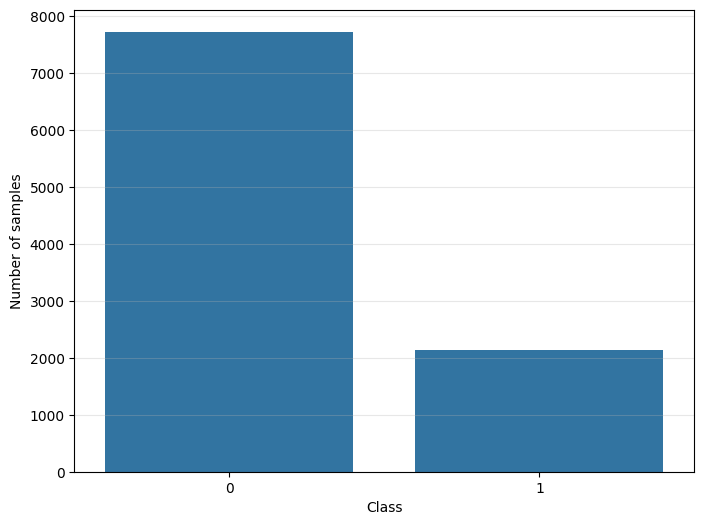


 Répartition des classes :
label
0    7720
1    2137
Name: count, dtype: int64


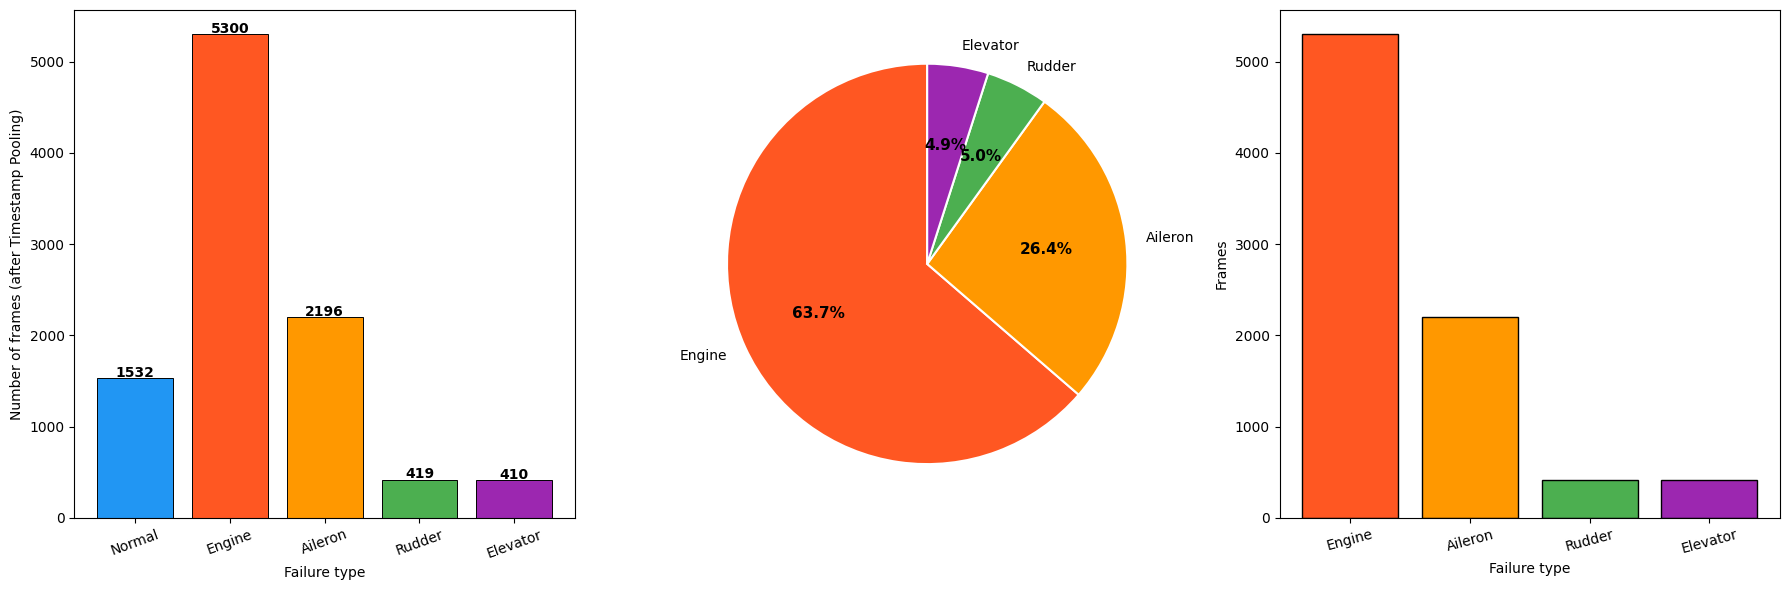


  Résumé des types de pannes :
    Normal     :  1532 frames (15.5%)
    Engine     :  5300 frames (53.8%)
    Aileron    :  2196 frames (22.3%)
    Rudder     :   419 frames (4.3%)
    Elevator   :   410 frames (4.2%)

Création Hold-out indépendant (STRATIFIÉ par type de vol)
  Vols normaux  : 41 total → 14 en test
  Vols en panne : 6 total → 2 en test

  Train : 6722 samples | 31 vols
    Class 0: 5187 | Class 1: 1535
  Test  : 3135 samples  | 16 vols
    Class 0: 2533 | Class 1: 602

 HOLD-OUT - Class 0:2533 | Class 1:602

 Composition du HOLD-OUT - vols en panne, par type de faute :
   Vol                              np.int64(6) -> Engine (label_mc=1)
   Vol                              np.int64(8) -> Engine (label_mc=1)
   Vol                             np.int64(12) -> Engine (label_mc=1)
   Vol                             np.int64(13) -> Engine (label_mc=1)
   Vol                             np.int64(17) -> Engine (label_mc=1)
   Vol                             np.int64(19) ->

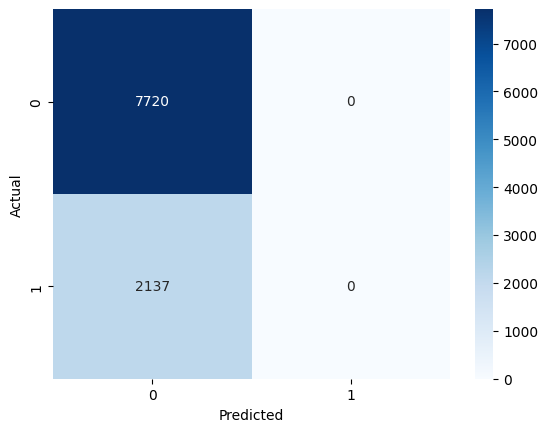


 APPROCHE 2 -  Random Forest (features brutes)
  Seuil optimal (G-Mean) : 0.3550 | G-Mean : 0.8454
  Seuil optimal (G-Mean) : 0.3850 | G-Mean : 0.8764
  Seuil optimal (G-Mean) : 0.2500 | G-Mean : 0.7285
  Seuil optimal (G-Mean) : 0.3900 | G-Mean : 0.9951
  Seuil optimal (G-Mean) : 0.4700 | G-Mean : 0.8746
  G-Mean par fold (RF brut) : [np.float64(0.8454), np.float64(0.8764), np.float64(0.7285), np.float64(0.9951), np.float64(0.8746)]
Rapport de classification - RF brut
              precision    recall  f1-score   support

           0       0.91      0.96      0.94      7720
           1       0.82      0.67      0.74      2137

    accuracy                           0.90      9857
   macro avg       0.87      0.82      0.84      9857
weighted avg       0.89      0.90      0.89      9857



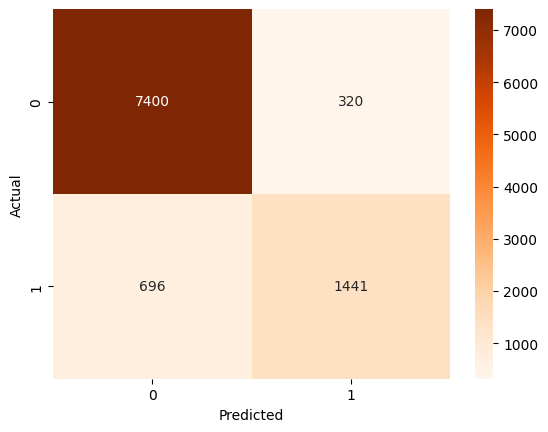

  Seuil optimal (G-Mean) : 0.3100 | G-Mean : 0.8441

 BASELINE - Logistic Regression (GroupKFold 5-folds)
  Seuil optimal (G-Mean) : 0.9050 | G-Mean : 0.7951
  Seuil optimal (G-Mean) : 0.5700 | G-Mean : 0.8271
  Seuil optimal (G-Mean) : 0.2550 | G-Mean : 0.6242
  Seuil optimal (G-Mean) : 0.8100 | G-Mean : 0.8441
  Seuil optimal (G-Mean) : 0.0600 | G-Mean : 0.7050
  G-Mean par fold (Logistic Regression) : [np.float64(0.7951), np.float64(0.8271), np.float64(0.6242), np.float64(0.8441), np.float64(0.705)]

Rapport de classification :

              precision    recall  f1-score   support

           0       0.94      0.73      0.82      7720
           1       0.46      0.83      0.59      2137

    accuracy                           0.75      9857
   macro avg       0.70      0.78      0.70      9857
weighted avg       0.83      0.75      0.77      9857

G-Mean  : 0.7756
AUC-ROC : 0.7930

 APPROCHE 4 - XGBoost (features brutes) GroupKFold 5-folds
  Seuil optimal (G-Mean) : 0.7750 | G-Mea

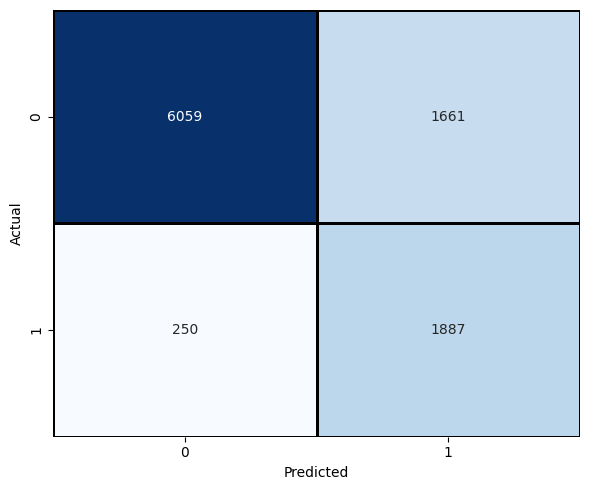

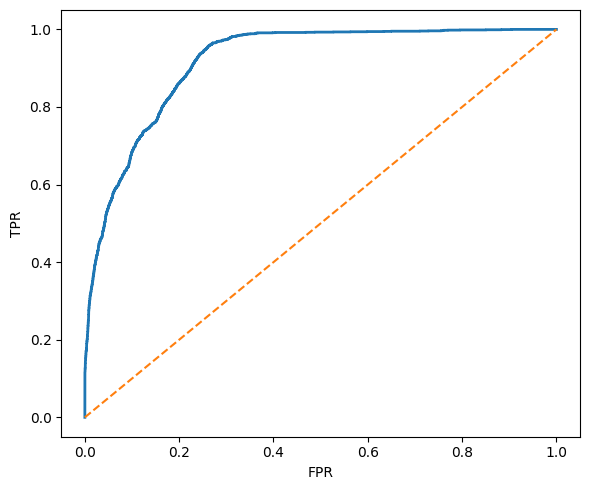


 APPROCHE 7 - LightGBM (GroupKFold 5-folds)
  Seuil optimal (G-Mean) : 0.7200 | G-Mean : 0.8868
  Seuil optimal (G-Mean) : 0.0500 | G-Mean : 0.8539
  Seuil optimal (G-Mean) : 0.0800 | G-Mean : 0.7006
  Seuil optimal (G-Mean) : 0.0550 | G-Mean : 0.9798
  Seuil optimal (G-Mean) : 0.0850 | G-Mean : 0.8101
  G-Mean par fold (LightGBM) : [np.float64(0.8868), np.float64(0.8539), np.float64(0.7006), np.float64(0.9798), np.float64(0.8101)]
  Seuil optimal (G-Mean) : 0.1150 | G-Mean : 0.8367
  Seuil G-Mean : 0.1150 → G-Mean=0.8367 | AUC-ROC=0.9355
              precision    recall  f1-score   support

           0       0.94      0.87      0.90      7720
           1       0.63      0.81      0.71      2137

    accuracy                           0.85      9857
   macro avg       0.78      0.84      0.80      9857
weighted avg       0.87      0.85      0.86      9857


 APPROCHE 8 - Ensemble XGB+LGBM+LR (GroupKFold 5-folds)
  Seuil optimal (G-Mean) : 0.6550 | G-Mean : 0.8795
  Seuil optimal (G

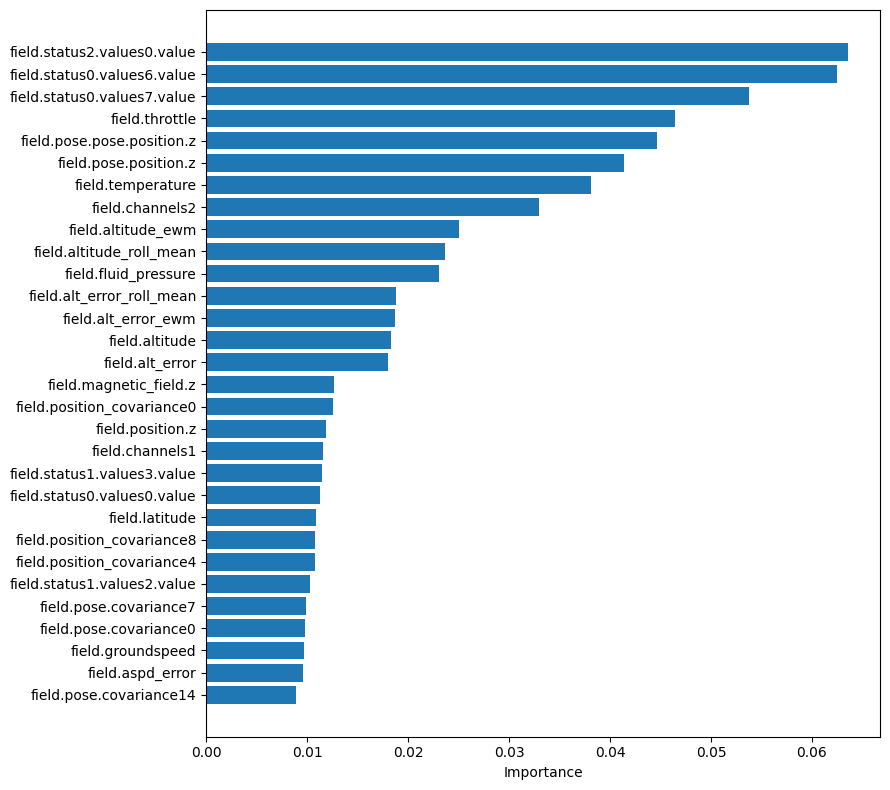

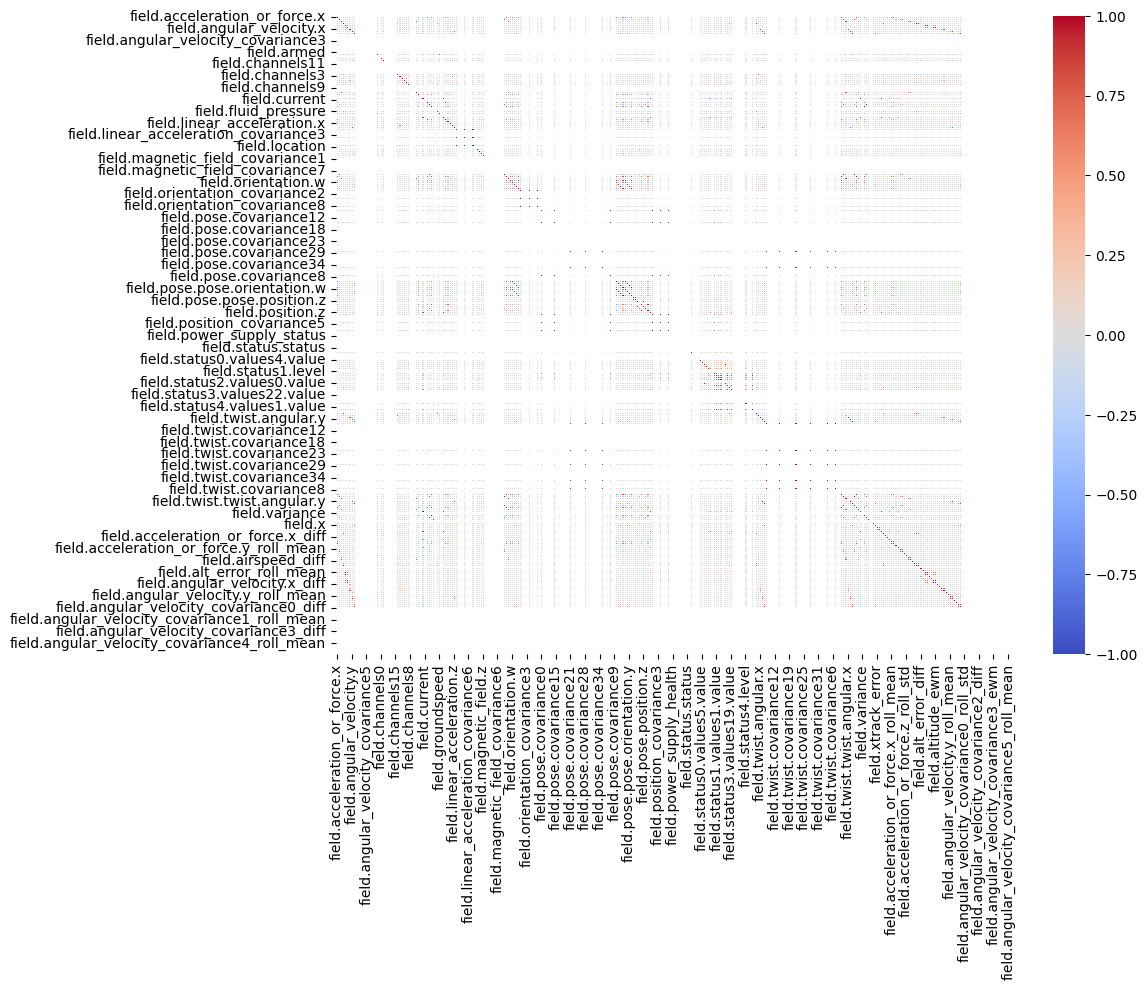


 Lancement de l'optimisation Optuna...

Trials existants : 100
Trials restants à exécuter : 0
Déjà à 100 trials ou plus. Aucun trial supplémentaire nécessaire.

 RÉSUMÉ DES TRIALS OPTUNA
  Aucun trial complété.


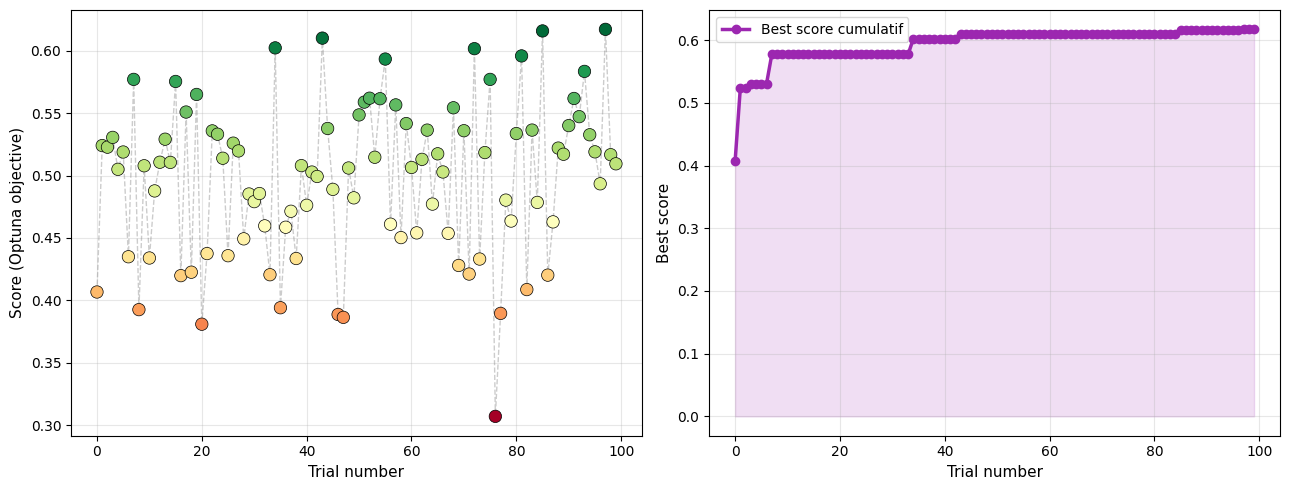

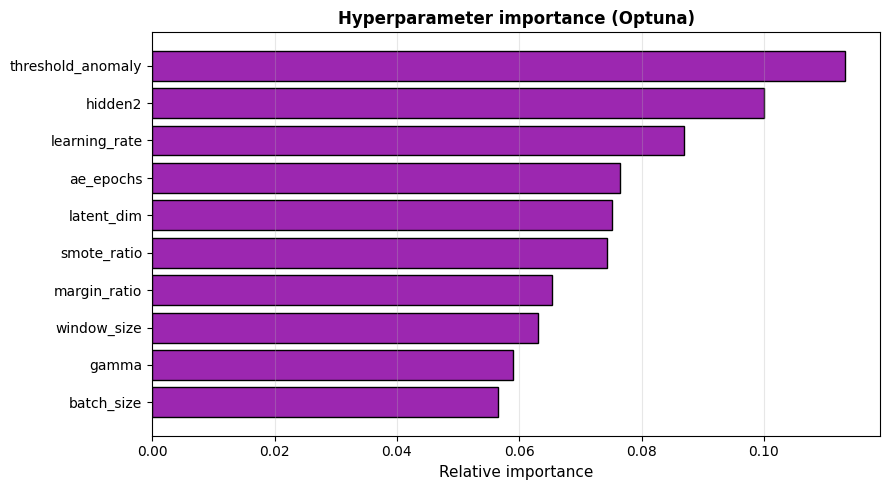


 MEILLEURS PARAMÈTRES OPTUNA
  - latent_dim: 65
  - hidden1: 376
  - hidden2: 248
  - ae_epochs: 105
  - batch_size: 512
  - window_size: 17
  - threshold_anomaly: 0.539263607298306
  - margin_ratio: 0.4819439642248151
  - n_estimators: 415
  - max_depth: 6
  - learning_rate: 0.03189096228148715
  - subsample: 0.884399833942919
  - colsample_bytree: 0.8872212111510549
  - min_child_weight: 14
  - gamma: 0.24970595577528443
  - smote_k: 4
  - smote_ratio: 0.9233685351076679

 SCORE OPTIMAL : 0.6172

 APPROCHE RF + AE - Random Forest sur espace latent AE
  Dimension fixe (global VT) : 161
Traitement du fold 1/5
Traitement du fold 2/5
Traitement du fold 3/5
Traitement du fold 4/5
Traitement du fold 5/5
  Espace latent (scores AE) : (6722, 67)
  Seuil optimal (G-Mean) : 0.3150 | G-Mean : 0.5635
  Seuil optimal (G-Mean) : 0.3650 | G-Mean : 0.5801
  Seuil optimal (G-Mean) : 0.3050 | G-Mean : 0.5544
  Seuil optimal (G-Mean) : 0.2800 | G-Mean : 0.6376
  Seuil optimal (G-Mean) : 0.3500 | G-Mea

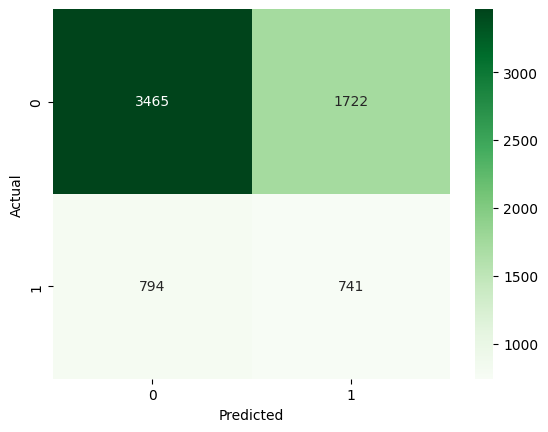


 APPROCHE 6 - XGBoost + AE (sans agrégation) GroupKFold 5-folds
  Seuil optimal (G-Mean) : 0.6500 | G-Mean : 0.8013
  Seuil optimal (G-Mean) : 0.9500 | G-Mean : 0.8503
  Seuil optimal (G-Mean) : 0.8850 | G-Mean : 0.6902
  Seuil optimal (G-Mean) : 0.8550 | G-Mean : 0.9447
  Seuil optimal (G-Mean) : 0.8000 | G-Mean : 0.8112
  G-Mean par fold (XGBoost+AE) : [np.float64(0.8013), np.float64(0.8503), np.float64(0.6902), np.float64(0.9447), np.float64(0.8112)]
  Seuil optimal (G-Mean) : 0.8550 | G-Mean : 0.7999

===== MÉTRIQUES =====
G-Mean:0.7999 AUC-PR:0.7313 AUC-ROC:0.8843
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      7720
           1       0.54      0.79      0.64      2137

    accuracy                           0.81      9857
   macro avg       0.73      0.80      0.75      9857
weighted avg       0.85      0.81      0.82      9857



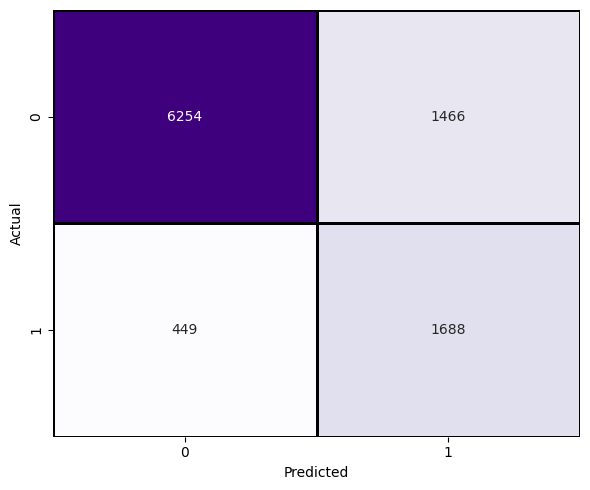


 APPROCHE XGBoost+Agg (SANS AE) - Ablation study
  Seuil optimal (G-Mean) : 0.8200 | G-Mean : 0.8696
  Seuil optimal (G-Mean) : 0.0500 | G-Mean : 0.8737
  Seuil optimal (G-Mean) : 0.0500 | G-Mean : 0.7433
  Seuil optimal (G-Mean) : 0.1200 | G-Mean : 0.9827
  Seuil optimal (G-Mean) : 0.0500 | G-Mean : 0.8182
  G-Mean par fold, frame-par-frame (XGBoost+Agg sans AE) : [np.float64(0.8696), np.float64(0.8737), np.float64(0.7433), np.float64(0.9827), np.float64(0.8182)]
  [Grid Search] win=5, thr=0.050 → G-Mean agrege=0.8347
    TTD median (info) : 0.0000 fenetres
  Seuil optimal (G-Mean) : 0.0500 | G-Mean : 0.8502
  G-Mean frame-par-frame (XGBoost+Agg sans AE) : 0.8502

  Fenêtres : 1989 (cl.0=1566, cl.1=423)
              precision    recall  f1-score   support

           0     0.9894    0.7171    0.8315      1566
           1     0.4813    0.9716    0.6437       423

    accuracy                         0.7712      1989
   macro avg     0.7353    0.8444    0.7376      1989
weighted avg 

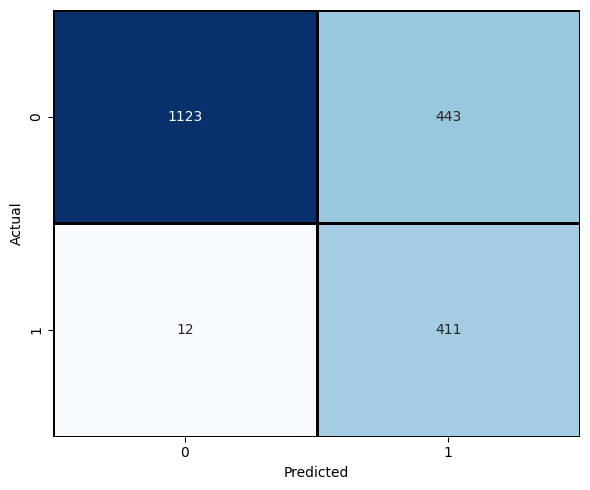


  AE params pour MeNU+ (Optuna best) : {'latent_dim': 65, 'hidden1': 376, 'hidden2': 248, 'ae_epochs': 105, 'batch_size': 512}

 MeNU+ (AE+XGB+Agrégation) - CV 5-FOLDS v8 (features mixtes)
  AE params : {'latent_dim': 65, 'hidden1': 376, 'hidden2': 248, 'ae_epochs': 105, 'batch_size': 512}

  ── Fold 1/5 ──
    AE entraîné sur 6059 frames normales (epochs=105, dim=324)
    Features: 324 brutes + 67 AE = 391 total
    SMOTE (sur 85% = 6718 samples) : 6718 → 9905 samples
    XGB best_iter=414 | TEST cl.0=1661 cl.1=293

  ── Fold 2/5 ──
    AE entraîné sur 5873 frames normales (epochs=105, dim=324)
    Features: 324 brutes + 67 AE = 391 total
    SMOTE (sur 85% = 6678 samples) : 6678 → 9595 samples
    XGB best_iter=414 | TEST cl.0=1847 cl.1=154

  ── Fold 3/5 ──
    AE entraîné sur 6427 frames normales (epochs=105, dim=324)
    Features: 324 brutes + 67 AE = 391 total
    SMOTE (sur 85% = 6712 samples) : 6712 → 10532 samples
    XGB best_iter=414 | TEST cl.0=1293 cl.1=668

  ── Fold 4/5

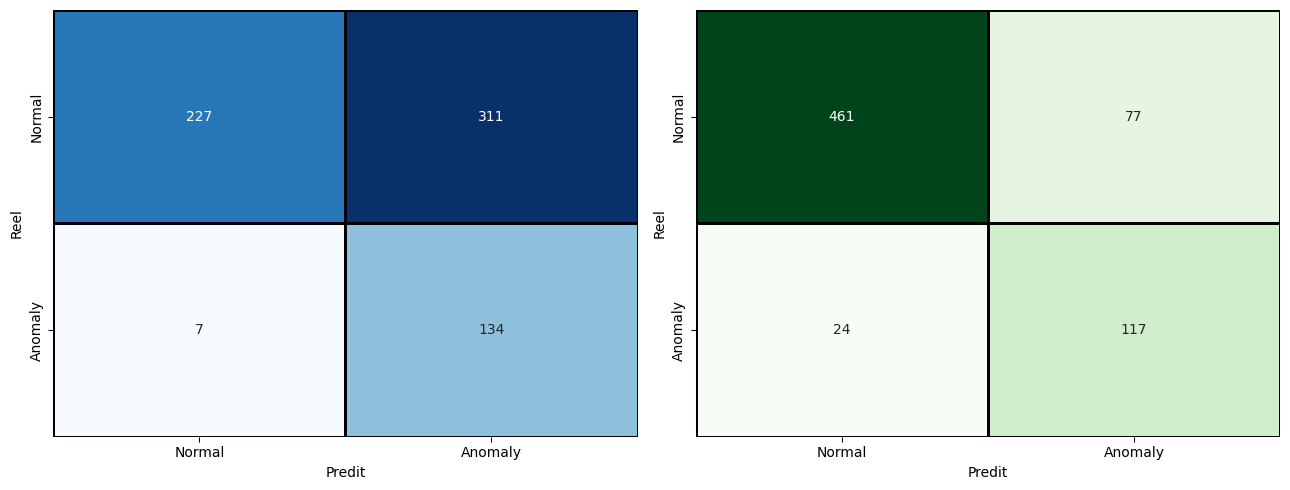

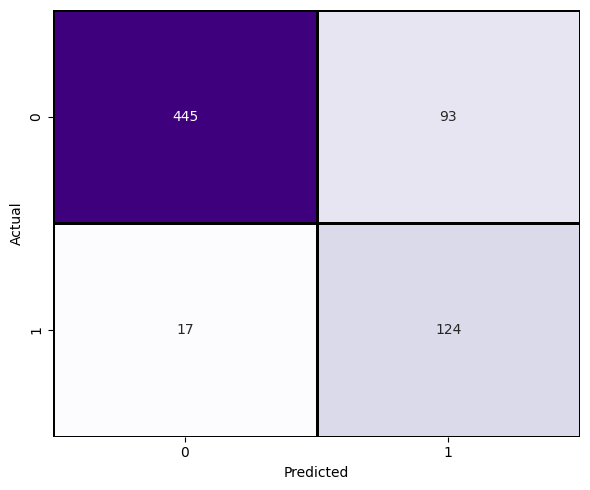

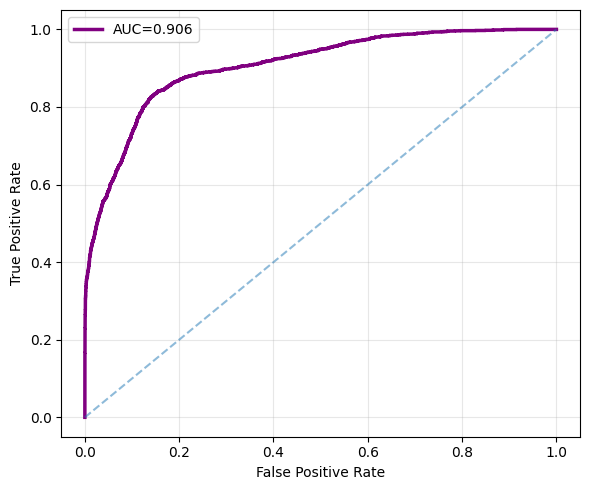

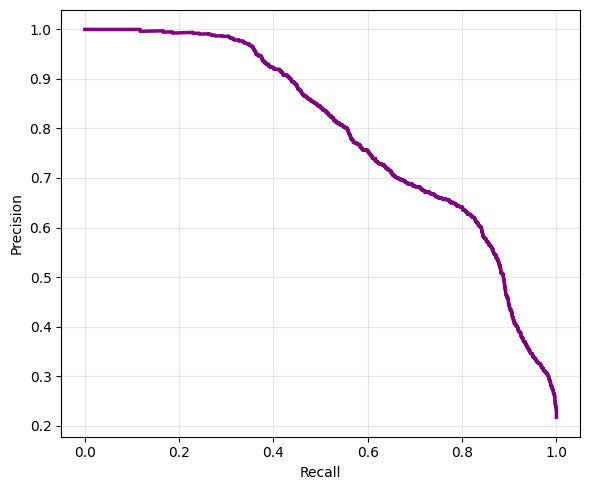


  G-Mean frame-par-frame  : 0.8428  ← utilisé dans le tableau
  G-Mean après agrégation : 0.8529  ← bonus TTD
  TTD moyen : -0.42 fenêtres
  G-Mean frame-par-frame  : 0.8428
  G-Mean après agrégation : 0.8529
  → Tableau utilise post-agrégation (0.8529)
  TTD moyen : -0.42 fenêtres

===== TABLEAU RÉCAPITULATIF FINAL =====
                            PRECISION CL.1  RECALL CL.1  F1 CL.1  AUC-ROC  G-MEAN  TTD (fenêtres)  RANK
MeNU+ (AE+XGB+Agg)                  0.5714       0.8794   0.6927   0.9057  0.8529         -0.4242     1
XGBoost+Agg (sans AE)               0.5362       0.9298   0.6801   0.9206  0.8502         -2.2500     2
RF (features brutes)                0.5801       0.8610   0.6932   0.9271  0.8441             NaN     3
LightGBM (features brutes)          0.6275       0.8072   0.7061   0.9355  0.8367             NaN     4
XGBoost (features brutes)           0.5318       0.8830   0.6639   0.9168  0.8325             NaN     5
Ensemble (XGB+LGBM+LR)              0.5910       0.

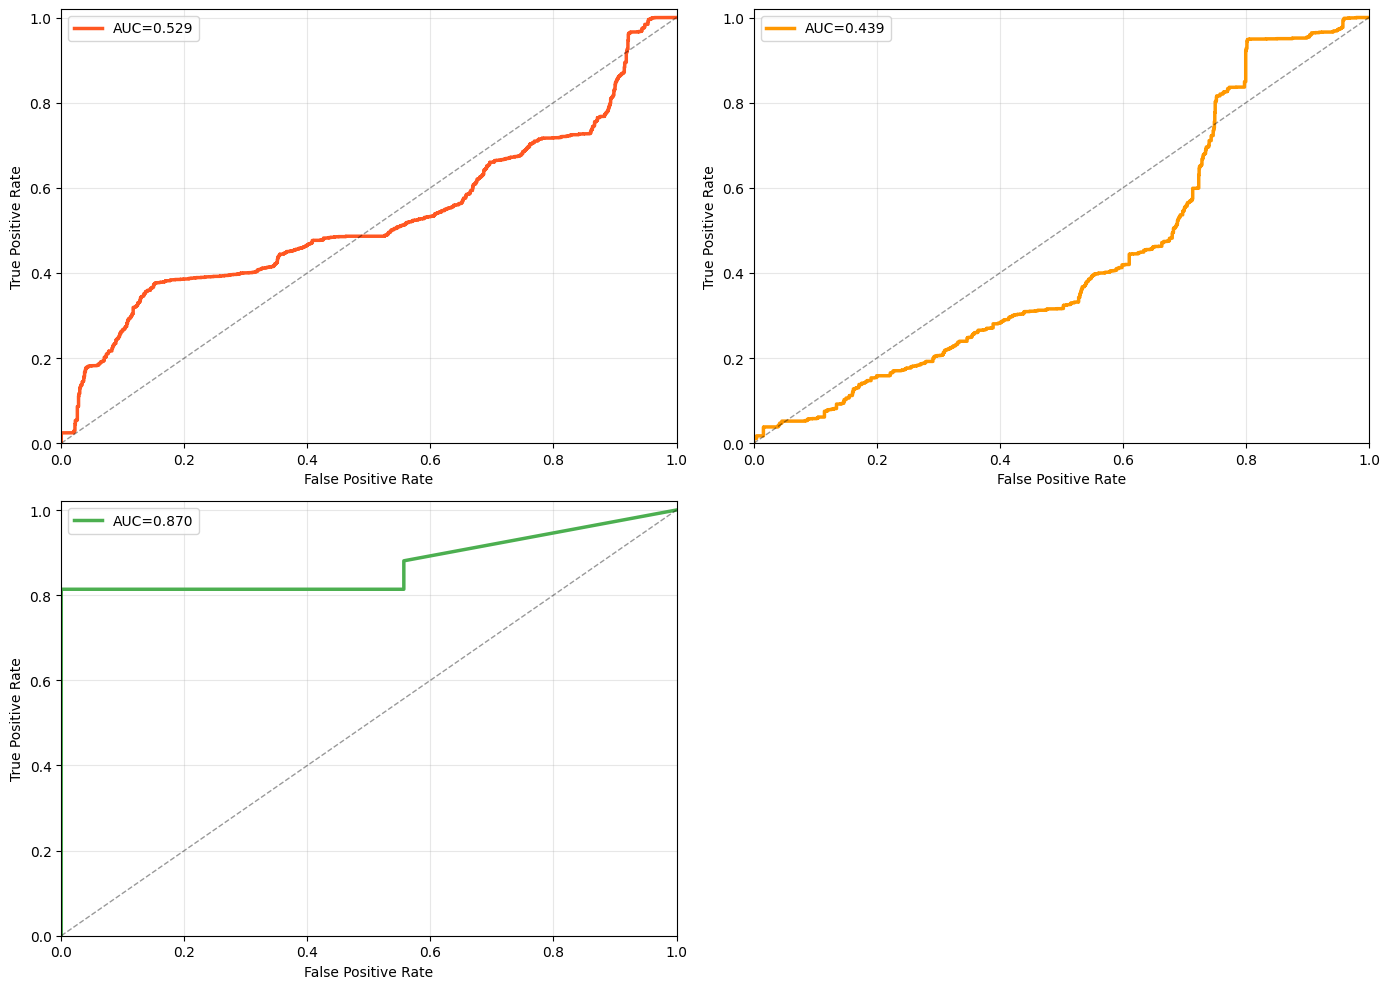


  === Performance par type de panne ===
  Type         | G-Mean   | AUC-ROC  | Recall  
  ---------------------------------------------
  Engine       |   0.4479 |   0.5292 |   0.6208
  Aileron      |   0.4267 |   0.4388 |   0.7008
  Rudder       |   0.5760 |   0.8699 |   0.3317

  MeNU+MF - ÉVALUATION PAR TYPE DE PANNE

  ▶ Engine
    Normal=1532 | Engine=5300
    Fold 1/5 | G-Mean=0.4982 | seuil=0.748
    Fold 2/5 | G-Mean=0.5607 | seuil=0.966
    Fold 3/5 | G-Mean=0.2121 | seuil=0.980
    Fold 4/5 | G-Mean=0.8652 | seuil=0.941
    Fold 5/5 | G-Mean=0.9510 | seuil=0.806

  ── Engine ──  G-Mean=0.6460 | AUC-ROC=0.6056 | AUC-PR=0.7815 | Recall=0.8208 | F1=0.8363
     IC G-Mean : 0.6174 ± 0.2662

  ▶ Aileron
    Normal=1532 | Aileron=2196
    Fold 1/5 | G-Mean=0.5492 | seuil=0.980
    Fold 3/5 | G-Mean=0.8179 | seuil=0.189
    Fold 4/5 | G-Mean=0.9774 | seuil=0.242
    Fold 5/5 | G-Mean=0.7392 | seuil=0.136

  ── Aileron ──  G-Mean=0.7775 | AUC-ROC=0.7882 | AUC-PR=0.9040 | Recall=0.820

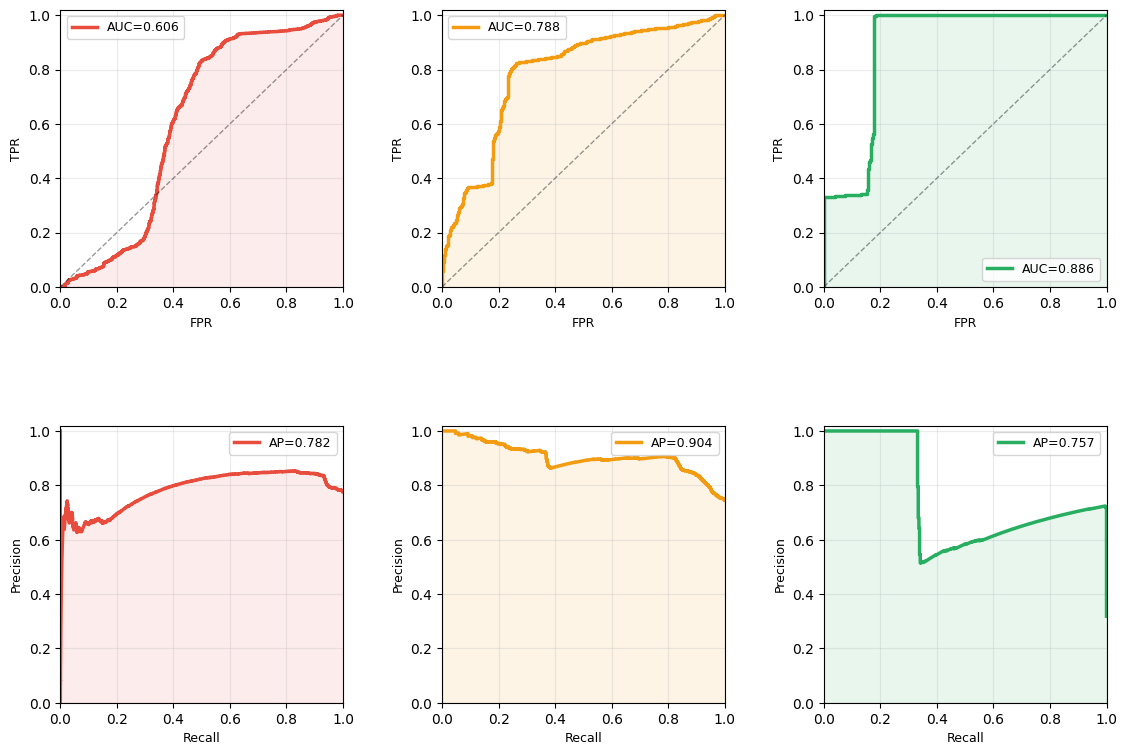

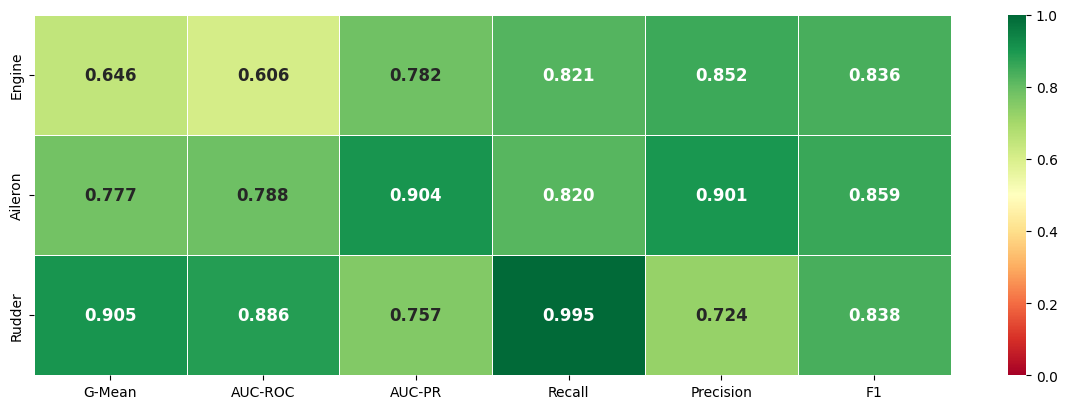

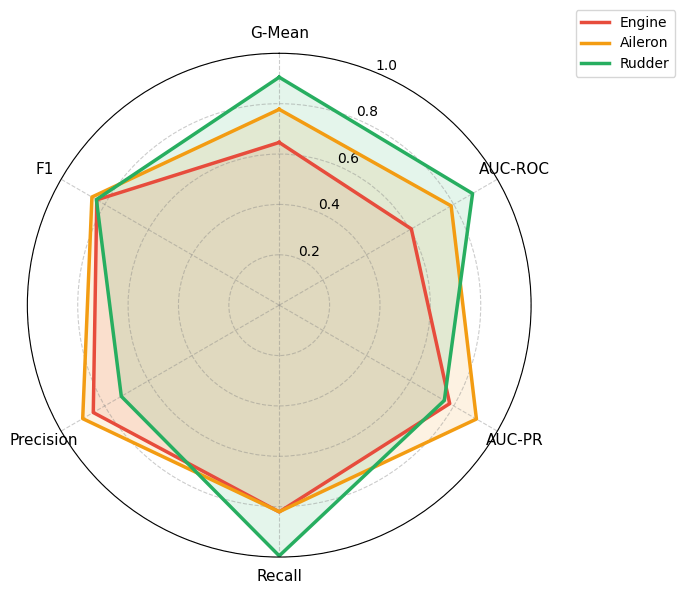

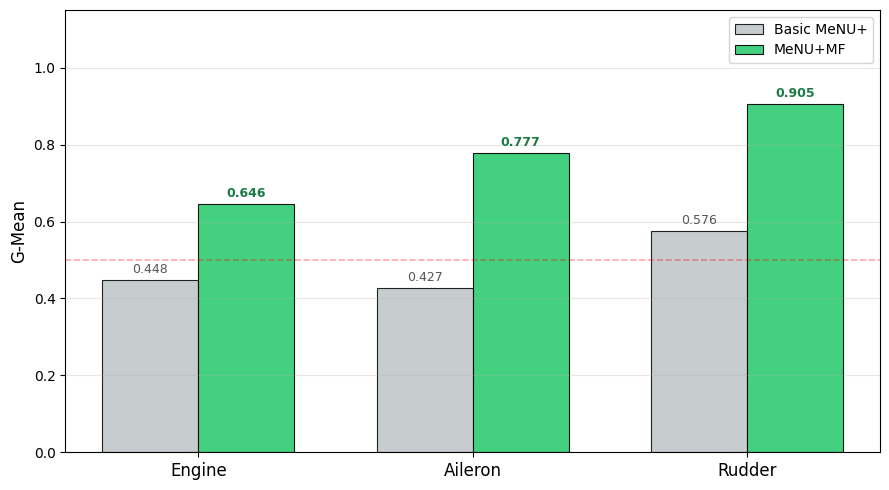


  [✓] Figures : menumf_roc_pr.png | menumf_heatmap.png | menumf_radar.png | menumf_gmean_comparison.png

  [Partie 4.2 - Ablation study temporal features]

  PARTIE 4.2 - ABLATION STUDY : Temporal Features
  Configs: none | diff | diff_std | full

  -- Mode 'none' --
    Shape X: (9857, 324)
  Seuil optimal (G-Mean) : 0.0500 | G-Mean : 0.8148
    G-Mean=0.8148 | AUC-ROC=0.9152 | AUC-PR=0.7609
    Precision=0.5218 | Recall=0.8451

  -- Mode 'diff' --
    Shape X: (9857, 339)
  Seuil optimal (G-Mean) : 0.0500 | G-Mean : 0.8193
    G-Mean=0.8193 | AUC-ROC=0.9199 | AUC-PR=0.7777
    Precision=0.5306 | Recall=0.8470

  -- Mode 'diff_std' --
    Shape X: (9857, 354)
  Seuil optimal (G-Mean) : 0.0500 | G-Mean : 0.8224
    G-Mean=0.8224 | AUC-ROC=0.9184 | AUC-PR=0.7605
    Precision=0.5274 | Recall=0.8596

  -- Mode 'full' --
    Shape X: (9857, 384)
  Seuil optimal (G-Mean) : 0.0500 | G-Mean : 0.8140
    G-Mean=0.8140 | AUC-ROC=0.9159 | AUC-PR=0.7658
    Precision=0.5188 | Recall=0.8465

  A

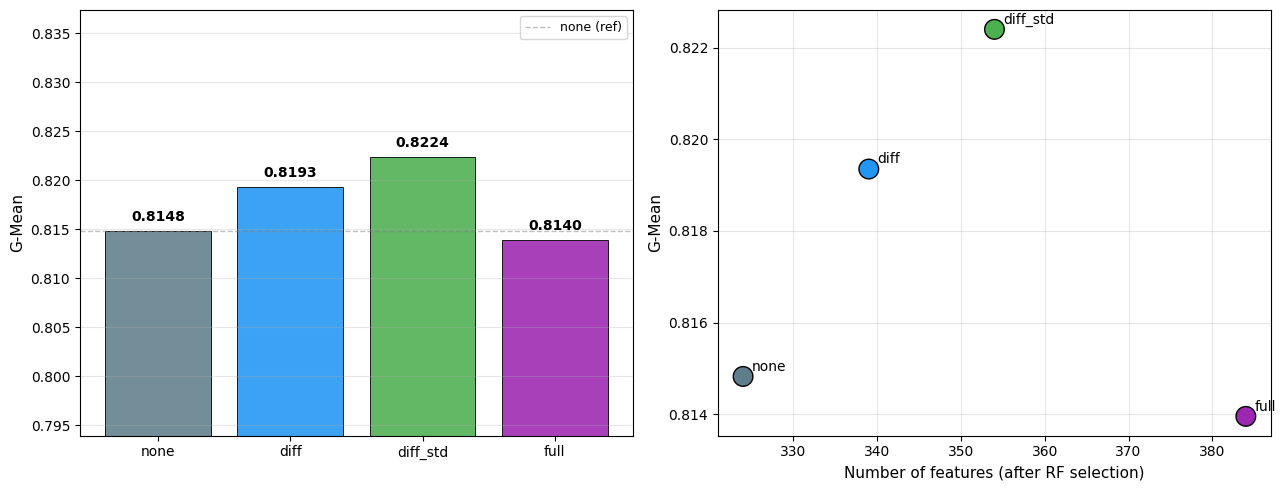


  Best config: 'diff_std' (G-Mean=0.8224)
  Gain full vs diff_std: -0.0084 for +30 extra dimensions
RECOMMENDATION -> switch to temporal_mode='diff_std' (meilleur rapport gain/complexité)


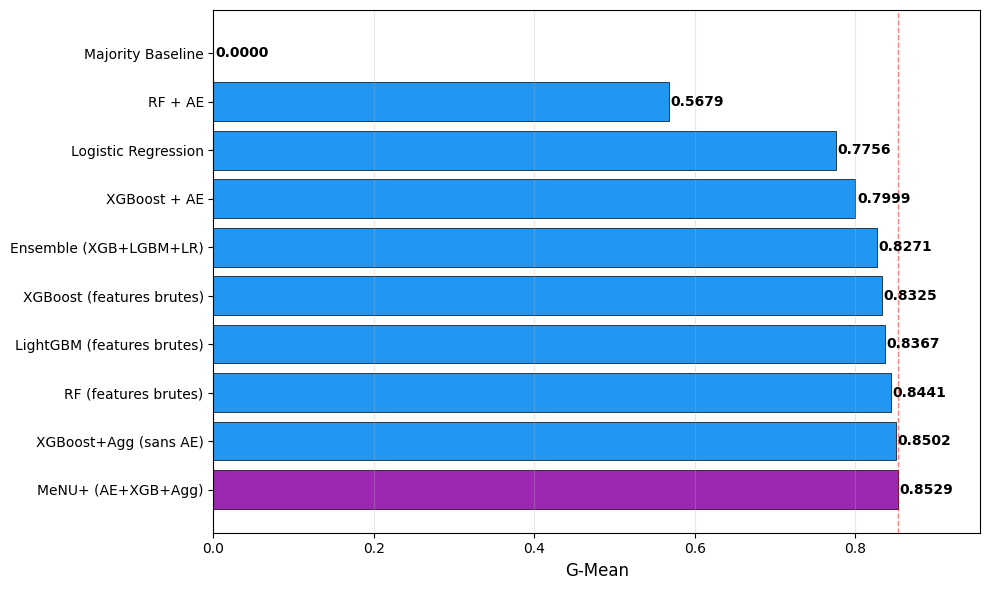

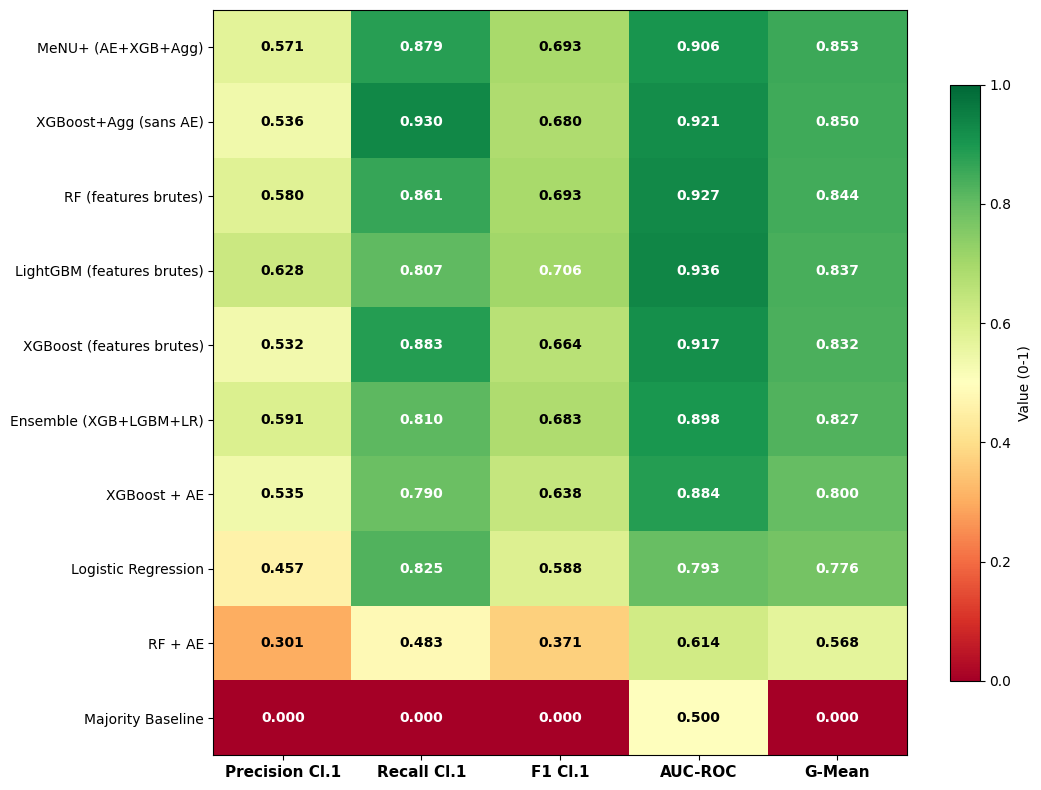


  [INFO] Pour les courbes ROC/PR comparatives, relancer chaque
  approche en stockant (fpr, tpr, auc) dans roc_data et pr_data.

 Fichiers sauvegardés : results_menu_plus.csv

 Pipeline terminé avec succès.


In [43]:
if __name__ == "__main__":
    main()

In [44]:
# ============================================================
# EXPORT DES VERSIONS POUR REPRODUCTIBILITÉ
# ============================================================s

print("Python utilisé :", sys.executable)

# Génère le fichier requirements.txt
!pip freeze > requirements.txt

print("Fichier requirements.txt généré avec succès.")

Python utilisé : C:\Users\jfdel\gpu_env\Scripts\python.exe
Fichier requirements.txt généré avec succès.


## 13. Conclusion et discussion

### Résultats expérimentaux finaux - Pipeline MeNU+ (dernière exécution)

> **Note :** Le TTD (Time-to-Detection) a été recalculé après retrait du clamping `max(0, pred_start - true_start)` qui masquait les détections précoces (cf. Section 8.3). Le TTD moyen de MeNU+ passe de **+0.15** à **-0.4242** fenêtres : les alertes sont en moyenne émises *avant* l'apparition labellisée de la panne (détection anticipée). Le G-Mean et l'AUC-ROC de MeNU+ restent inchangés (**0.8529** / **0.9057**), MeNU+ conserve le rang **#1**.

Le tableau récapitulatif final démontre clairement la hiérarchie validée par l'étude d'ablation :

| Rang | Approche | Précision Cl.1 | Rappel Cl.1 | F1 Cl.1 | AUC-ROC | **G-Mean** | TTD (fenêtres) |
|---|---|---|---|---|---|---|---|
| **1** | **MeNU+ (AE+XGB+Agg)** | **0.5714** | **0.8794** | **0.6927** | **0.9057** | **0.8529** | **-0.4242** |
| 2 | XGBoost+Agg (sans AE) | 0.5362 | 0.9298 | 0.6801 | 0.9206 | 0.8502 | -2.2500 |
| 3 | RF (features brutes) | 0.5801 | 0.8610 | 0.6932 | 0.9271 | 0.8441 | - |
| 4 | LightGBM (features brutes) | 0.6275 | 0.8072 | 0.7061 | 0.9355 | 0.8367 | - |
| 5 | XGBoost (features brutes) | 0.5318 | 0.8830 | 0.6639 | 0.9168 | 0.8325 | - |
| 6 | Ensemble (XGB+LGBM+LR) | 0.5910 | 0.8095 | 0.6833 | 0.8985 | 0.8271 | - |
| 7 | XGBoost + AE | 0.5352 | 0.7899 | 0.6381 | 0.8843 | 0.7999 | - |
| 8 | Logistic Regression | 0.4572 | 0.8255 | 0.5885 | 0.7930 | 0.7756 | - |
| 9 | RF + AE | 0.3009 | 0.4827 | 0.3707 | 0.6143 | 0.5679 | - |
| 10 | Majority Baseline | 0.0000 | 0.0000 | 0.0000 | 0.5000 | 0.0000 | - |

---

### Contributions

**L'agrégation temporelle est la contribution principale :**
XGBoost+Agg (G-Mean=0.8502) surpasse XGBoost brut (G-Mean=0.8325) de **+0.0177 points**, prouvant que l'agrégation temporelle réduit les faux positifs isolés et améliore la robustesse de la décision.

**L'AE apporte un gain additionnel :**
MeNU+ (G-Mean=0.8529) surpasse XGBoost+Agg sans AE (G-Mean=0.8502) de **+0.0027 points**, pour un gain cumulé de **+0.0204** vs XGBoost brut.

**Sur le TTD : lecture corrigée.**
Les deux approches agrégées déclenchent une alerte *avant* l'apparition labellisée de la panne (TTD négatif) : MeNU+ à **-0.4242** fenêtres, XGBoost+Agg sans AE à **-2.2500** fenêtres. XGBoost+Agg seul détecte donc en moyenne plus tôt, mais au prix d'un rappel plus élevé et d'une précision plus faible (Recall Cl.1=0.9298 / Précision Cl.1=0.5362 contre 0.8794 / 0.5714 pour MeNU+) : le TTD seul ne capture pas le taux de fausses alarmes. La contribution opérationnelle de MeNU+ n'est donc pas « détecter plus vite » mais **offrir le meilleur compromis global entre précocité de détection et fiabilité des alertes** (meilleur G-Mean et meilleure précision).

---

### MeNU+MF - Détection par type de panne

Extension qui identifie le type spécifique de panne (Multi-Fault) :

| Panne | G-Mean naïf | G-Mean MeNU+MF | Delta | AUC-ROC | AUC-PR | Recall | F1 |
|---|---|---|---|---|---|---|---|
| Engine | 0.448 | **0.646** | +0.198 | 0.606 | 0.782 | 0.821 | 0.836 |
| Aileron | 0.427 | **0.777** | +0.350 | 0.788 | 0.904 | 0.820 | 0.859 |
| Rudder | 0.576 | **0.905** | +0.329 | 0.886 | 0.757 | 0.995 | 0.838 |

MeNU+MF améliore le G-Mean de +0.198 à +0.350 selon le type de panne.

---

### Dual-Mode Threshold - Flexibilité opérationnelle

MeNU+ propose deux modes opérationnels adaptés au contexte de sécurité-critique :

| Mode | Seuil τ | Précision Cl.0 | Rappel Cl.0 | Précision Cl.1 | Rappel Cl.1 | F1 Cl.1 | G-Mean | Taux de FP | TTD |
|---|---|---|---|---|---|---|---|---|---|
| **Sécurité** | 0.145 | 0.9701 | 0.4219 | 0.3011 | **0.9504** | 0.4573 | 0.6332 | 0.5781 | -3.79 fen. |
| **Équilibre** | 0.615 | 0.9585 | 0.8569 | 0.6031 | 0.8298 | **0.6985** | 0.8432 | 0.1431 | 0.18 fen. |
| Seuil théorique (Table récap., non déployable) | a posteriori | 0.9632 | 0.8271 | 0.5714 | 0.8794 | 0.6927 | **0.8529** | - | -0.42 fen. |

Le mode Sécurité tolère un taux de faux positifs élevé (58 %) pour ne jamais manquer une panne (recall = 0.95) : adapté aux missions SAR. Le mode Équilibre réduit le taux de FP à 14 % en conservant un F1 de 0.70 : adapté à la maintenance de routine. Le seuil « théorique » de la table récapitulative correspond à l'optimum a posteriori (grid search sur les prédictions agrégées), non déployable en temps réel ; les deux modes Dual-Mode restent les références opérationnelles.

Cette flexibilité démontre que le compromis précision/rappel est un **choix de conception opérationnel**, pas une limitation du modèle.

---

### Étude d'ablation - Features temporelles

Voir la Partie 4.2 (juste après le pipeline principal, Section 11) pour le tableau complet. Les écarts de G-Mean entre les configurations testées (`none`, `diff`, `diff_std`, `full`, de -0.0009 à +0.0076) sont très inférieurs à l'écart-type inter-fold du G-Mean (± 0.0956, ci-dessous) et ne sont donc pas significatifs. Le pipeline retient `temporal_mode='none'` (324 features brutes), confirmé par cette étude d'ablation comme n'entraînant aucune dégradation mesurable par rapport aux variantes temporelles.

---

### Intervalles de confiance (CV 5-folds)

| Métrique | Moyenne | Écart-type |
|---|---|---|
| **G-Mean** | **0.7690** | **± 0.0956** |
| AUC-ROC | 0.7803 | ± 0.0758 |
| AUC-PR | 0.5506 | ± 0.1246 |
| **TTD moyen** | **-0.42 fenêtres** | - |

---

### Meilleurs hyperparamètres Optuna (100 trials, score = 0.6172)

| Groupe | Paramètre | Valeur |
|---|---|---|
| AE | latent_dim / hidden1 / hidden2 | 65 / 376 / 248 |
| AE | ae_epochs / batch_size | 105 / 512 |
| XGBoost | n_estimators / max_depth | 415 / 6 |
| XGBoost | learning_rate / subsample | 0.0319 / 0.8844 |
| XGBoost | colsample_bytree / min_child_weight / gamma | 0.8872 / 14 / 0.2497 |
| MeNU+ | window_size / threshold_anomaly | 17 / 0.5393 |
| SMOTE | smote_k / smote_ratio | 4 / 0.9234 |

---

### Perspectives

- Explorer des architectures AE variationnelles (VAE) pour améliorer la qualité du signal latent
- Tester sur d'autres datasets UAV pour valider la généralisation
- Intégrer MeNU+MF dans un pipeline de diagnostic en temps réel
